# post committee meeting comparisons

Caleb said don't look at average, but most distinct ones

For expression, can we show that the ones that differ a lot are more cell type specific. Same for eQTLs?

## first: expression

In [1]:
import numpy as np
enformer_full = np.load('/data1/lesliec/sarthak/data/enformer/data/model_out/enformer.npy', mmap_mode='r')
enformer_full.shape
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
# import torch

model_names = ['enformer', 'GM12878_no_mlm_predictions.npy', 'immune_CAGE_predictions.npy', 'nopretrain_predictions.npy']
# enformer = np.load('/data1/lesliec/sarthak/data/enformer/data/model_out/enformer.npy')

preds = {}
for model_name in model_names:
    if model_name == 'enformer':
        preds[model_name] = enformer_full[:, :, 5110]
    else:
        preds[model_name] = np.load(f'/data1/lesliec/sarthak/data/joint_playground/model_out/{model_name}')
        if preds[model_name].ndim == 3:
            preds[model_name] = preds[model_name][:,:,0]
    print(preds[model_name].shape)
#now let's make sure the targets are the same
t1 = np.load('/data1/lesliec/sarthak/data/joint_playground/model_out/GM12878_base_targets_conv.npy')
t2 = np.load('/data1/lesliec/sarthak/data/joint_playground/model_out/nobcell_CAGE_targets.npy')[:,:,0]
t3 = np.load('/data1/lesliec/sarthak/data/joint_playground/model_out/immune_CAGE_targets.npy')[:,:,0]
t1.shape, t2.shape, t3.shape
#and now see how similar
print(np.allclose(t1, t2))
print(np.allclose(t1, t3)) #perfect!
#now let's just correlate
from scipy.stats import spearmanr, pearsonr
spearman_results = {}
pearson_results  = {}

for name, arr in preds.items():
    # sanity check: shapes match
    print(f"Processing {name} with shape {arr.shape}")
    assert arr.shape == t1.shape, f"{name} vs t1 shape mismatch!"
    # loop over samples
    sp = []
    pp = []
    for i in tqdm(range(arr.shape[0])):
        s = spearmanr(arr[i], t1[i])[0]
        p = pearsonr(arr[i], t1[i])[0]
        sp.append(s)
        pp.append(p)
    spearman_results[name] = np.array(sp)
    pearson_results [name] = np.array(pp)

(1937, 896)
(1937, 896)
(1937, 896)
(1937, 896)
True
True
Processing enformer with shape (1937, 896)


100%|██████████| 1937/1937 [00:15<00:00, 121.29it/s]


Processing GM12878_no_mlm_predictions.npy with shape (1937, 896)


100%|██████████| 1937/1937 [00:01<00:00, 1048.80it/s]


Processing immune_CAGE_predictions.npy with shape (1937, 896)


100%|██████████| 1937/1937 [00:01<00:00, 1048.36it/s]


Processing nopretrain_predictions.npy with shape (1937, 896)


100%|██████████| 1937/1937 [00:01<00:00, 1048.12it/s]


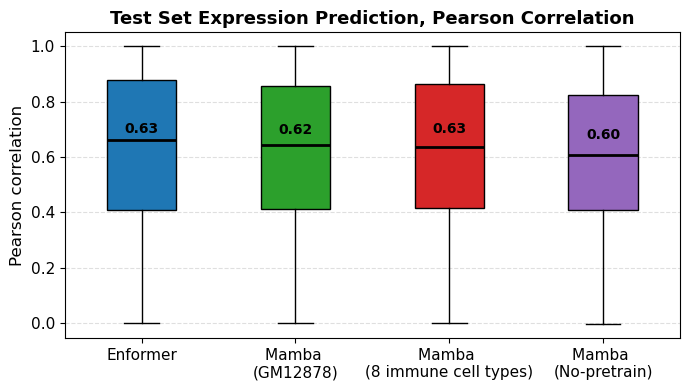

In [2]:
#can we now plot things? first pearson then compare them
#pearson this time
import matplotlib.pyplot as plt
import numpy as np

# Desired order of models (match keys in spearman_results)
ordered_keys = [
    'enformer',
    'GM12878_no_mlm_predictions.npy',
    'immune_CAGE_predictions.npy',
    'nopretrain_predictions.npy'
]

# Pretty display labels
pretty_labels = [
    'Enformer',
    'Mamba \n(GM12878)',
    'Mamba \n(8 immune cell types)',
    'Mamba \n(No-pretrain)'
]

# Matching colors (same order)
colors = ['#1f77b4',  # blue
          '#2ca02c',  # green
          '#d62728',  # red
          '#9467bd']  # purple

# Pull data in correct order
data = [pearson_results[k] for k in ordered_keys]

# Plot
plt.figure(figsize=(7, 4))
box = plt.boxplot(data, labels=pretty_labels, showfliers=False, patch_artist=True,
                  boxprops=dict(edgecolor='black'),
                  medianprops=dict(color='black', linewidth=2),
                  whiskerprops=dict(color='black'),
                  capprops=dict(color='black'))

# Color each box
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Annotate mean values on each box
for i, vals in enumerate(data):
    mean_val = np.mean(vals)
    plt.text(i + 1, mean_val+0.05, f"{mean_val:.2f}",  # slight offset above median
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Labels and formatting
plt.ylabel("Pearson correlation", fontsize=12)
plt.title("Test Set Expression Prediction, Pearson Correlation", fontsize=13, weight='bold')
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


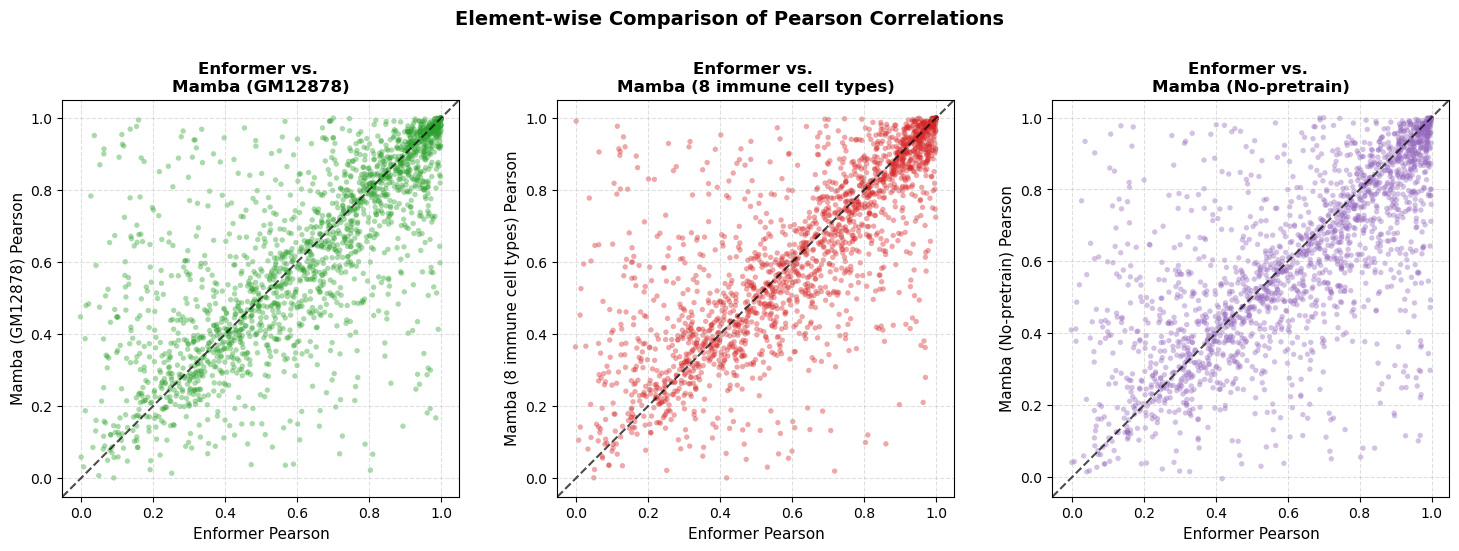

In [3]:
#we'll also make a plot to compare these held out values

import matplotlib.pyplot as plt
import numpy as np

# Desired order of models (match keys in pearson_results)
ordered_keys = [
    'enformer',
    'GM12878_no_mlm_predictions.npy',
    'immune_CAGE_predictions.npy',
    'nopretrain_predictions.npy'
]

# Pretty display labels (removed newlines so they fit better on axis titles)
pretty_labels = [
    'Enformer',
    'Mamba (GM12878)',
    'Mamba (8 immune cell types)',
    'Mamba (No-pretrain)'
]

# Matching colors
colors = ['#1f77b4',  # blue (Enformer)
          '#2ca02c',  # green
          '#d62728',  # red
          '#9467bd']  # purple

# Extract Enformer data as the baseline
enformer_data = pearson_results[ordered_keys[0]]

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Loop through the remaining 3 models and plot against Enformer
for i in range(1, 4):
    ax = axes[i-1]
    comp_data = pearson_results[ordered_keys[i]]
    
    # Scatter plot comparing every element
    ax.scatter(enformer_data, comp_data, color=colors[i], alpha=0.4, s=15, edgecolor='none')
    
    # Add a y=x reference line (black, dashed)
    # Points above this line = Model beats Enformer. Points below = Enformer beats Model.
    min_val = min(np.min(enformer_data), np.min(comp_data))
    max_val = max(np.max(enformer_data), np.max(comp_data))
    
    # Add a small buffer to the line limits
    buffer = (max_val - min_val) * 0.05
    ax.plot([min_val - buffer, max_val + buffer], 
            [min_val - buffer, max_val + buffer], 
            color='black', linestyle='--', alpha=0.7)
    
    # Formatting
    ax.set_xlabel("Enformer Pearson", fontsize=11)
    ax.set_ylabel(f"{pretty_labels[i]} Pearson", fontsize=11)
    ax.set_title(f"Enformer vs. \n{pretty_labels[i]}", fontsize=12, weight='bold')
    
    # Set the aspect ratio to strictly square
    ax.set_box_aspect(1)
    
    # Match the axes limits so it's a perfect square scale
    ax.set_xlim([min_val - buffer, max_val + buffer])
    ax.set_ylim([min_val - buffer, max_val + buffer])
    
    ax.grid(linestyle='--', alpha=0.4)

plt.suptitle("Element-wise Comparison of Pearson Correlations", fontsize=14, weight='bold', y=1.05)
plt.tight_layout()
plt.show()

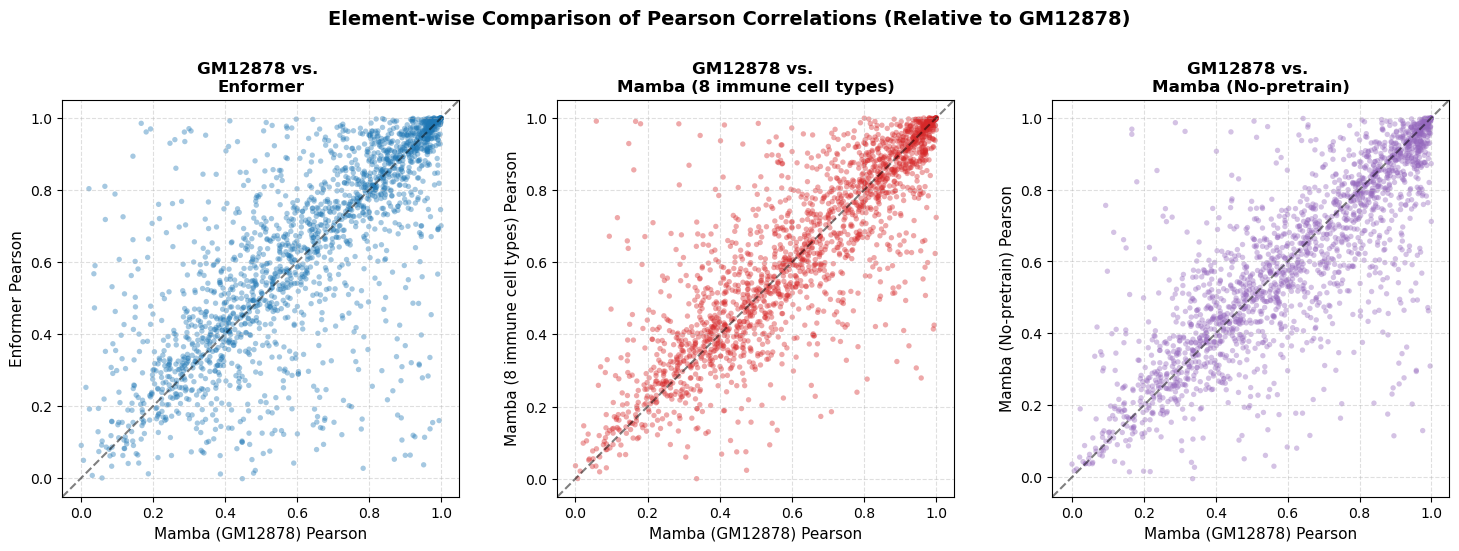

In [5]:
# Scatter comparison of held-out Pearson correlations, relative to GM12878 model

import matplotlib.pyplot as plt
import numpy as np

# Desired order: baseline first, then the models to compare against it
ordered_keys = [
    'GM12878_no_mlm_predictions.npy',
    'enformer',
    'immune_CAGE_predictions.npy',
    'nopretrain_predictions.npy'
]

# Pretty display labels (removed newlines so they fit better on axis titles)
pretty_labels = [
    'Mamba (GM12878)',
    'Enformer',
    'Mamba (8 immune cell types)',
    'Mamba (No-pretrain)'
]

# Matching colors
colors = ['#2ca02c',  # green (GM12878, baseline)
          '#1f77b4',  # blue (Enformer)
          '#d62728',  # red
          '#9467bd']  # purple

# Extract GM12878 data as the baseline
baseline_data = pearson_results[ordered_keys[0]]

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Loop through the remaining 3 models and plot against GM12878
for i in range(1, 4):
    ax = axes[i-1]
    comp_data = pearson_results[ordered_keys[i]]

    # Scatter plot comparing every element
    ax.scatter(baseline_data, comp_data, color=colors[i], alpha=0.4, s=15, edgecolor='none')

    # Add a y=x reference line (black, dashed)
    # Points above this line = Model beats GM12878. Points below = GM12878 beats Model.
    min_val = min(np.min(baseline_data), np.min(comp_data))
    max_val = max(np.max(baseline_data), np.max(comp_data))

    # Add a small buffer to the line limits
    buffer = (max_val - min_val) * 0.05
    ax.plot([min_val - buffer, max_val + buffer],
            [min_val - buffer, max_val + buffer],
            color='black', linestyle='--', alpha=0.5)


    # Formatting
    ax.set_xlabel("Mamba (GM12878) Pearson", fontsize=11)
    ax.set_ylabel(f"{pretty_labels[i]} Pearson", fontsize=11)
    ax.set_title(f"GM12878 vs. \n{pretty_labels[i]}", fontsize=12, weight='bold')

    # Set the aspect ratio to strictly square
    ax.set_box_aspect(1)

    # Match the axes limits so it's a perfect square scale
    ax.set_xlim([min_val - buffer, max_val + buffer])
    ax.set_ylim([min_val - buffer, max_val + buffer])

    ax.grid(linestyle='--', alpha=0.4)

plt.suptitle("Element-wise Comparison of Pearson Correlations (Relative to GM12878)", fontsize=14, weight='bold', y=1.05)
plt.tight_layout()
plt.show()

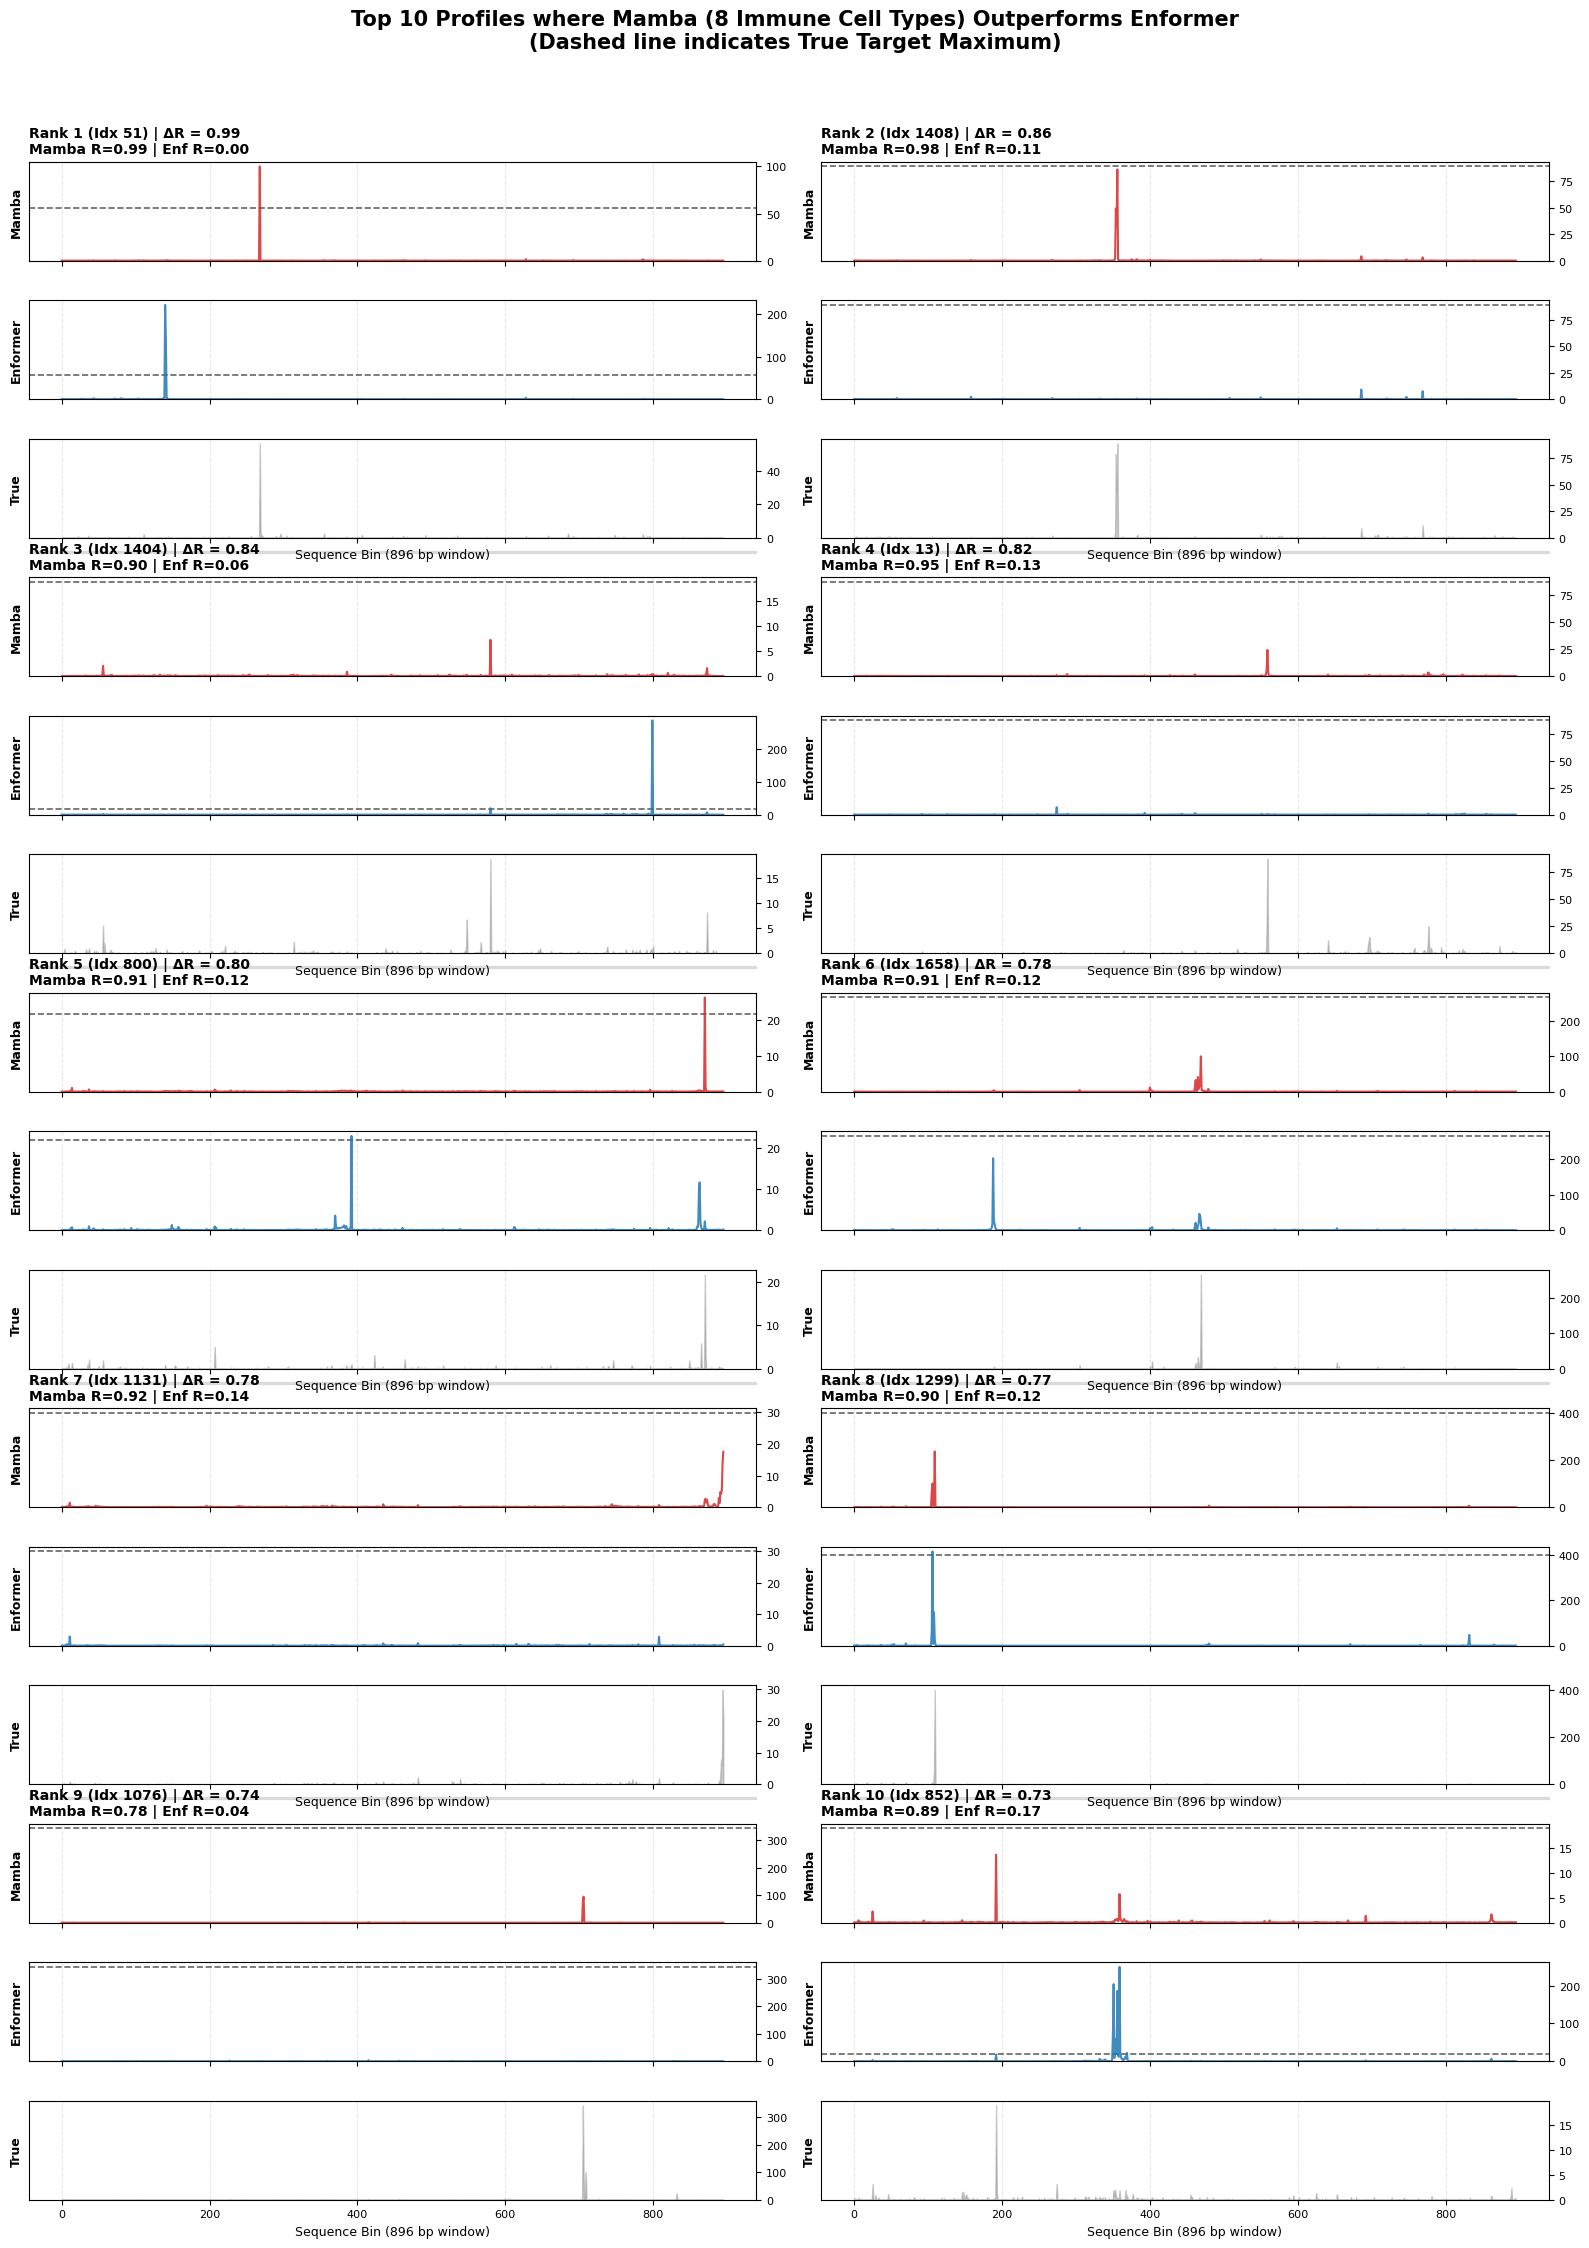

In [4]:
import numpy as np
import matplotlib.pyplot as plt

mamba_key = 'immune_CAGE_predictions.npy'
enformer_key = 'enformer'

delta_pearson = pearson_results[mamba_key] - pearson_results[enformer_key]
top_10_indices = np.argsort(delta_pearson)[-10:][::-1]

fig, axes = plt.subplots(15, 2, figsize=(16, 22), sharex='col')

for rank, idx in enumerate(top_10_indices):
    example_row = rank // 2  
    example_col = rank % 2   
    start_row = example_row * 3
    
    ax_mamba    = axes[start_row,     example_col]
    ax_enformer = axes[start_row + 1, example_col]
    ax_true     = axes[start_row + 2, example_col]
    
    track_mamba = preds[mamba_key][idx]
    track_enf   = preds[enformer_key][idx]
    track_true  = t1[idx]
    
    # --- SCALE ANCHORING LOGIC ---
    true_max = np.max(track_true)
    
    # Draw the reference line on the prediction plots
    ax_mamba.axhline(true_max, color='black', linestyle='--', alpha=0.6, linewidth=1.2, label='True Max')
    ax_enformer.axhline(true_max, color='black', linestyle='--', alpha=0.6, linewidth=1.2)
    
    # Plot the profiles
    ax_mamba.plot(track_mamba, color='#d62728', alpha=0.85, label='Mamba')
    ax_enformer.plot(track_enf, color='#1f77b4', alpha=0.85, label='Enformer')
    ax_true.fill_between(range(len(track_true)), track_true, color='gray', alpha=0.4, label='True')
    
    # Set Y-limits to at least the true_max, or expand if the model overpredicts
    ax_mamba.set_ylim(0, max(np.max(track_mamba), true_max) * 1.05)
    ax_enformer.set_ylim(0, max(np.max(track_enf), true_max) * 1.05)
    ax_true.set_ylim(0, true_max * 1.05)
    # -----------------------------
    
    title_text = f"Rank {rank+1} (Idx {idx}) | ΔR = {delta_pearson[idx]:.2f}\nMamba R={pearson_results[mamba_key][idx]:.2f} | Enf R={pearson_results[enformer_key][idx]:.2f}"
    ax_mamba.set_title(title_text, fontsize=10, weight='bold', loc='left')
    
    for ax, label in zip([ax_mamba, ax_enformer, ax_true], ['Mamba', 'Enformer', 'True']):
        ax.set_ylabel(label, fontsize=9, weight='bold')
        ax.tick_params(axis='both', labelsize=8)
        ax.grid(axis='x', linestyle='--', alpha=0.3) # Switched to X grid to not clash with our true-max line
        
        # Move Y-ticks to the right side for cleaner visualization of magnitude
        ax.yaxis.tick_right()

    ax_true.set_xlabel("Sequence Bin (896 bp window)", fontsize=9)
    
    if start_row + 2 < 14:
        rect = plt.Rectangle((0, -0.15), 1, 0.02, transform=ax_true.transAxes,
                             color='black', alpha=0.1, clip_on=False)
        ax_true.add_patch(rect)

plt.suptitle("Top 10 Profiles where Mamba (8 Immune Cell Types) Outperforms Enformer\n(Dashed line indicates True Target Maximum)", 
             fontsize=15, weight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(hspace=0.4) # Add a bit more vertical space so Y-ticks don't overlap titles
plt.show()

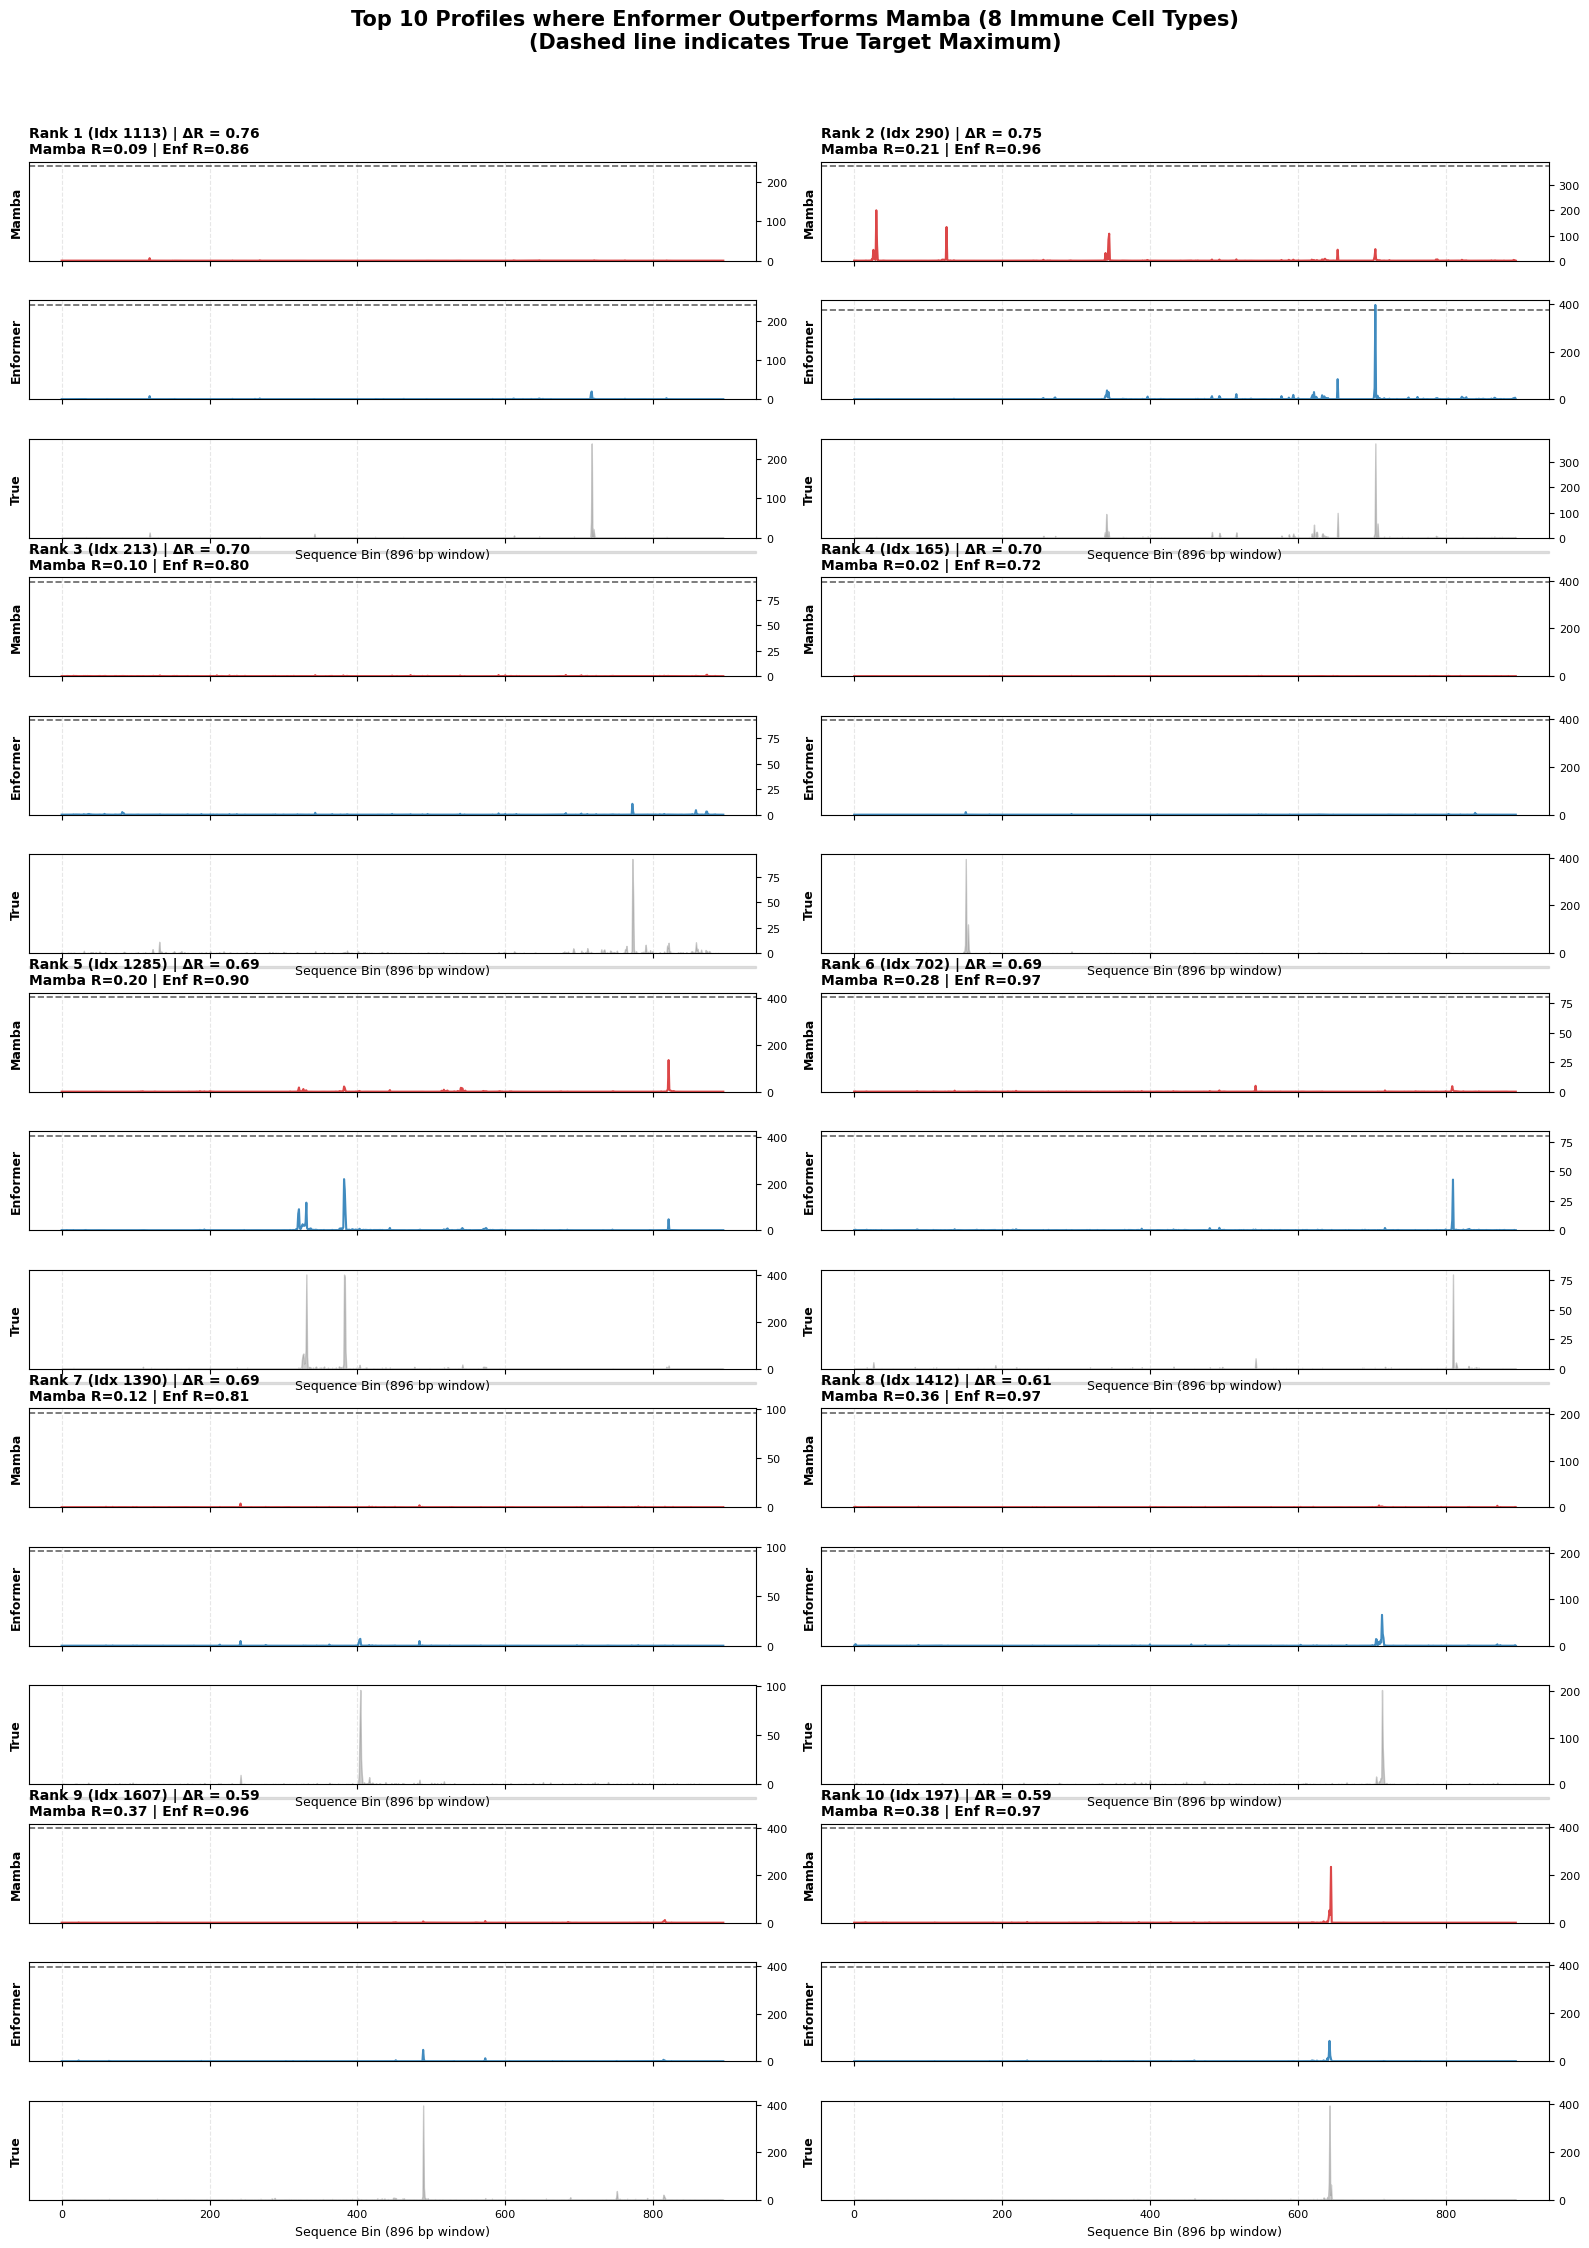

In [5]:
#now find where enformer is better

import numpy as np
import matplotlib.pyplot as plt

mamba_key = 'immune_CAGE_predictions.npy'
enformer_key = 'enformer'

delta_pearson = pearson_results[enformer_key] - pearson_results[mamba_key]
top_10_indices = np.argsort(delta_pearson)[-10:][::-1]

fig, axes = plt.subplots(15, 2, figsize=(16, 22), sharex='col')

for rank, idx in enumerate(top_10_indices):
    example_row = rank // 2  
    example_col = rank % 2   
    start_row = example_row * 3
    
    ax_mamba    = axes[start_row,     example_col]
    ax_enformer = axes[start_row + 1, example_col]
    ax_true     = axes[start_row + 2, example_col]
    
    track_mamba = preds[mamba_key][idx]
    track_enf   = preds[enformer_key][idx]
    track_true  = t1[idx]
    
    # --- SCALE ANCHORING LOGIC ---
    true_max = np.max(track_true)
    
    # Draw the reference line on the prediction plots
    ax_mamba.axhline(true_max, color='black', linestyle='--', alpha=0.6, linewidth=1.2, label='True Max')
    ax_enformer.axhline(true_max, color='black', linestyle='--', alpha=0.6, linewidth=1.2)
    
    # Plot the profiles
    ax_mamba.plot(track_mamba, color='#d62728', alpha=0.85, label='Mamba')
    ax_enformer.plot(track_enf, color='#1f77b4', alpha=0.85, label='Enformer')
    ax_true.fill_between(range(len(track_true)), track_true, color='gray', alpha=0.4, label='True')
    
    # Set Y-limits to at least the true_max, or expand if the model overpredicts
    ax_mamba.set_ylim(0, max(np.max(track_mamba), true_max) * 1.05)
    ax_enformer.set_ylim(0, max(np.max(track_enf), true_max) * 1.05)
    ax_true.set_ylim(0, true_max * 1.05)
    # -----------------------------
    
    title_text = f"Rank {rank+1} (Idx {idx}) | ΔR = {delta_pearson[idx]:.2f}\nMamba R={pearson_results[mamba_key][idx]:.2f} | Enf R={pearson_results[enformer_key][idx]:.2f}"
    ax_mamba.set_title(title_text, fontsize=10, weight='bold', loc='left')
    
    for ax, label in zip([ax_mamba, ax_enformer, ax_true], ['Mamba', 'Enformer', 'True']):
        ax.set_ylabel(label, fontsize=9, weight='bold')
        ax.tick_params(axis='both', labelsize=8)
        ax.grid(axis='x', linestyle='--', alpha=0.3) # Switched to X grid to not clash with our true-max line
        
        # Move Y-ticks to the right side for cleaner visualization of magnitude
        ax.yaxis.tick_right()

    ax_true.set_xlabel("Sequence Bin (896 bp window)", fontsize=9)
    
    if start_row + 2 < 14:
        rect = plt.Rectangle((0, -0.15), 1, 0.02, transform=ax_true.transAxes,
                             color='black', alpha=0.1, clip_on=False)
        ax_true.add_patch(rect)

plt.suptitle("Top 10 Profiles where Enformer Outperforms Mamba (8 Immune Cell Types)\n(Dashed line indicates True Target Maximum)", 
             fontsize=15, weight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(hspace=0.4) # Add a bit more vertical space so Y-ticks don't overlap titles
plt.show()

In [7]:
#hmmm intereseting, so we see that it really is better for many examples. The question is if it is indeed more cell type specific? Will redo this for all 3 models
#let's just do the most naive way anyways. Z score after summing, and see where it's Z scores are high or low. Then can color the previous plot by it

#let's load the zarr array
import zarr
labels = zarr.open('/data1/lesliec/sarthak/data/enformer/data/labels.zarr', mode='r')
labels['test'].shape

(1937, 896, 5313)

In [8]:
#now we'll load in just the CAGE tracks
labels_cage = labels['test'][:, :, 4675:]
labels_cage.shape

(1937, 896, 638)

In [9]:
#now let's sum the labels across cell types and then z score them
labels_cage_sum = np.sum(labels_cage, axis=1)
#now z score and find where the z scores are high for track 5110, which would be relative to the 4675 we start from
target_idx = 5110 - 4675

# 2. Isolate K562 and the Background (the 637 other tracks)
k562_signal = labels_cage_sum[:, target_idx]               # Shape: (1937,)
bg_signal = np.delete(labels_cage_sum, target_idx, axis=1) # Shape: (1937, 637)

# 3. Calculate mean and std across the CELL TYPES (axis=1), not the regions
# This gives you 1937 distinct means and standard deviations
bg_mean = np.mean(bg_signal, axis=1) 
bg_std = np.std(bg_signal, axis=1) + 1e-6 # Add a tiny epsilon to prevent division by zero

# 4. Calculate the specificity Z-score
z_scores = (k562_signal - bg_mean) / bg_std
z_scores.shape  # Should be (1937,)

(1937,)

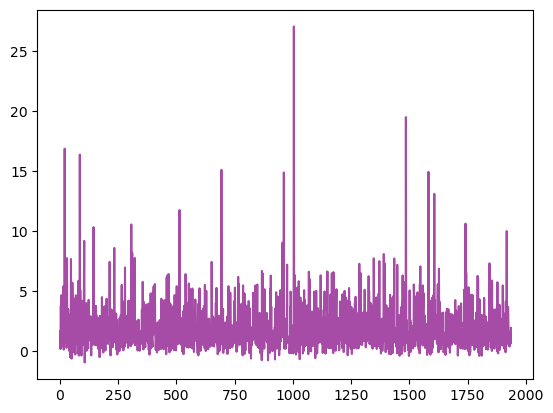

In [10]:
#now per track we have the Z score, let's plot now
plt.plot(z_scores, color='purple', alpha=0.7)

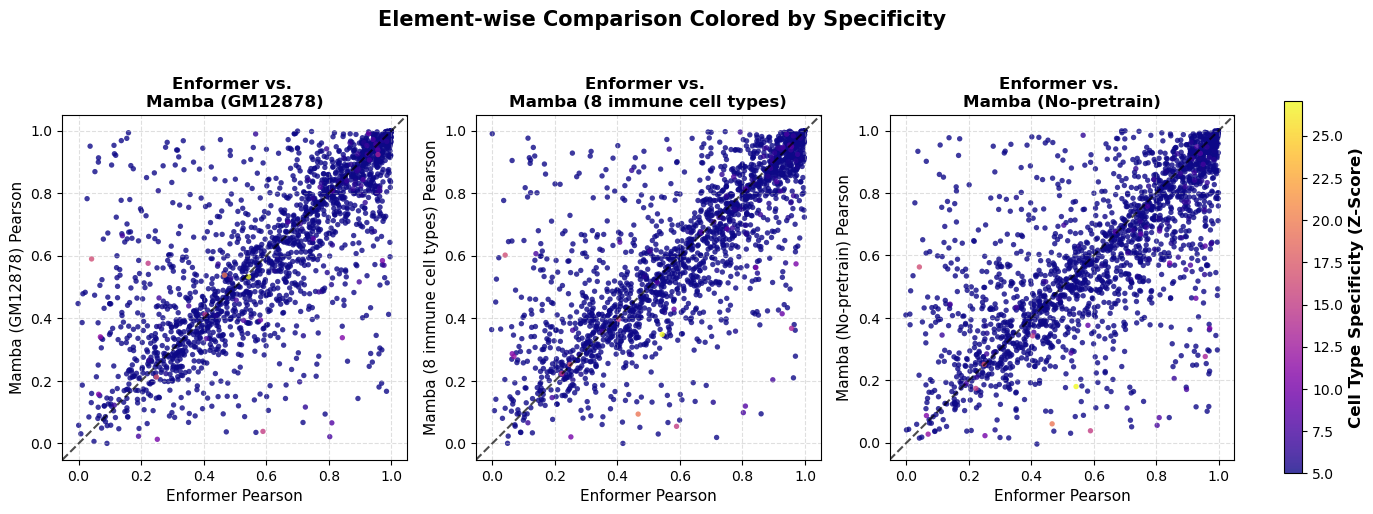

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Sort the indices based on z_score so larger values are plotted LAST (on top)
sort_idx = np.argsort(z_scores)
z_sorted = z_scores[sort_idx]

# Desired order of models
ordered_keys = [
    'enformer',
    'GM12878_no_mlm_predictions.npy',
    'immune_CAGE_predictions.npy',
    'nopretrain_predictions.npy'
]

pretty_labels = [
    'Enformer',
    'Mamba (GM12878)',
    'Mamba (8 immune cell types)',
    'Mamba (No-pretrain)'
]

# Extract Enformer data and sort it
enformer_data = pearson_results[ordered_keys[0]]
enf_sorted = enformer_data[sort_idx]

# Create a figure (slightly wider to accommodate the colorbar)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i in range(1, 4):
    ax = axes[i-1]
    
    # Extract comparison data and sort it
    comp_data = pearson_results[ordered_keys[i]]
    comp_sorted = comp_data[sort_idx]
    
    # 2. Scatter plot with c=z_sorted. 
    # vmin=5 forces all z-scores <= 5 to share the bottom color.
    # cmap='plasma' transitions from dark purple to bright yellow for high visibility.
    sc = ax.scatter(enf_sorted, comp_sorted, 
                    c=z_sorted, cmap='plasma', 
                    vmin=5, vmax=np.max(z_scores), 
                    alpha=0.8, s=15, edgecolor='none')
    
    # Reference line logic
    min_val = min(np.min(enf_sorted), np.min(comp_sorted))
    max_val = max(np.max(enf_sorted), np.max(comp_sorted))
    
    buffer = (max_val - min_val) * 0.05
    ax.plot([min_val - buffer, max_val + buffer], 
            [min_val - buffer, max_val + buffer], 
            color='black', linestyle='--', alpha=0.7)
    
    # Formatting
    ax.set_xlabel("Enformer Pearson", fontsize=11)
    ax.set_ylabel(f"{pretty_labels[i]} Pearson", fontsize=11)
    ax.set_title(f"Enformer vs. \n{pretty_labels[i]}", fontsize=12, weight='bold')
    
    ax.set_box_aspect(1)
    ax.set_xlim([min_val - buffer, max_val + buffer])
    ax.set_ylim([min_val - buffer, max_val + buffer])
    ax.grid(linestyle='--', alpha=0.4)

# 3. Add a unified colorbar to the figure to explain the coloring
cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), fraction=0.015, pad=0.04)
cbar.set_label("Cell Type Specificity (Z-Score)", fontsize=12, weight='bold')

plt.suptitle("Element-wise Comparison Colored by Specificity", fontsize=15, weight='bold', y=1.05)
plt.show()

In [ ]:
#hmm this is interesting. Idk man... seems like maybe naive sorting isn't ideal.
#let's look at true ubiquitous vs CTS regions from the paper! We can also test alphagenome in those regions!
#that is a fair comparison!

#first let's predict alphagenome in these regions and get its correlation!

#so they look at chromatin accessibility. 

# so we see some examples where it clearly is outperforming

Now there's a few main issues. Our context length is larger, so it's not really fair. Could use borzoi data to compare. Would be annoying tho?

Perhaps easier it to use some alphagenome examples. Now the key issue is that it's regions which are not held out, so we can look into that

In [ ]:
#

# A better profile-similarity metric: smoothed-log Pearson

Plain per-bin Pearson has two problems for these zero-inflated CAGE profiles:

1. **It's dominated by the single tallest bin.** CAGE is heavy-tailed, so `pearson(pred, true)` mostly asks "did you co-locate the one biggest peak," ignoring the rest of the shape.
2. **It's not distance-aware.** For a sharp peak, a prediction that's off by **1 bin** scores almost as badly as one on the **opposite end** of the window — correlation only rewards exact co-location, so tiny offsets are over-penalized and "close" is never rewarded.

To fix this we (1) `log1p`-transform to spread weight across the profile instead of the single max, and (2) **Gaussian-smooth** both profiles before correlating, so a near-miss in peak position becomes a near-hit while a genuinely misplaced peak still scores low.

Below we recompute the metric for all models and re-plot the top examples where the **GM12878 model beats Enformer** under this fairer metric.

In [1]:
import numpy as np
enformer_full = np.load('/data1/lesliec/sarthak/data/enformer/data/model_out/enformer.npy', mmap_mode='r')
enformer_full.shape
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
# import torch

model_names = ['enformer', 'GM12878_no_mlm_predictions.npy', 'immune_CAGE_predictions.npy', 'nopretrain_predictions.npy']
# enformer = np.load('/data1/lesliec/sarthak/data/enformer/data/model_out/enformer.npy')

preds = {}
for model_name in model_names:
    if model_name == 'enformer':
        preds[model_name] = enformer_full[:, :, 5110]
    else:
        preds[model_name] = np.load(f'/data1/lesliec/sarthak/data/joint_playground/model_out/{model_name}')
        if preds[model_name].ndim == 3:
            preds[model_name] = preds[model_name][:,:,0]
    print(preds[model_name].shape)
#now let's make sure the targets are the same
t1 = np.load('/data1/lesliec/sarthak/data/joint_playground/model_out/GM12878_base_targets_conv.npy')
# Smoothed-log Pearson: a positional-offset-tolerant profile similarity metric.
# 1) log1p tames the heavy-tailed CAGE signal so the score isn't dominated by the single tallest bin
# 2) Gaussian smoothing (sigma bins) turns a "1 bin off" prediction into a near-hit instead of a
#    total miss, while a peak on the opposite end still scores poorly.
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr

SMOOTH_SIGMA = 1.5  # in bins (~128bp each); raise for more positional tolerance

def smoothed_log_pearson(pred, true, sigma=SMOOTH_SIGMA):
    p = gaussian_filter1d(np.log1p(np.clip(pred, 0, None)), sigma=sigma)
    t = gaussian_filter1d(np.log1p(np.clip(true, 0, None)), sigma=sigma)
    # a flat (all-zero) profile has no shape to correlate -> undefined
    if np.std(p) < 1e-8 or np.std(t) < 1e-8:
        return np.nan
    return pearsonr(p, t)[0]

pearson_smooth_results = {}
for name, arr in preds.items():
    assert arr.shape == t1.shape, f"{name} vs t1 shape mismatch!"
    vals = np.array([smoothed_log_pearson(arr[i], t1[i]) for i in tqdm(range(arr.shape[0]), desc=name)])
    pearson_smooth_results[name] = vals
    print(f"{name}: mean smoothed-log Pearson = {np.nanmean(vals):.3f} "
          f"({np.isnan(vals).sum()} flat/undefined regions)")

(1937, 896)
(1937, 896)
(1937, 896)
(1937, 896)


enformer: 100%|██████████| 1937/1937 [00:10<00:00, 190.63it/s]


enformer: mean smoothed-log Pearson = 0.651 (0 flat/undefined regions)


GM12878_no_mlm_predictions.npy: 100%|██████████| 1937/1937 [00:01<00:00, 1429.84it/s]


GM12878_no_mlm_predictions.npy: mean smoothed-log Pearson = 0.641 (0 flat/undefined regions)


immune_CAGE_predictions.npy: 100%|██████████| 1937/1937 [00:01<00:00, 1420.22it/s]


immune_CAGE_predictions.npy: mean smoothed-log Pearson = 0.636 (0 flat/undefined regions)


nopretrain_predictions.npy: 100%|██████████| 1937/1937 [00:01<00:00, 1417.39it/s]

nopretrain_predictions.npy: mean smoothed-log Pearson = 0.624 (0 flat/undefined regions)


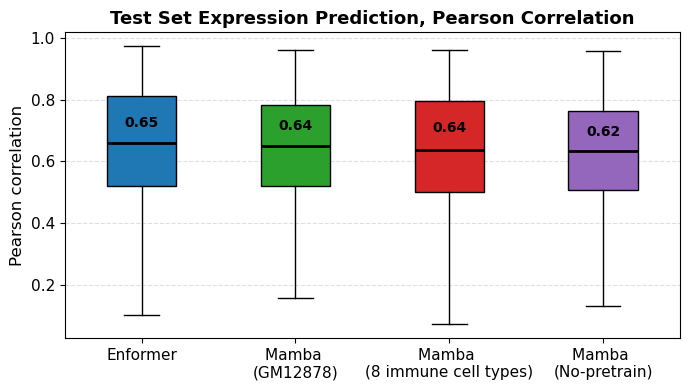

In [3]:
#can we now plot things? first pearson then compare them
#pearson this time
import matplotlib.pyplot as plt
import numpy as np

# Desired order of models (match keys in spearman_results)
ordered_keys = [
    'enformer',
    'GM12878_no_mlm_predictions.npy',
    'immune_CAGE_predictions.npy',
    'nopretrain_predictions.npy'
]

# Pretty display labels
pretty_labels = [
    'Enformer',
    'Mamba \n(GM12878)',
    'Mamba \n(8 immune cell types)',
    'Mamba \n(No-pretrain)'
]

# Matching colors (same order)
colors = ['#1f77b4',  # blue
          '#2ca02c',  # green
          '#d62728',  # red
          '#9467bd']  # purple

# Pull data in correct order
data = [pearson_smooth_results[k] for k in ordered_keys]

# Plot
plt.figure(figsize=(7, 4))
box = plt.boxplot(data, labels=pretty_labels, showfliers=False, patch_artist=True,
                  boxprops=dict(edgecolor='black'),
                  medianprops=dict(color='black', linewidth=2),
                  whiskerprops=dict(color='black'),
                  capprops=dict(color='black'))

# Color each box
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Annotate mean values on each box
for i, vals in enumerate(data):
    mean_val = np.mean(vals)
    plt.text(i + 1, mean_val+0.05, f"{mean_val:.2f}",  # slight offset above median
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Labels and formatting
plt.ylabel("Pearson correlation", fontsize=12)
plt.title("Test Set Expression Prediction, Pearson Correlation", fontsize=13, weight='bold')
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


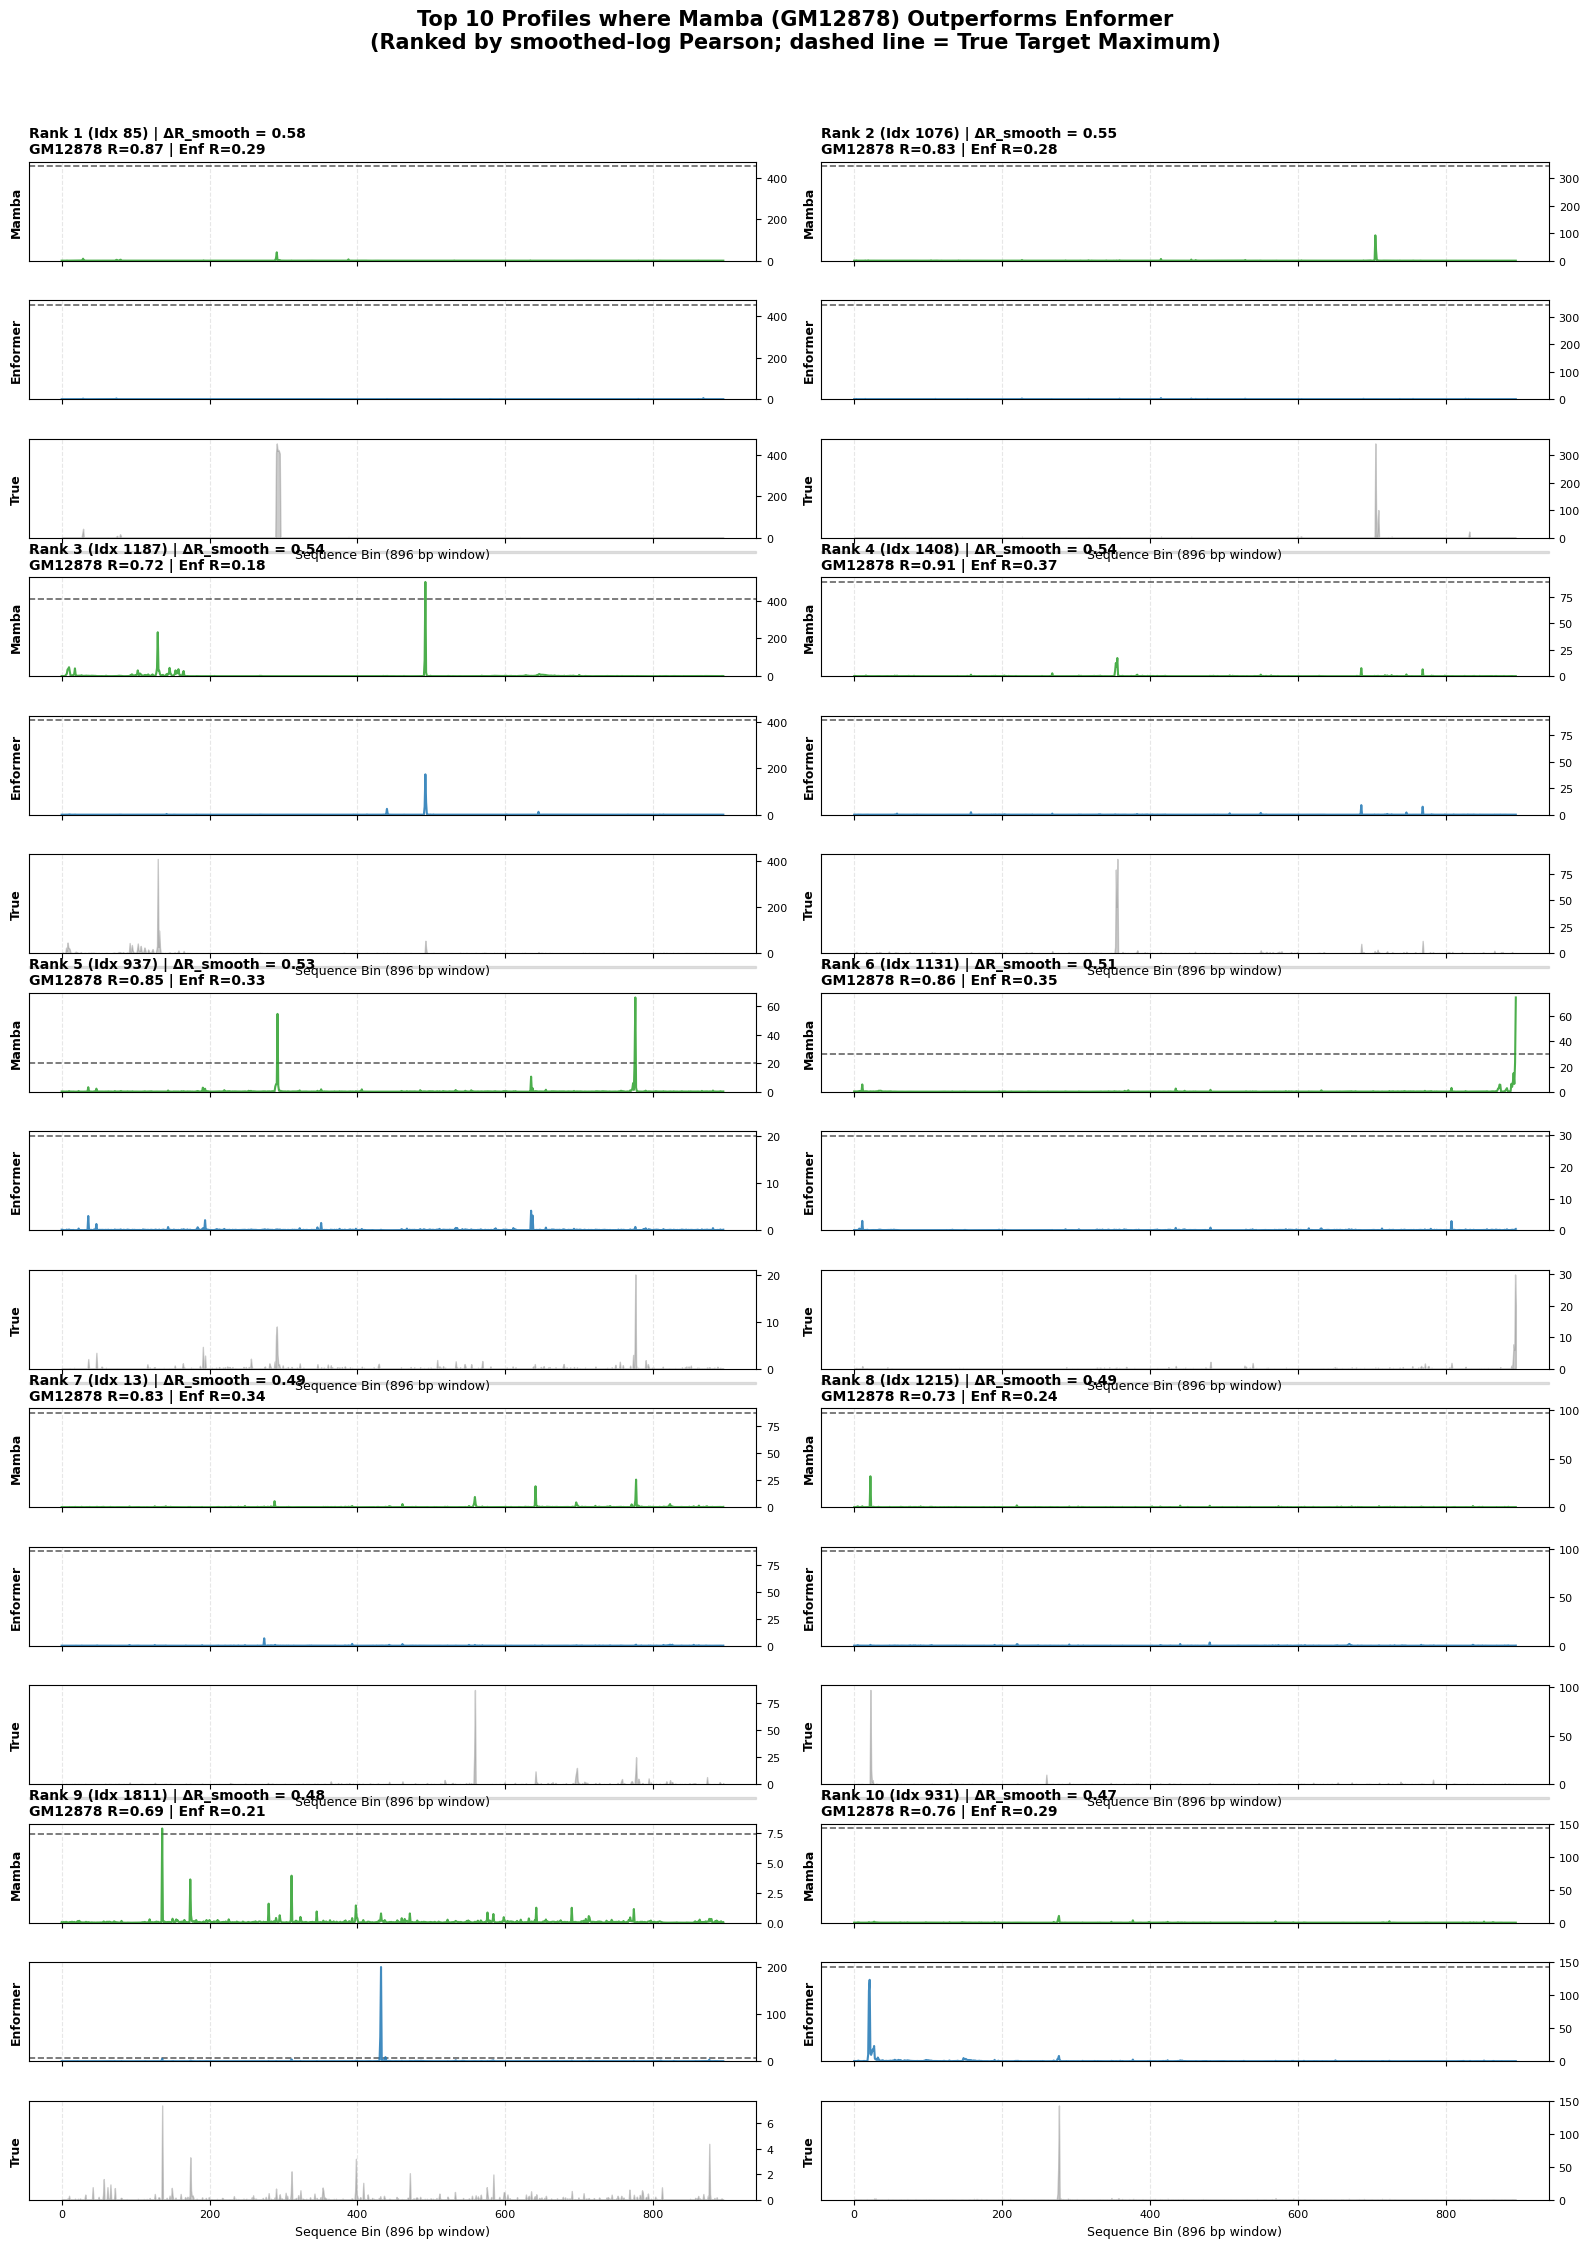

In [2]:
# Top 10 profiles where Mamba (GM12878) beats Enformer, RANKED BY the smoothed-log Pearson.
# Same visualization as before, but the ranking metric now tolerates small positional
# offsets and isn't dominated by the single tallest bin.
import numpy as np
import matplotlib.pyplot as plt

mamba_key = 'GM12878_no_mlm_predictions.npy'
enformer_key = 'enformer'

delta_smooth = pearson_smooth_results[mamba_key] - pearson_smooth_results[enformer_key]
# guard against nan (flat regions) so they don't get ranked to the top
delta_ranked = np.where(np.isnan(delta_smooth), -np.inf, delta_smooth)
top_10_indices = np.argsort(delta_ranked)[-10:][::-1]

fig, axes = plt.subplots(15, 2, figsize=(16, 22), sharex='col')

for rank, idx in enumerate(top_10_indices):
    example_row = rank // 2
    example_col = rank % 2
    start_row = example_row * 3

    ax_mamba    = axes[start_row,     example_col]
    ax_enformer = axes[start_row + 1, example_col]
    ax_true     = axes[start_row + 2, example_col]

    track_mamba = preds[mamba_key][idx]
    track_enf   = preds[enformer_key][idx]
    track_true  = t1[idx]

    # --- SCALE ANCHORING LOGIC ---
    true_max = np.max(track_true)

    # Draw the reference line on the prediction plots
    ax_mamba.axhline(true_max, color='black', linestyle='--', alpha=0.6, linewidth=1.2, label='True Max')
    ax_enformer.axhline(true_max, color='black', linestyle='--', alpha=0.6, linewidth=1.2)

    # Plot the profiles (GM12878 model in green to match earlier plots)
    ax_mamba.plot(track_mamba, color='#2ca02c', alpha=0.85, label='Mamba (GM12878)')
    ax_enformer.plot(track_enf, color='#1f77b4', alpha=0.85, label='Enformer')
    ax_true.fill_between(range(len(track_true)), track_true, color='gray', alpha=0.4, label='True')

    # Set Y-limits to at least the true_max, or expand if the model overpredicts
    ax_mamba.set_ylim(0, max(np.max(track_mamba), true_max) * 1.05)
    ax_enformer.set_ylim(0, max(np.max(track_enf), true_max) * 1.05)
    ax_true.set_ylim(0, true_max * 1.05)
    # -----------------------------

    title_text = (f"Rank {rank+1} (Idx {idx}) | ΔR_smooth = {delta_smooth[idx]:.2f}\n"
                  f"GM12878 R={pearson_smooth_results[mamba_key][idx]:.2f} | "
                  f"Enf R={pearson_smooth_results[enformer_key][idx]:.2f}")
    ax_mamba.set_title(title_text, fontsize=10, weight='bold', loc='left')

    for ax, label in zip([ax_mamba, ax_enformer, ax_true], ['Mamba', 'Enformer', 'True']):
        ax.set_ylabel(label, fontsize=9, weight='bold')
        ax.tick_params(axis='both', labelsize=8)
        ax.grid(axis='x', linestyle='--', alpha=0.3)
        ax.yaxis.tick_right()

    ax_true.set_xlabel("Sequence Bin (896 bp window)", fontsize=9)

    if start_row + 2 < 14:
        rect = plt.Rectangle((0, -0.15), 1, 0.02, transform=ax_true.transAxes,
                             color='black', alpha=0.1, clip_on=False)
        ax_true.add_patch(rect)

plt.suptitle("Top 10 Profiles where Mamba (GM12878) Outperforms Enformer\n"
             "(Ranked by smoothed-log Pearson; dashed line = True Target Maximum)",
             fontsize=15, weight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.show()

# Cell-type specificity, done robustly

The z-score `(GM − mean)/std` blew up because dividing by a near-zero std in a sea of zeros turns negligible absolute differences into huge scores. Instead we use a **directed log fold-change against a high percentile of the other cell types**:

$$\text{specificity} = \log(1+\text{GM12878}) - \log\big(1 + P_{90}[\text{other 637 cell types}]\big)$$

- **ubiquitous** (high everywhere) → spec ≈ 0
- **GM12878-specific** (high in GM12878, low elsewhere) → spec ≫ 0  ← the interesting case
- **silent in GM12878** → spec < 0

No division by variance (can't explode), a percentile instead of the mean (robust to the zero-inflation), and a built-in magnitude floor (if GM12878 itself is ~0, the score is ~0).

**Hypothesis:** if Enformer's multitask training averages away cell-type-specific signal, the individually-trained GM12878 model should beat it *more* on high-specificity regions. The plot below tests exactly that — ΔR_smooth vs specificity, plus a ubiquitous-vs-specific comparison.

In [6]:
# Robust, directed cell-type-specificity score (replaces the blow-up-prone z-score).
# A region is "GM12878-specific" when GM12878's CAGE signal is much higher than what MOST
# other cell types show there. We measure that as a log fold-change of GM12878 over a HIGH
# percentile of the other 637 cell types -- no dividing by std, so near-zero-variance
# regions can't explode, and comparing to a percentile (not the mean) is robust to the
# mass of zeros.

import zarr
labels = zarr.open('/data1/lesliec/sarthak/data/enformer/data/labels.zarr', mode='r')
labels['test'].shape
#now we'll load in just the CAGE tracks
labels_cage = labels['test'][:, :, 4675:]
#now let's sum the labels across cell types and then z score them
labels_cage_sum = np.sum(labels_cage, axis=1)

target_idx = 5110 - 4675  # GM12878 CAGE track within the 638 CAGE tracks

# work in log space on the per-region summed signal computed earlier (labels_cage_sum)
log_sum = np.log1p(labels_cage_sum)               # (1937, 638)
gm_log  = log_sum[:, target_idx]                  # (1937,)  GM12878 magnitude (log)
bg_log  = np.delete(log_sum, target_idx, axis=1)  # (1937, 637)

BG_PCTL = 90  # "higher than 90% of the other cell types"
bg_hi = np.percentile(bg_log, BG_PCTL, axis=1)

# how many natural-log units GM12878 exceeds the bulk of other cell types
# (positive & large -> GM12878-specific; ~0 -> ubiquitous; negative -> silent in GM12878)
specificity = gm_log - bg_hi

print(f"specificity range: [{specificity.min():.2f}, {specificity.max():.2f}]")
print(f"GM12878-specific regions (spec > 1): {(specificity > 1).sum()}")
print(f"ubiquitous-ish regions   (|spec| < 0.2): {(np.abs(specificity) < 0.2).sum()}")

specificity range: [-3.04, 3.51]
GM12878-specific regions (spec > 1): 117
ubiquitous-ish regions   (|spec| < 0.2): 658


mean ΔR  ubiquitous  = -0.033
mean ΔR  GM-specific = 0.001


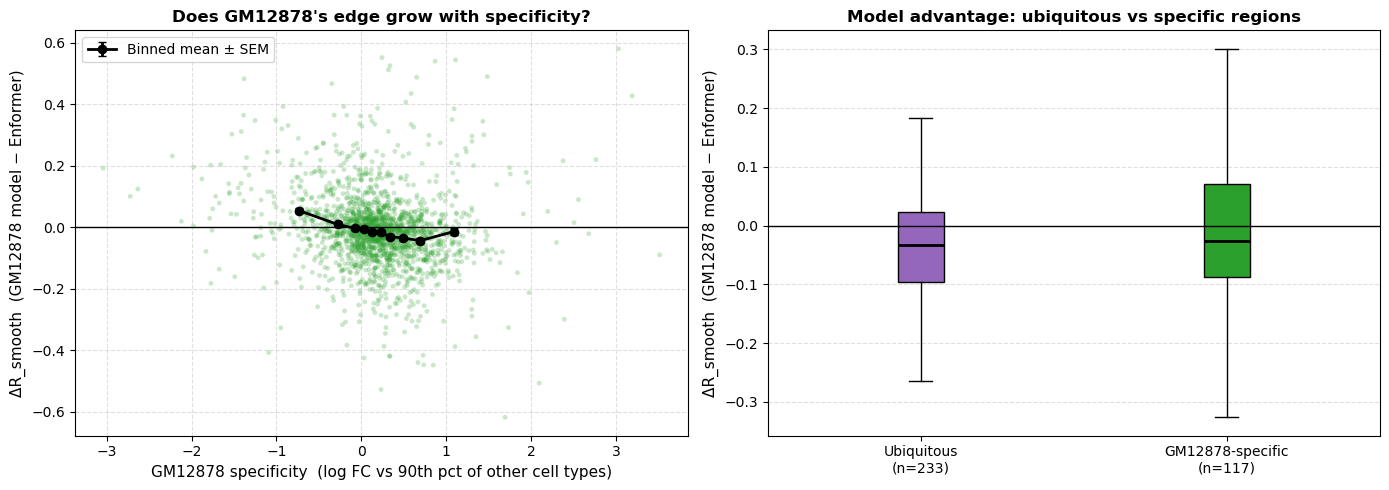

In [7]:
# Hypothesis: the individually-trained GM12878 model beats multitask Enformer MORE on
# cell-type-specific regions. Test it two ways.
mamba_key = 'GM12878_no_mlm_predictions.npy'
enformer_key = 'enformer'

delta = pearson_smooth_results[mamba_key] - pearson_smooth_results[enformer_key]
valid = ~np.isnan(delta)

x = specificity[valid]
y = delta[valid]
gm = gm_log[valid]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- left: scatter + binned trend across specificity deciles ---
ax1.scatter(x, y, s=12, alpha=0.25, color='#2ca02c', edgecolor='none')
ax1.axhline(0, color='black', lw=1)

nbins = 10
edges = np.quantile(x, np.linspace(0, 1, nbins + 1))
edges[-1] += 1e-9
which = np.digitize(x, edges) - 1
centers, means, sems = [], [], []
for b in range(nbins):
    m = which == b
    if m.sum() > 0:
        centers.append(np.median(x[m]))
        means.append(np.mean(y[m]))
        sems.append(np.std(y[m]) / np.sqrt(m.sum()))
ax1.errorbar(centers, means, yerr=sems, color='black', marker='o', lw=2,
             capsize=3, label='Binned mean ± SEM')
ax1.set_xlabel("GM12878 specificity  (log FC vs 90th pct of other cell types)", fontsize=11)
ax1.set_ylabel("ΔR_smooth  (GM12878 model − Enformer)", fontsize=11)
ax1.set_title("Does GM12878's edge grow with specificity?", fontsize=12, weight='bold')
ax1.legend()
ax1.grid(linestyle='--', alpha=0.4)

# --- right: expressed regions split into ubiquitous vs GM12878-specific ---
# restrict to regions actually expressed in GM12878 so ΔR is meaningful
expressed = gm > np.median(gm[gm > 0])
specific_grp = (x > 1.0) & expressed     # >~1 log-unit above the bulk of other cell types
ubiq_grp     = (x < 0.2) & expressed     # roughly as high everywhere else

groups = [y[ubiq_grp], y[specific_grp]]
bp = ax2.boxplot(groups, showfliers=False, patch_artist=True,
                 labels=[f"Ubiquitous\n(n={ubiq_grp.sum()})",
                         f"GM12878-specific\n(n={specific_grp.sum()})"],
                 medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], ['#9467bd', '#2ca02c']):
    patch.set_facecolor(c)
ax2.axhline(0, color='black', lw=1)
ax2.set_ylabel("ΔR_smooth  (GM12878 model − Enformer)", fontsize=11)
ax2.set_title("Model advantage: ubiquitous vs specific regions", fontsize=12, weight='bold')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

print(f"mean ΔR  ubiquitous  = {np.mean(y[ubiq_grp]):.3f}")
print(f"mean ΔR  GM-specific = {np.mean(y[specific_grp]):.3f}")

plt.tight_layout()
plt.show()

mean ΔR  ubiquitous  = -0.014
mean ΔR  GM-specific = 0.010


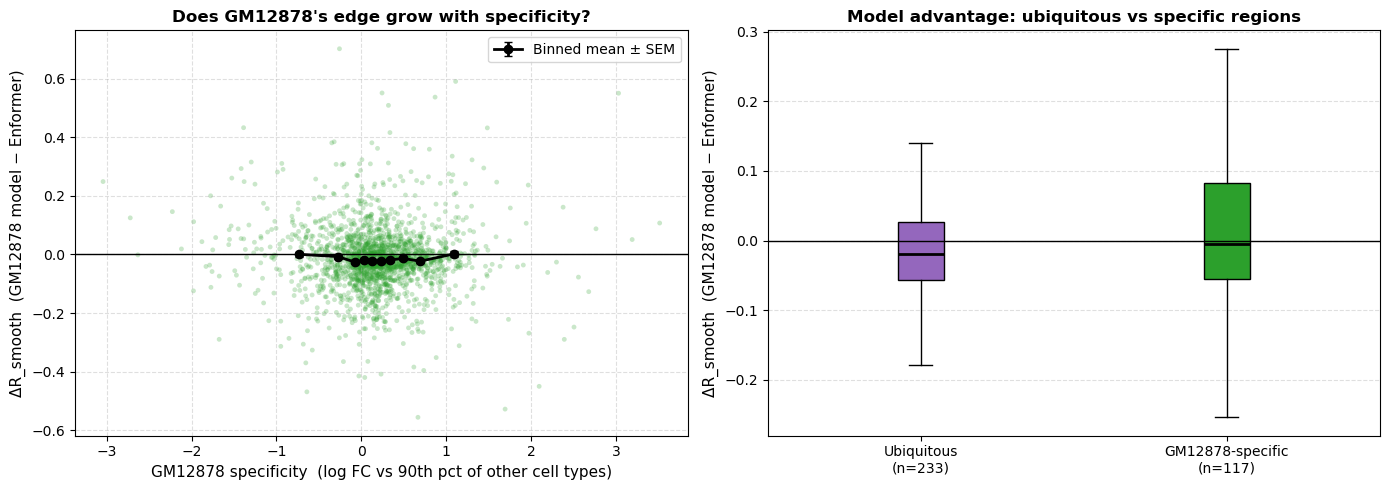

In [8]:
#let's also compare to the immune trained model
mamba_key = 'immune_CAGE_predictions.npy'
enformer_key = 'enformer'

delta = pearson_smooth_results[mamba_key] - pearson_smooth_results[enformer_key]
valid = ~np.isnan(delta)

x = specificity[valid]
y = delta[valid]
gm = gm_log[valid]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- left: scatter + binned trend across specificity deciles ---
ax1.scatter(x, y, s=12, alpha=0.25, color='#2ca02c', edgecolor='none')
ax1.axhline(0, color='black', lw=1)

nbins = 10
edges = np.quantile(x, np.linspace(0, 1, nbins + 1))
edges[-1] += 1e-9
which = np.digitize(x, edges) - 1
centers, means, sems = [], [], []
for b in range(nbins):
    m = which == b
    if m.sum() > 0:
        centers.append(np.median(x[m]))
        means.append(np.mean(y[m]))
        sems.append(np.std(y[m]) / np.sqrt(m.sum()))
ax1.errorbar(centers, means, yerr=sems, color='black', marker='o', lw=2,
             capsize=3, label='Binned mean ± SEM')
ax1.set_xlabel("GM12878 specificity  (log FC vs 90th pct of other cell types)", fontsize=11)
ax1.set_ylabel("ΔR_smooth  (GM12878 model − Enformer)", fontsize=11)
ax1.set_title("Does GM12878's edge grow with specificity?", fontsize=12, weight='bold')
ax1.legend()
ax1.grid(linestyle='--', alpha=0.4)

# --- right: expressed regions split into ubiquitous vs GM12878-specific ---
# restrict to regions actually expressed in GM12878 so ΔR is meaningful
expressed = gm > np.median(gm[gm > 0])
specific_grp = (x > 1.0) & expressed     # >~1 log-unit above the bulk of other cell types
ubiq_grp     = (x < 0.2) & expressed     # roughly as high everywhere else

groups = [y[ubiq_grp], y[specific_grp]]
bp = ax2.boxplot(groups, showfliers=False, patch_artist=True,
                 labels=[f"Ubiquitous\n(n={ubiq_grp.sum()})",
                         f"GM12878-specific\n(n={specific_grp.sum()})"],
                 medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], ['#9467bd', '#2ca02c']):
    patch.set_facecolor(c)
ax2.axhline(0, color='black', lw=1)
ax2.set_ylabel("ΔR_smooth  (GM12878 model − Enformer)", fontsize=11)
ax2.set_title("Model advantage: ubiquitous vs specific regions", fontsize=12, weight='bold')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

print(f"mean ΔR  ubiquitous  = {np.mean(y[ubiq_grp]):.3f}")
print(f"mean ΔR  GM-specific = {np.mean(y[specific_grp]):.3f}")

plt.tight_layout()
plt.show()

## Sanity check: do the top-specificity regions actually look specific?

The performance is ~the same on ubiquitous vs cell-type-specific regions — surprising, since a model trained only on GM12878 "should" win exactly where GM12878 differs from other cell types. Before reading anything into that null result, confirm the metric is really picking GM12878-specific regions. Below, the top-scoring regions show the **GM12878 true CAGE profile (green)** against a **random sample of other cell types (gray)** and the **P90 background envelope (dashed)**. If GM12878 towers over the rest, the metric is doing its job and the null result is real.

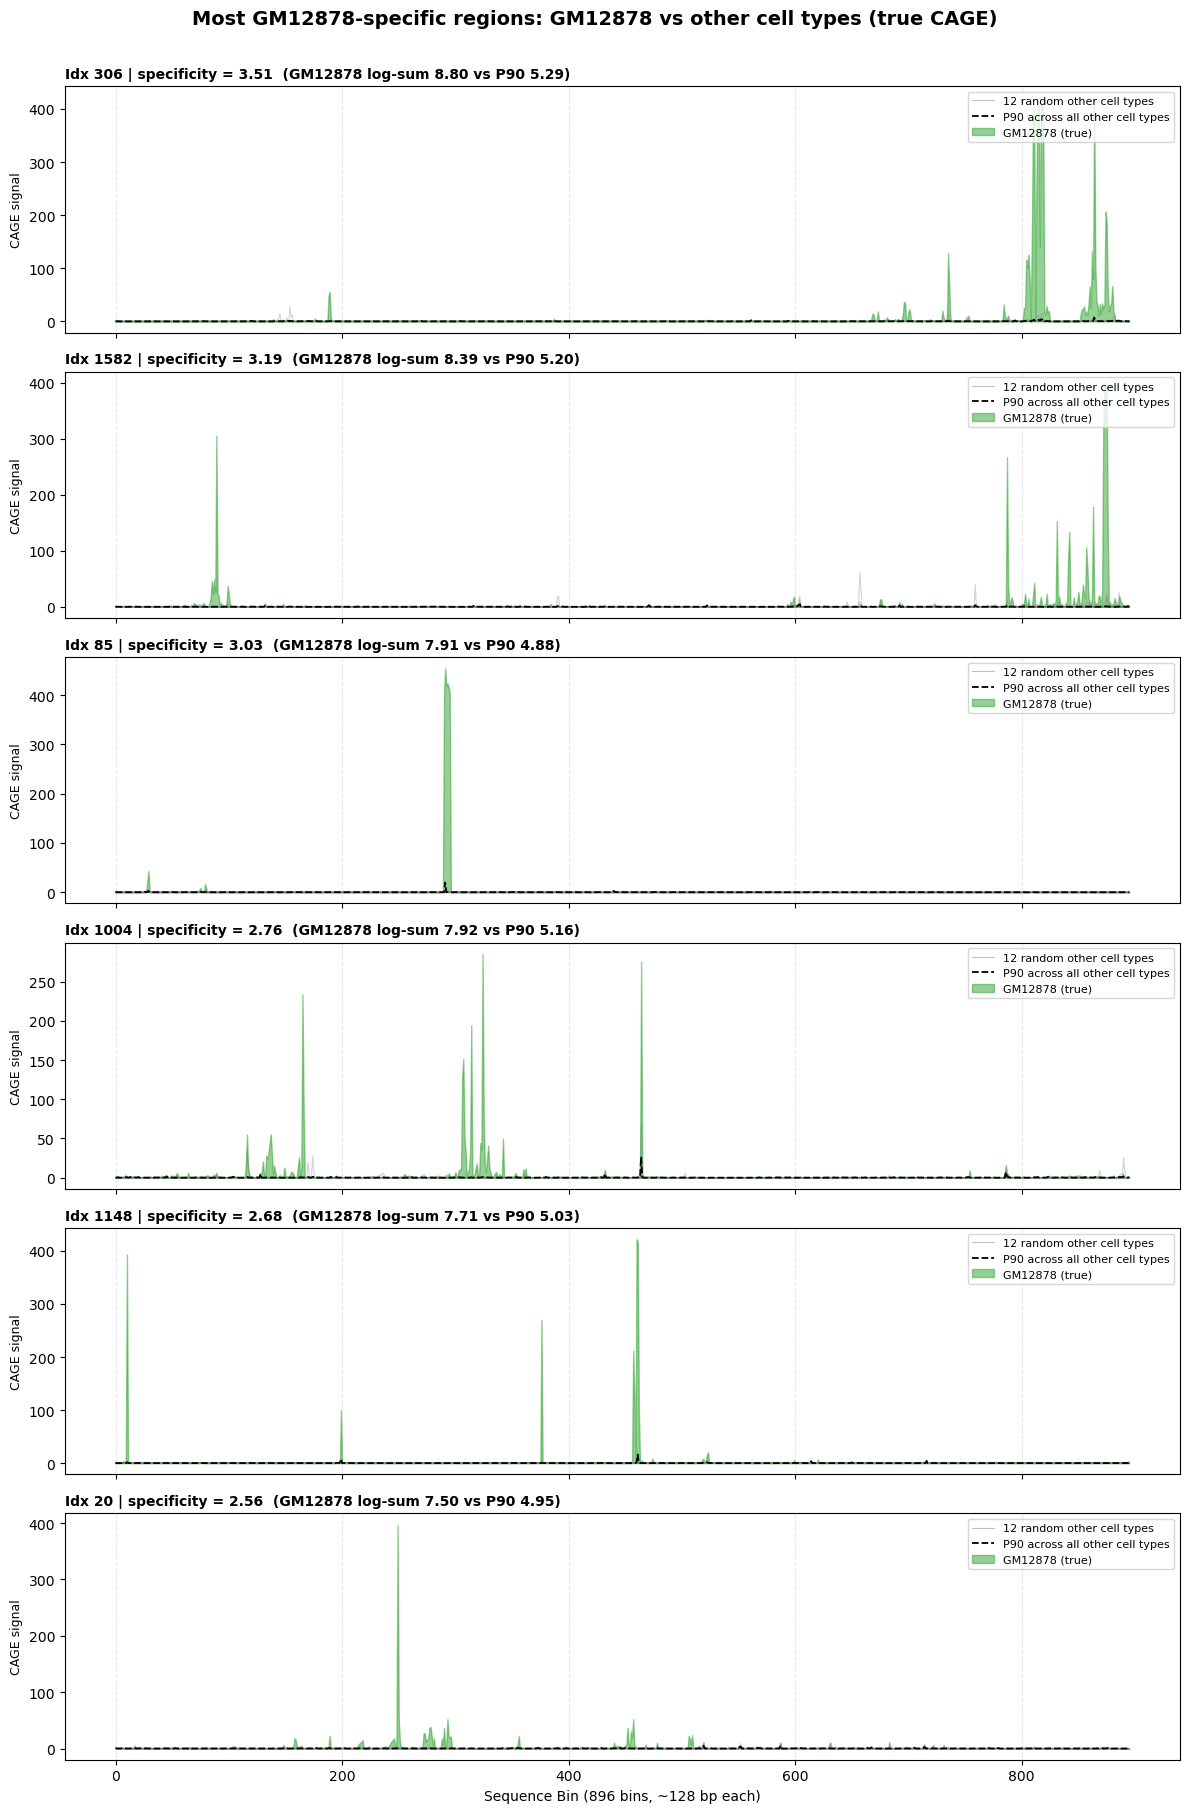

In [9]:
# Sanity check the specificity metric: do the top-scoring regions actually LOOK GM12878-specific?
# Plot each region's GM12878 TRUE CAGE profile against a random sample of other cell types.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
n_examples = 6
n_random = 12  # how many other cell types to draw for visual context

top_spec_idx = np.argsort(specificity)[-n_examples:][::-1]

# columns of labels_cage that are NOT GM12878
other_cols = np.delete(np.arange(labels_cage.shape[2]), target_idx)

fig, axes = plt.subplots(n_examples, 1, figsize=(12, 3 * n_examples), sharex=True)

for ax, idx in zip(axes, top_spec_idx):
    region = labels_cage[idx]                    # (896, 638) true CAGE, all cell types
    gm_prof = region[:, target_idx]
    # per-bin 90th percentile across all other cell types (the reference the metric uses)
    p90_prof = np.percentile(region[:, other_cols], BG_PCTL, axis=1)
    # a random sample of other cell types for visual context
    sample = rng.choice(other_cols, size=n_random, replace=False)

    for c in sample:
        ax.plot(region[:, c], color='gray', alpha=0.35, lw=0.8)
    ax.plot([], [], color='gray', alpha=0.5, lw=0.8, label=f'{n_random} random other cell types')
    ax.plot(p90_prof, color='black', ls='--', lw=1.3, label='P90 across all other cell types')
    ax.fill_between(range(len(gm_prof)), gm_prof, color='#2ca02c', alpha=0.5, label='GM12878 (true)')

    ax.set_title(f"Idx {idx} | specificity = {specificity[idx]:.2f}  "
                 f"(GM12878 log-sum {gm_log[idx]:.2f} vs P90 {bg_hi[idx]:.2f})",
                 fontsize=10, weight='bold', loc='left')
    ax.set_ylabel("CAGE signal", fontsize=9)
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel("Sequence Bin (896 bins, ~128 bp each)", fontsize=10)
plt.suptitle("Most GM12878-specific regions: GM12878 vs other cell types (true CAGE)",
             fontsize=14, weight='bold', y=1.005)
plt.tight_layout()
plt.show()

In [11]:
# Given a test-set index, locate the genomic coordinate of the peak (largest true GM12878 bin).
import pandas as pd
import numpy as np

BED_PATH = '/data1/lesliec/sarthak/data/DK_zarr/sequences_enformer.bed'
SEQ_LEN  = 131072       # full length of each region in the bed file
PRED_LEN = 896 * 128    # 114688 -> the CENTER portion that is actually predicted
BIN      = 128
CROP     = (SEQ_LEN - PRED_LEN) // 2   # 8192 bp trimmed from each side before prediction

# load the bed once and keep only the 'test' rows, in file order
# (this order is what the t1 / preds indices refer to)
_bed = pd.read_csv(BED_PATH, sep='\t', header=None)
_test_bed = _bed[_bed.iloc[:, -1] == 'test'].reset_index(drop=True)
assert len(_test_bed) == t1.shape[0], \
    f"test rows in bed ({len(_test_bed)}) != number of test regions ({t1.shape[0]})"

def peak_coord(idx, targets=t1):
    """For test-set region `idx`, find the bin with the largest true GM12878 signal
    and return its genomic coordinate (BED, 0-based half-open)."""
    chrom = _test_bed.iloc[idx, 0]
    region_start, region_end = int(_test_bed.iloc[idx, 1]), int(_test_bed.iloc[idx, 2])
    prof = targets[idx]
    peak_bin = int(np.argmax(prof))
    # the predicted window begins CROP bp into the full bed region
    bin_start  = region_start + CROP + peak_bin * BIN
    bin_end    = bin_start + BIN
    bin_center = bin_start + BIN // 2
    return {
        'idx': idx,
        'chrom': chrom,
        'region_start': region_start,
        'region_end': region_end,
        'region_locus': f"{chrom}:{region_start}-{region_end}",
        'peak_bin': peak_bin,
        'peak_value': float(prof[peak_bin]),
        'bin_start': bin_start,
        'bin_end': bin_end,
        'bin_center': bin_center,
        'locus': f"{chrom}:{bin_start}-{bin_end}",
    }

# demo
peak_coord(85)

{'idx': 85,
 'chrom': 'chr22',
 'region_start': 22150234,
 'region_end': 22281306,
 'region_locus': 'chr22:22150234-22281306',
 'peak_bin': 291,
 'peak_value': 454.5,
 'bin_start': 22195674,
 'bin_end': 22195802,
 'bin_center': 22195738,
 'locus': 'chr22:22195674-22195802'}

# Redo analysis with alphagenome

In [2]:
# ── Redo analysis with AlphaGenome: SETUP ───────────────────────────────────
# Self-contained: run THIS cell first, then the two plot cells below, without
# needing any earlier cell in the notebook. It loads every model's predictions
# (now including AlphaGenome), the shared GM12878 CAGE targets, and computes the
# smoothed-log Pearson metric for all models.
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr

MODEL_OUT = '/data1/lesliec/sarthak/data/joint_playground/model_out'

# Enformer full output (memory-mapped); GM12878 CAGE lives at track 5110
enformer_full = np.load('/data1/lesliec/sarthak/data/enformer/data/model_out/enformer.npy', mmap_mode='r')

# AlphaGenome preds are (1937, 896, 273); track 156 is the matching GM12878 CAGE track
ALPHAGENOME_TRACK = 156

model_names = [
    'enformer',
    'GM12878_no_mlm_predictions.npy',
    'immune_CAGE_predictions.npy',
    'nopretrain_predictions.npy',
    'alphagenome_cage_test_128bp.npy',
]

preds = {}
for model_name in model_names:
    if model_name == 'enformer':
        preds[model_name] = enformer_full[:, :, 5110]
    elif model_name == 'alphagenome_cage_test_128bp.npy':
        ag = np.load(f'{MODEL_OUT}/{model_name}', mmap_mode='r')
        preds[model_name] = ag[:, :, ALPHAGENOME_TRACK]  # subset to GM12878 CAGE track
    else:
        preds[model_name] = np.load(f'{MODEL_OUT}/{model_name}')
        if preds[model_name].ndim == 3:
            preds[model_name] = preds[model_name][:, :, 0]
    print(f"{model_name}: {preds[model_name].shape}")

# shared GM12878 CAGE targets (identical for every model)
t1 = np.load(f'{MODEL_OUT}/GM12878_base_targets_conv.npy')
print('targets:', t1.shape)

# --- smoothed-log Pearson (the "bottom" metric): log1p + Gaussian smoothing ---
# 1) log1p tames the heavy-tailed CAGE signal so the score isn't dominated by the
#    single tallest bin. 2) Gaussian smoothing makes a "1 bin off" prediction a
#    near-hit instead of a total miss, while a peak on the opposite end still scores low.
SMOOTH_SIGMA = 1.5  # in bins (~128bp each); raise for more positional tolerance

def smoothed_log_pearson(pred, true, sigma=SMOOTH_SIGMA):
    p = gaussian_filter1d(np.log1p(np.clip(pred, 0, None)), sigma=sigma)
    t = gaussian_filter1d(np.log1p(np.clip(true, 0, None)), sigma=sigma)
    # a flat (all-zero) profile has no shape to correlate -> undefined
    if np.std(p) < 1e-8 or np.std(t) < 1e-8:
        return np.nan
    return pearsonr(p, t)[0]

pearson_smooth_results = {}
for name, arr in preds.items():
    assert arr.shape == t1.shape, f"{name} vs t1 shape mismatch!"
    vals = np.array([smoothed_log_pearson(arr[i], t1[i]) for i in tqdm(range(arr.shape[0]), desc=name)])
    pearson_smooth_results[name] = vals
    print(f"{name}: mean smoothed-log Pearson = {np.nanmean(vals):.3f} "
          f"({np.isnan(vals).sum()} flat/undefined regions)")

pearson_results = {}
for name, arr in preds.items():
    assert arr.shape == t1.shape, f"{name} vs t1 shape mismatch!"
    vals = np.array([pearsonr(arr[i], t1[i])[0] for i in tqdm(range(arr.shape[0]), desc=name)])
    pearson_results[name] = vals
    print(f"{name}: mean Pearson = {np.nanmean(vals):.3f} "
          f"({np.isnan(vals).sum()} flat/undefined regions)")


enformer: (1937, 896)
GM12878_no_mlm_predictions.npy: (1937, 896)
immune_CAGE_predictions.npy: (1937, 896)
nopretrain_predictions.npy: (1937, 896)
alphagenome_cage_test_128bp.npy: (1937, 896)
targets: (1937, 896)


enformer: 100%|██████████| 1937/1937 [00:09<00:00, 196.91it/s]


enformer: mean smoothed-log Pearson = 0.651 (0 flat/undefined regions)


GM12878_no_mlm_predictions.npy: 100%|██████████| 1937/1937 [00:01<00:00, 1306.41it/s]


GM12878_no_mlm_predictions.npy: mean smoothed-log Pearson = 0.641 (0 flat/undefined regions)


...

immune_CAGE_predictions.npy: mean Pearson = 0.626 (0 flat/undefined regions)


nopretrain_predictions.npy: 100%|██████████| 1937/1937 [00:01<00:00, 1778.73it/s]


nopretrain_predictions.npy: mean Pearson = 0.603 (0 flat/undefined regions)


alphagenome_cage_test_128bp.npy: 100%|██████████| 1937/1937 [00:01<00:00, 1671.94it/s]

alphagenome_cage_test_128bp.npy: mean Pearson = 0.428 (0 flat/undefined regions)


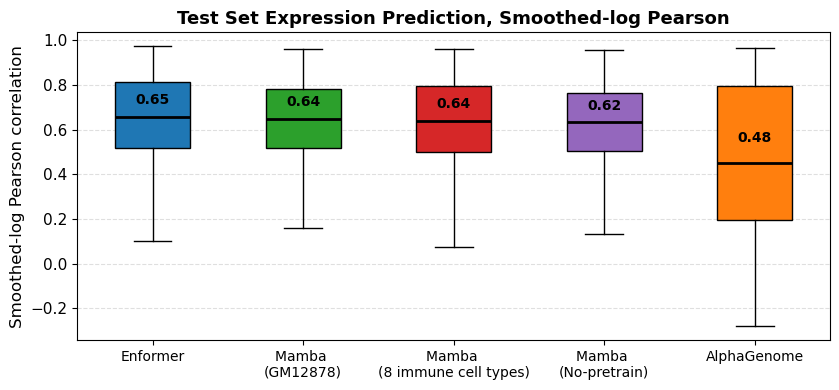

In [3]:
# Boxplot: smoothed-log Pearson across all models, with AlphaGenome added.
import matplotlib.pyplot as plt
import numpy as np

ordered_keys = [
    'enformer',
    'GM12878_no_mlm_predictions.npy',
    'immune_CAGE_predictions.npy',
    'nopretrain_predictions.npy',
    'alphagenome_cage_test_128bp.npy',
]

pretty_labels = [
    'Enformer',
    'Mamba \n(GM12878)',
    'Mamba \n(8 immune cell types)',
    'Mamba \n(No-pretrain)',
    'AlphaGenome',
]

colors = ['#1f77b4',  # blue   (Enformer)
          '#2ca02c',  # green  (GM12878)
          '#d62728',  # red    (immune)
          '#9467bd',  # purple (no-pretrain)
          '#ff7f0e']  # orange (AlphaGenome)

# drop nan (flat/undefined) regions per model before boxing
data = [pearson_smooth_results[k][~np.isnan(pearson_smooth_results[k])] for k in ordered_keys]

plt.figure(figsize=(8.5, 4))
box = plt.boxplot(data, labels=pretty_labels, showfliers=False, patch_artist=True,
                  boxprops=dict(edgecolor='black'),
                  medianprops=dict(color='black', linewidth=2),
                  whiskerprops=dict(color='black'),
                  capprops=dict(color='black'))

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

for i, vals in enumerate(data):
    mean_val = np.mean(vals)
    plt.text(i + 1, mean_val + 0.05, f"{mean_val:.2f}",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylabel("Smoothed-log Pearson correlation", fontsize=12)
plt.title("Test Set Expression Prediction, Smoothed-log Pearson", fontsize=13, weight='bold')
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


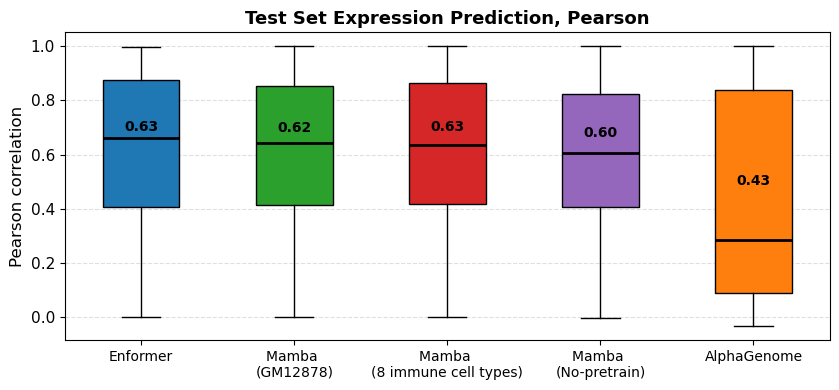

In [4]:
#let's compare to normal pearson
# Boxplot: smoothed-log Pearson across all models, with AlphaGenome added.
import matplotlib.pyplot as plt
import numpy as np

ordered_keys = [
    'enformer',
    'GM12878_no_mlm_predictions.npy',
    'immune_CAGE_predictions.npy',
    'nopretrain_predictions.npy',
    'alphagenome_cage_test_128bp.npy',
]

pretty_labels = [
    'Enformer',
    'Mamba \n(GM12878)',
    'Mamba \n(8 immune cell types)',
    'Mamba \n(No-pretrain)',
    'AlphaGenome',
]

colors = ['#1f77b4',  # blue   (Enformer)
          '#2ca02c',  # green  (GM12878)
          '#d62728',  # red    (immune)
          '#9467bd',  # purple (no-pretrain)
          '#ff7f0e']  # orange (AlphaGenome)

# drop nan (flat/undefined) regions per model before boxing
data = [pearson_results[k][~np.isnan(pearson_results[k])] for k in ordered_keys]

plt.figure(figsize=(8.5, 4))
box = plt.boxplot(data, labels=pretty_labels, showfliers=False, patch_artist=True,
                  boxprops=dict(edgecolor='black'),
                  medianprops=dict(color='black', linewidth=2),
                  whiskerprops=dict(color='black'),
                  capprops=dict(color='black'))

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

for i, vals in enumerate(data):
    mean_val = np.mean(vals)
    plt.text(i + 1, mean_val + 0.05, f"{mean_val:.2f}",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylabel("Pearson correlation", fontsize=12)
plt.title("Test Set Expression Prediction, Pearson", fontsize=13, weight='bold')
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


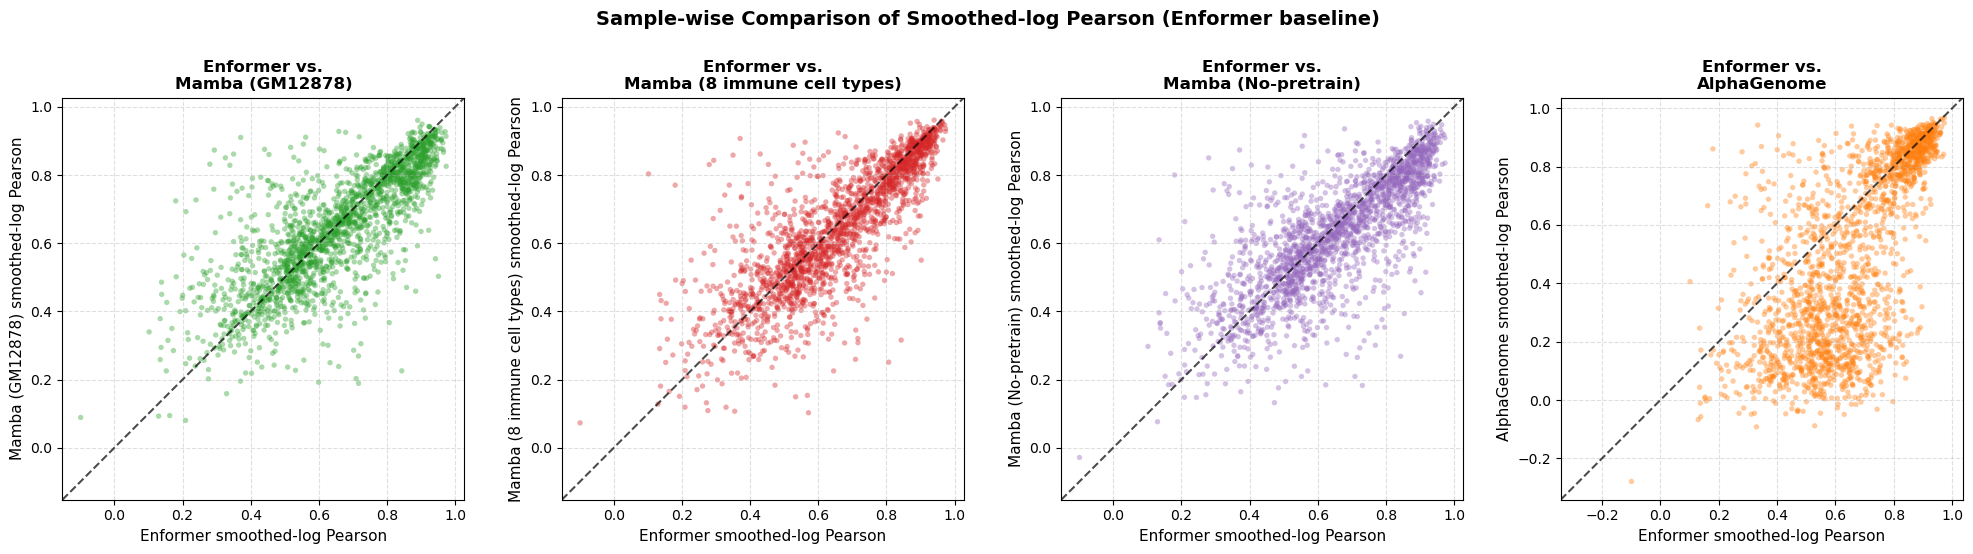

In [5]:
# Sample-wise correlation comparison (smoothed-log Pearson), Enformer as baseline.
# Each panel scatters a model's per-region smoothed-log Pearson against Enformer's;
# points above the y=x line are regions where that model beats Enformer.
import matplotlib.pyplot as plt
import numpy as np

baseline_key = 'enformer'
compare_keys = [
    'GM12878_no_mlm_predictions.npy',
    'immune_CAGE_predictions.npy',
    'nopretrain_predictions.npy',
    'alphagenome_cage_test_128bp.npy',
]
compare_labels = [
    'Mamba (GM12878)',
    'Mamba (8 immune cell types)',
    'Mamba (No-pretrain)',
    'AlphaGenome',
]
compare_colors = ['#2ca02c',  # green  (GM12878)
                  '#d62728',  # red    (immune)
                  '#9467bd',  # purple (no-pretrain)
                  '#ff7f0e']  # orange (AlphaGenome)

baseline_data = pearson_smooth_results[baseline_key]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, (key, lab, col) in enumerate(zip(compare_keys, compare_labels, compare_colors)):
    ax = axes[i]
    comp_data = pearson_smooth_results[key]

    # only regions where BOTH models have a defined (non-nan) score
    m = ~np.isnan(baseline_data) & ~np.isnan(comp_data)
    xb, yb = baseline_data[m], comp_data[m]

    ax.scatter(xb, yb, color=col, alpha=0.4, s=15, edgecolor='none')

    min_val = min(np.min(xb), np.min(yb))
    max_val = max(np.max(xb), np.max(yb))
    buffer = (max_val - min_val) * 0.05
    ax.plot([min_val - buffer, max_val + buffer],
            [min_val - buffer, max_val + buffer],
            color='black', linestyle='--', alpha=0.7)

    ax.set_xlabel("Enformer smoothed-log Pearson", fontsize=11)
    ax.set_ylabel(f"{lab} smoothed-log Pearson", fontsize=11)
    ax.set_title(f"Enformer vs.\n{lab}", fontsize=12, weight='bold')
    ax.set_box_aspect(1)
    ax.set_xlim([min_val - buffer, max_val + buffer])
    ax.set_ylim([min_val - buffer, max_val + buffer])
    ax.grid(linestyle='--', alpha=0.4)

plt.suptitle("Sample-wise Comparison of Smoothed-log Pearson (Enformer baseline)",
             fontsize=14, weight='bold', y=1.05)
plt.tight_layout()
plt.show()


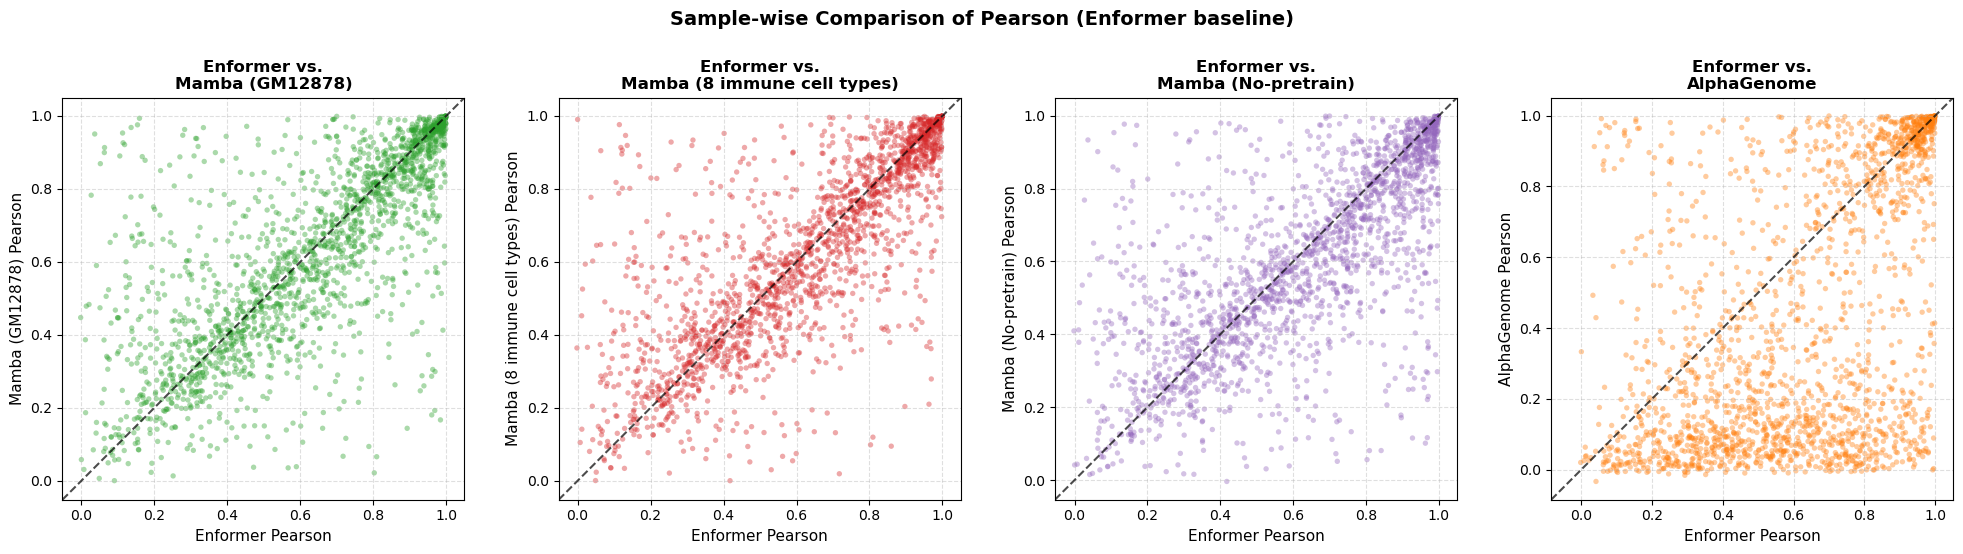

In [6]:
# Sample-wise correlation comparison (smoothed-log Pearson), Enformer as baseline.
# Each panel scatters a model's per-region smoothed-log Pearson against Enformer's;
# points above the y=x line are regions where that model beats Enformer.
import matplotlib.pyplot as plt
import numpy as np

baseline_key = 'enformer'
compare_keys = [
    'GM12878_no_mlm_predictions.npy',
    'immune_CAGE_predictions.npy',
    'nopretrain_predictions.npy',
    'alphagenome_cage_test_128bp.npy',
]
compare_labels = [
    'Mamba (GM12878)',
    'Mamba (8 immune cell types)',
    'Mamba (No-pretrain)',
    'AlphaGenome',
]
compare_colors = ['#2ca02c',  # green  (GM12878)
                  '#d62728',  # red    (immune)
                  '#9467bd',  # purple (no-pretrain)
                  '#ff7f0e']  # orange (AlphaGenome)

baseline_data = pearson_results[baseline_key]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, (key, lab, col) in enumerate(zip(compare_keys, compare_labels, compare_colors)):
    ax = axes[i]
    comp_data = pearson_results[key]

    # only regions where BOTH models have a defined (non-nan) score
    m = ~np.isnan(baseline_data) & ~np.isnan(comp_data)
    xb, yb = baseline_data[m], comp_data[m]

    ax.scatter(xb, yb, color=col, alpha=0.4, s=15, edgecolor='none')

    min_val = min(np.min(xb), np.min(yb))
    max_val = max(np.max(xb), np.max(yb))
    buffer = (max_val - min_val) * 0.05
    ax.plot([min_val - buffer, max_val + buffer],
            [min_val - buffer, max_val + buffer],
            color='black', linestyle='--', alpha=0.7)

    ax.set_xlabel("Enformer Pearson", fontsize=11)
    ax.set_ylabel(f"{lab} Pearson", fontsize=11)
    ax.set_title(f"Enformer vs.\n{lab}", fontsize=12, weight='bold')
    ax.set_box_aspect(1)
    ax.set_xlim([min_val - buffer, max_val + buffer])
    ax.set_ylim([min_val - buffer, max_val + buffer])
    ax.grid(linestyle='--', alpha=0.4)

plt.suptitle("Sample-wise Comparison of Pearson (Enformer baseline)",
             fontsize=14, weight='bold', y=1.05)
plt.tight_layout()
plt.show()


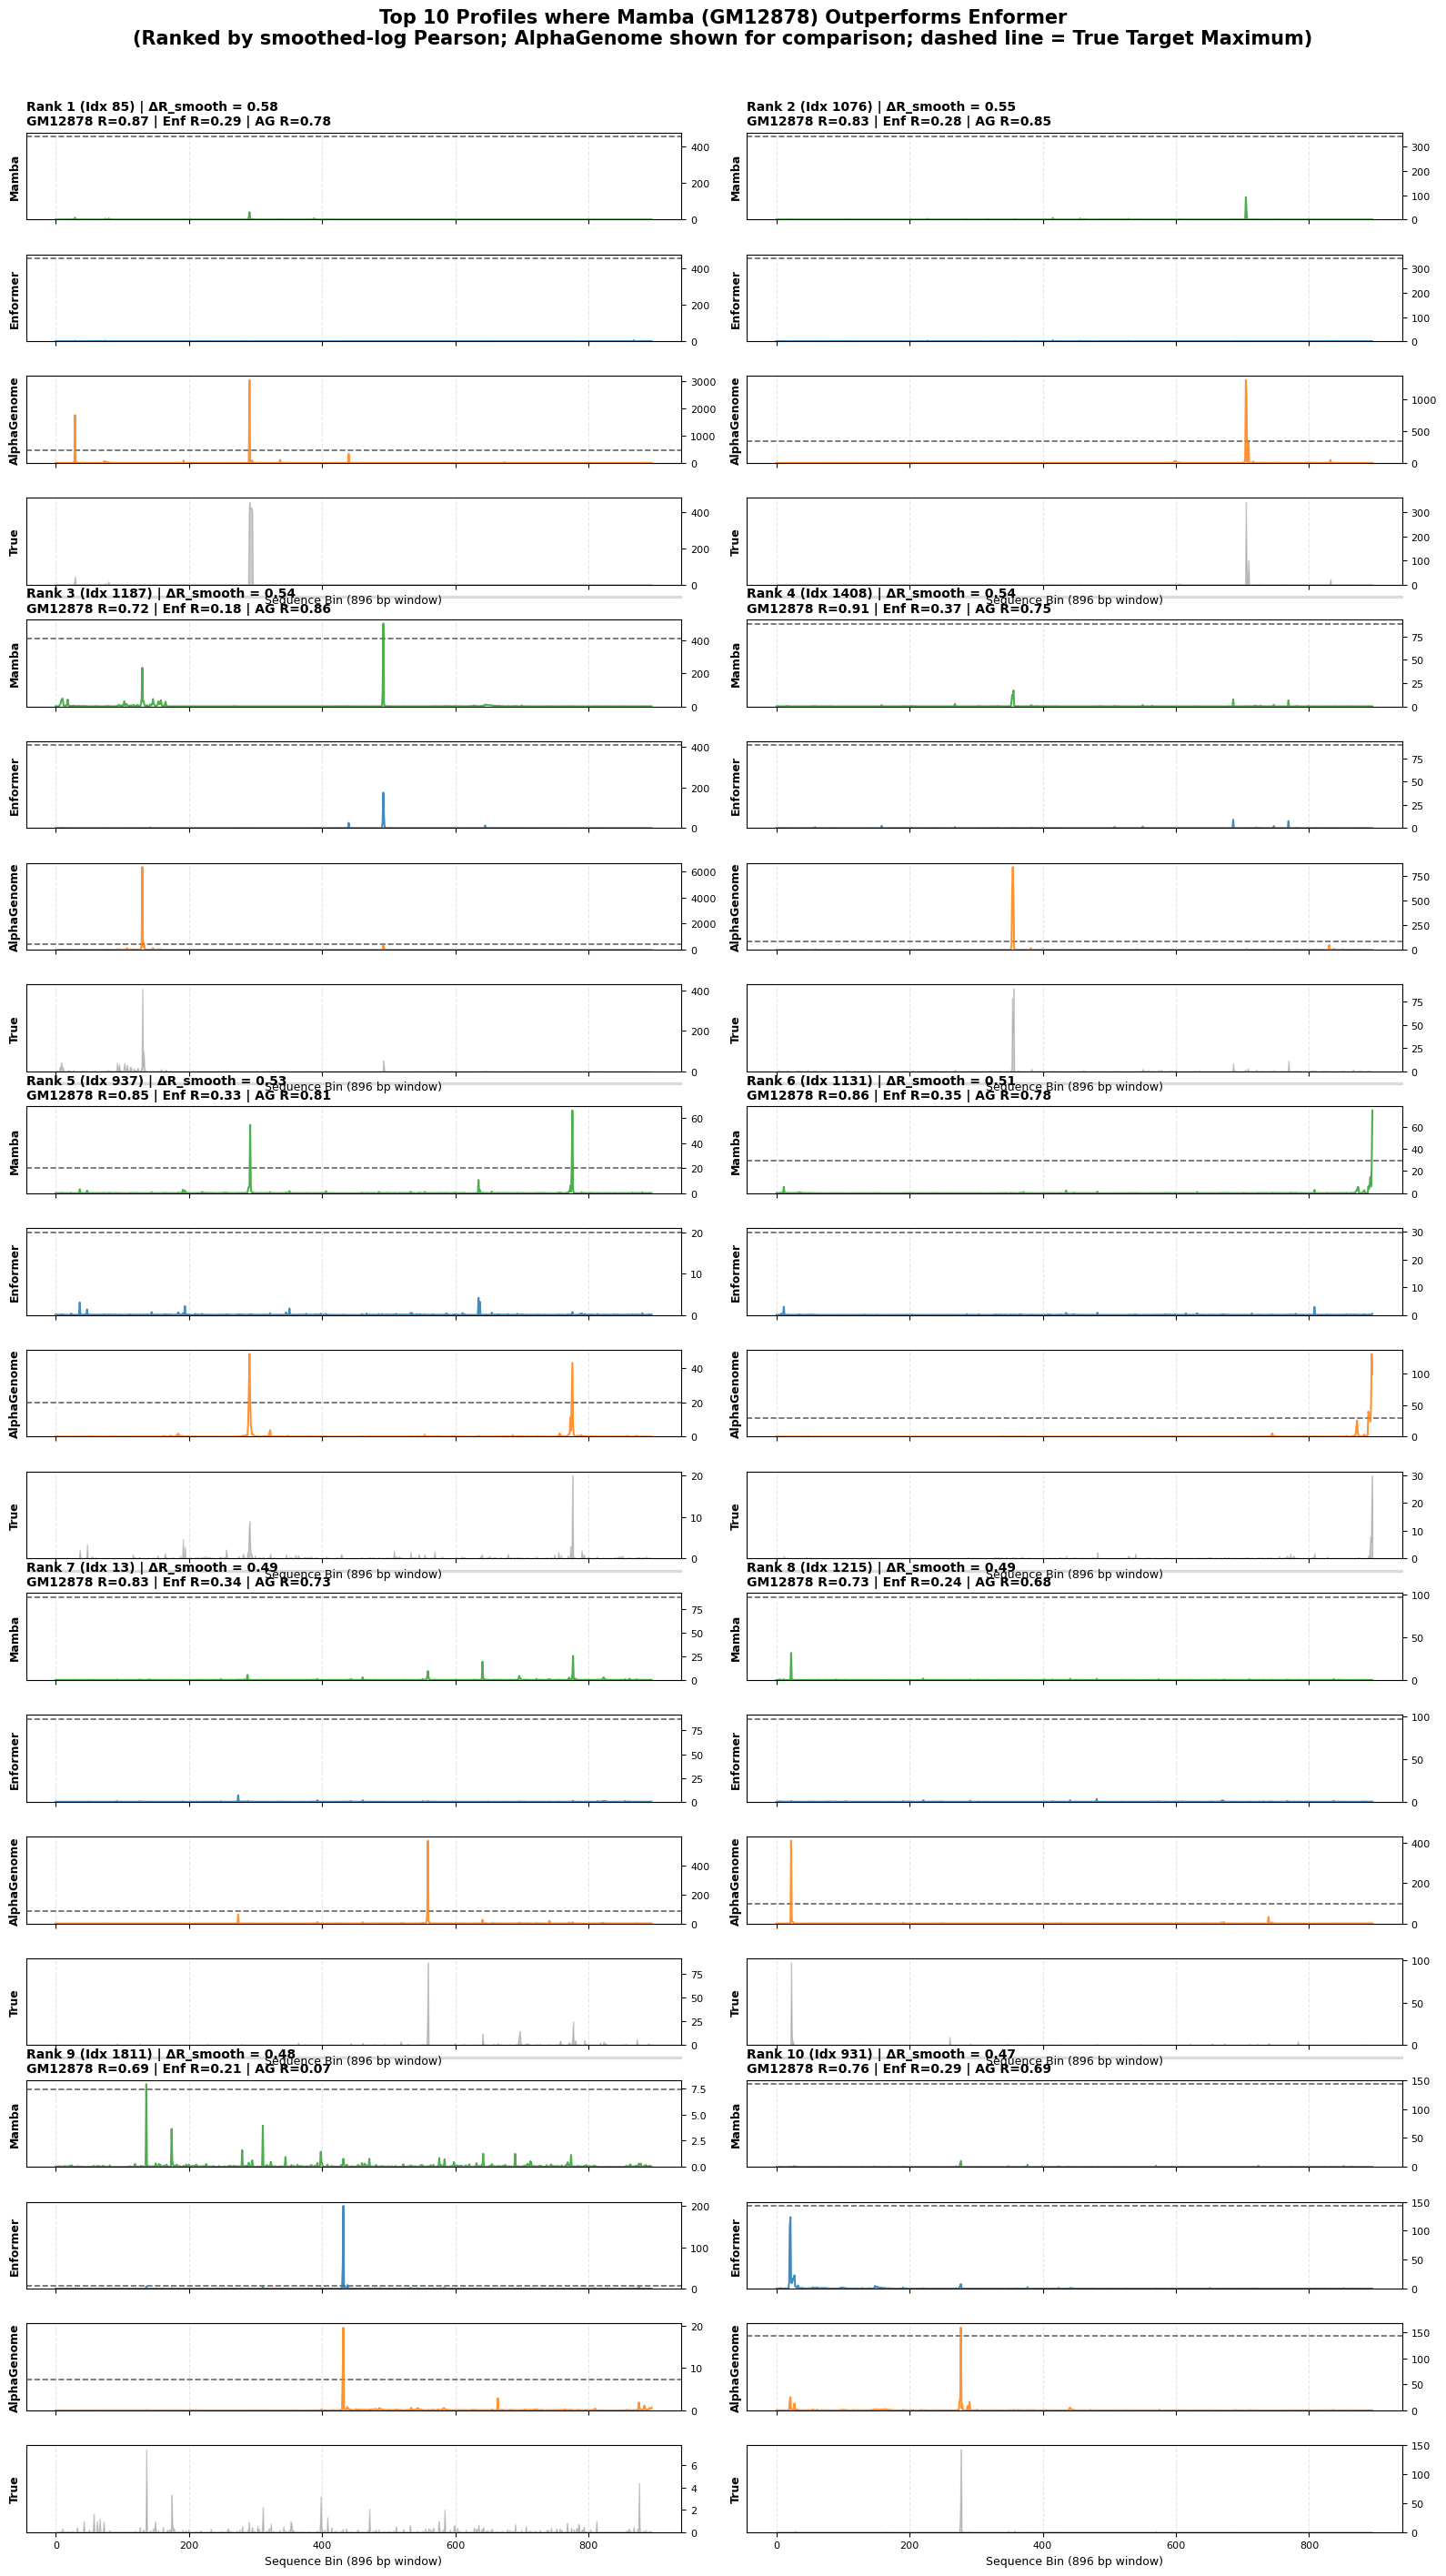

In [7]:
# Top 10 profiles where Mamba (GM12878) beats Enformer (ranked by smoothed-log Pearson),
# now expanded to ALSO show the AlphaGenome prediction for each example.
# Per example, 4 stacked panels: Mamba (GM12878) / Enformer / AlphaGenome / True.
import numpy as np
import matplotlib.pyplot as plt

mamba_key = 'GM12878_no_mlm_predictions.npy'
enformer_key = 'enformer'
ag_key = 'alphagenome_cage_test_128bp.npy'

# same ranking as before: where GM12878 beats Enformer under the smoothed metric
delta_smooth = pearson_smooth_results[mamba_key] - pearson_smooth_results[enformer_key]
delta_ranked = np.where(np.isnan(delta_smooth), -np.inf, delta_smooth)  # keep flat regions out of the top
top_10_indices = np.argsort(delta_ranked)[-10:][::-1]

N_SUB = 4  # Mamba, Enformer, AlphaGenome, True
fig, axes = plt.subplots(5 * N_SUB, 2, figsize=(16, 28), sharex='col')

for rank, idx in enumerate(top_10_indices):
    example_row = rank // 2
    example_col = rank % 2
    start_row = example_row * N_SUB

    ax_mamba    = axes[start_row,     example_col]
    ax_enformer = axes[start_row + 1, example_col]
    ax_ag       = axes[start_row + 2, example_col]
    ax_true     = axes[start_row + 3, example_col]

    track_mamba = preds[mamba_key][idx]
    track_enf   = preds[enformer_key][idx]
    track_ag    = preds[ag_key][idx]
    track_true  = t1[idx]

    # --- SCALE ANCHORING LOGIC ---
    true_max = np.max(track_true)

    # reference line at the true target maximum on every prediction plot
    ax_mamba.axhline(true_max, color='black', linestyle='--', alpha=0.6, linewidth=1.2, label='True Max')
    ax_enformer.axhline(true_max, color='black', linestyle='--', alpha=0.6, linewidth=1.2)
    ax_ag.axhline(true_max, color='black', linestyle='--', alpha=0.6, linewidth=1.2)

    # profiles (GM12878 green, Enformer blue, AlphaGenome orange, True gray)
    ax_mamba.plot(track_mamba, color='#2ca02c', alpha=0.85, label='Mamba (GM12878)')
    ax_enformer.plot(track_enf, color='#1f77b4', alpha=0.85, label='Enformer')
    ax_ag.plot(track_ag, color='#ff7f0e', alpha=0.85, label='AlphaGenome')
    ax_true.fill_between(range(len(track_true)), track_true, color='gray', alpha=0.4, label='True')

    # Set Y-limits to at least the true_max, or expand if a model overpredicts
    ax_mamba.set_ylim(0, max(np.max(track_mamba), true_max) * 1.05)
    ax_enformer.set_ylim(0, max(np.max(track_enf), true_max) * 1.05)
    ax_ag.set_ylim(0, max(np.max(track_ag), true_max) * 1.05)
    ax_true.set_ylim(0, true_max * 1.05)
    # -----------------------------

    title_text = (f"Rank {rank+1} (Idx {idx}) | ΔR_smooth = {delta_smooth[idx]:.2f}\n"
                  f"GM12878 R={pearson_smooth_results[mamba_key][idx]:.2f} | "
                  f"Enf R={pearson_smooth_results[enformer_key][idx]:.2f} | "
                  f"AG R={pearson_smooth_results[ag_key][idx]:.2f}")
    ax_mamba.set_title(title_text, fontsize=10, weight='bold', loc='left')

    for ax, label in zip([ax_mamba, ax_enformer, ax_ag, ax_true],
                         ['Mamba', 'Enformer', 'AlphaGenome', 'True']):
        ax.set_ylabel(label, fontsize=9, weight='bold')
        ax.tick_params(axis='both', labelsize=8)
        ax.grid(axis='x', linestyle='--', alpha=0.3)
        ax.yaxis.tick_right()

    ax_true.set_xlabel("Sequence Bin (896 bp window)", fontsize=9)

    # faint divider between example blocks
    if start_row + 3 < (5 * N_SUB - 1):
        rect = plt.Rectangle((0, -0.15), 1, 0.02, transform=ax_true.transAxes,
                             color='black', alpha=0.1, clip_on=False)
        ax_true.add_patch(rect)

plt.suptitle("Top 10 Profiles where Mamba (GM12878) Outperforms Enformer\n"
             "(Ranked by smoothed-log Pearson; AlphaGenome shown for comparison; dashed line = True Target Maximum)",
             fontsize=15, weight='bold', y=1.01)
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.show()


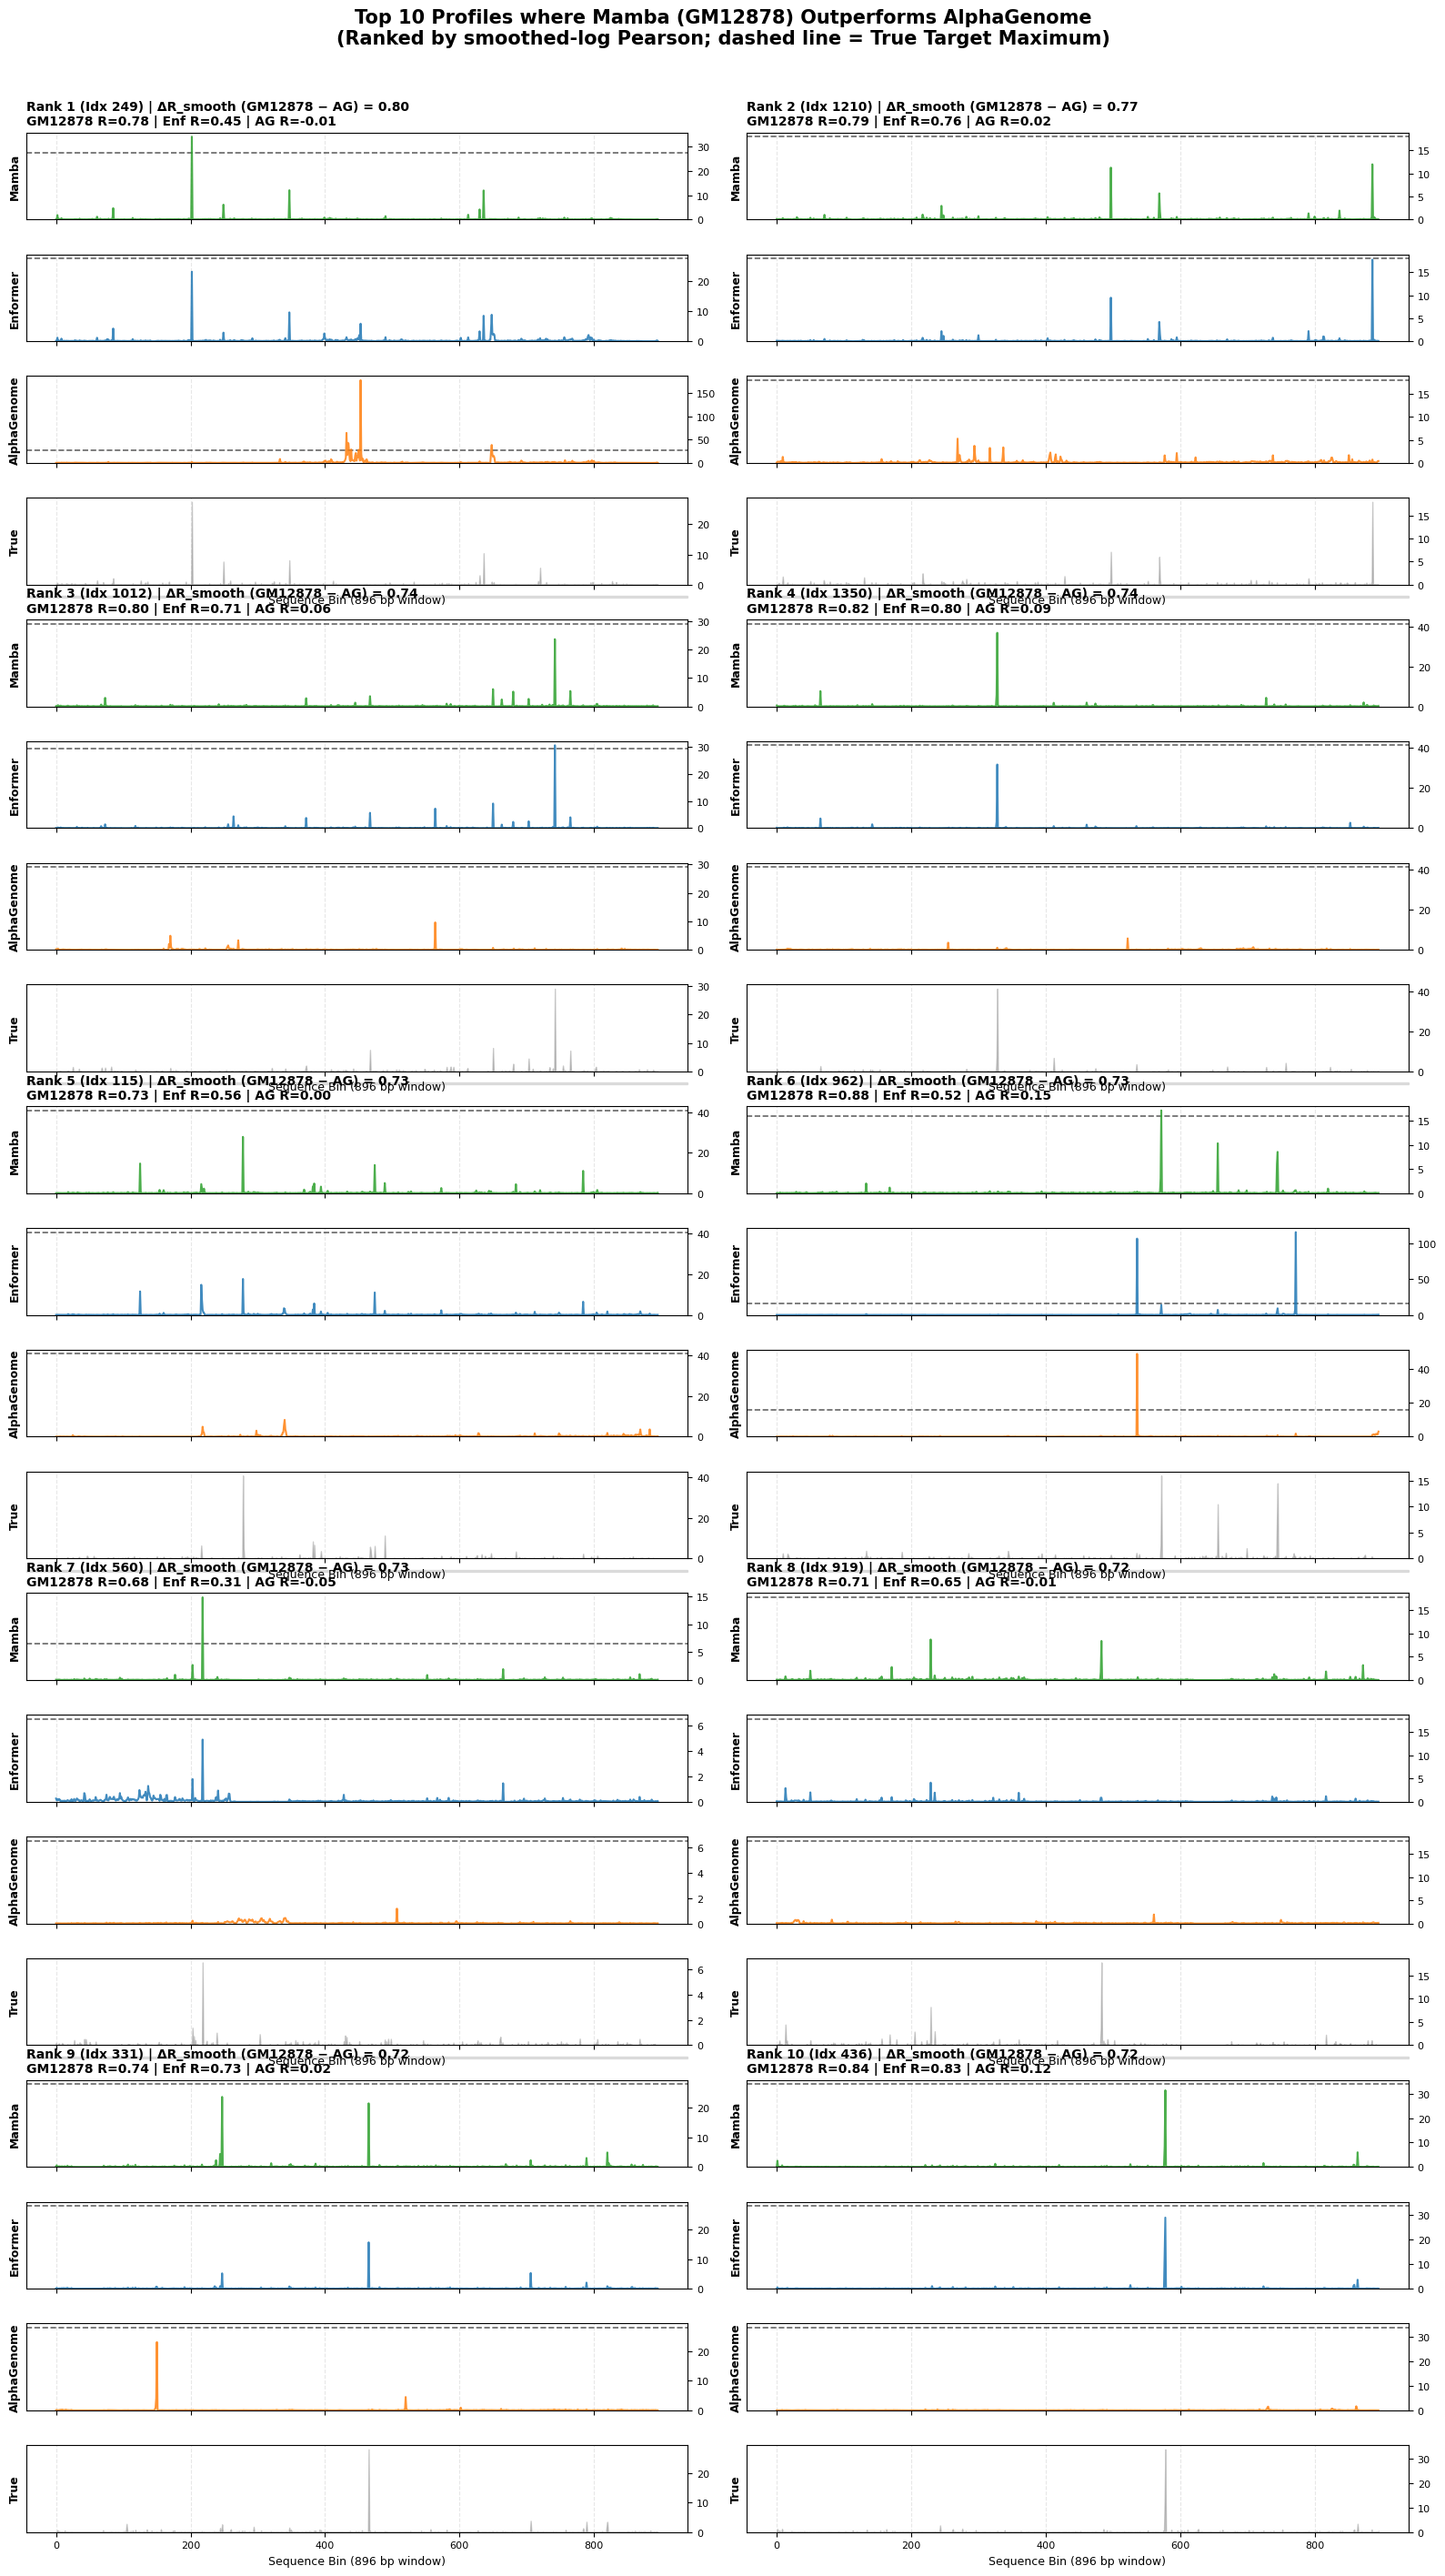

In [8]:
# Top 10 profiles where Mamba (GM12878) beats ALPHAGENOME the most (ranked by
# smoothed-log Pearson). Same 4-panel layout so all models stay comparable:
# Mamba (GM12878) / Enformer / AlphaGenome / True.
import numpy as np
import matplotlib.pyplot as plt

mamba_key = 'GM12878_no_mlm_predictions.npy'
enformer_key = 'enformer'
ag_key = 'alphagenome_cage_test_128bp.npy'

# ranking: where GM12878 beats AlphaGenome under the smoothed metric
delta_smooth = pearson_smooth_results[mamba_key] - pearson_smooth_results[ag_key]
delta_ranked = np.where(np.isnan(delta_smooth), -np.inf, delta_smooth)  # keep flat regions out of the top
top_10_indices = np.argsort(delta_ranked)[-10:][::-1]

N_SUB = 4  # Mamba, Enformer, AlphaGenome, True
fig, axes = plt.subplots(5 * N_SUB, 2, figsize=(16, 28), sharex='col')

for rank, idx in enumerate(top_10_indices):
    example_row = rank // 2
    example_col = rank % 2
    start_row = example_row * N_SUB

    ax_mamba    = axes[start_row,     example_col]
    ax_enformer = axes[start_row + 1, example_col]
    ax_ag       = axes[start_row + 2, example_col]
    ax_true     = axes[start_row + 3, example_col]

    track_mamba = preds[mamba_key][idx]
    track_enf   = preds[enformer_key][idx]
    track_ag    = preds[ag_key][idx]
    track_true  = t1[idx]

    # --- SCALE ANCHORING LOGIC ---
    true_max = np.max(track_true)

    # reference line at the true target maximum on every prediction plot
    ax_mamba.axhline(true_max, color='black', linestyle='--', alpha=0.6, linewidth=1.2, label='True Max')
    ax_enformer.axhline(true_max, color='black', linestyle='--', alpha=0.6, linewidth=1.2)
    ax_ag.axhline(true_max, color='black', linestyle='--', alpha=0.6, linewidth=1.2)

    # profiles (GM12878 green, Enformer blue, AlphaGenome orange, True gray)
    ax_mamba.plot(track_mamba, color='#2ca02c', alpha=0.85, label='Mamba (GM12878)')
    ax_enformer.plot(track_enf, color='#1f77b4', alpha=0.85, label='Enformer')
    ax_ag.plot(track_ag, color='#ff7f0e', alpha=0.85, label='AlphaGenome')
    ax_true.fill_between(range(len(track_true)), track_true, color='gray', alpha=0.4, label='True')

    # Set Y-limits to at least the true_max, or expand if a model overpredicts
    ax_mamba.set_ylim(0, max(np.max(track_mamba), true_max) * 1.05)
    ax_enformer.set_ylim(0, max(np.max(track_enf), true_max) * 1.05)
    ax_ag.set_ylim(0, max(np.max(track_ag), true_max) * 1.05)
    ax_true.set_ylim(0, true_max * 1.05)
    # -----------------------------

    title_text = (f"Rank {rank+1} (Idx {idx}) | ΔR_smooth (GM12878 − AG) = {delta_smooth[idx]:.2f}\n"
                  f"GM12878 R={pearson_smooth_results[mamba_key][idx]:.2f} | "
                  f"Enf R={pearson_smooth_results[enformer_key][idx]:.2f} | "
                  f"AG R={pearson_smooth_results[ag_key][idx]:.2f}")
    ax_mamba.set_title(title_text, fontsize=10, weight='bold', loc='left')

    for ax, label in zip([ax_mamba, ax_enformer, ax_ag, ax_true],
                         ['Mamba', 'Enformer', 'AlphaGenome', 'True']):
        ax.set_ylabel(label, fontsize=9, weight='bold')
        ax.tick_params(axis='both', labelsize=8)
        ax.grid(axis='x', linestyle='--', alpha=0.3)
        ax.yaxis.tick_right()

    ax_true.set_xlabel("Sequence Bin (896 bp window)", fontsize=9)

    # faint divider between example blocks
    if start_row + 3 < (5 * N_SUB - 1):
        rect = plt.Rectangle((0, -0.15), 1, 0.02, transform=ax_true.transAxes,
                             color='black', alpha=0.1, clip_on=False)
        ax_true.add_patch(rect)

plt.suptitle("Top 10 Profiles where Mamba (GM12878) Outperforms AlphaGenome\n"
             "(Ranked by smoothed-log Pearson; dashed line = True Target Maximum)",
             fontsize=15, weight='bold', y=1.01)
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.show()


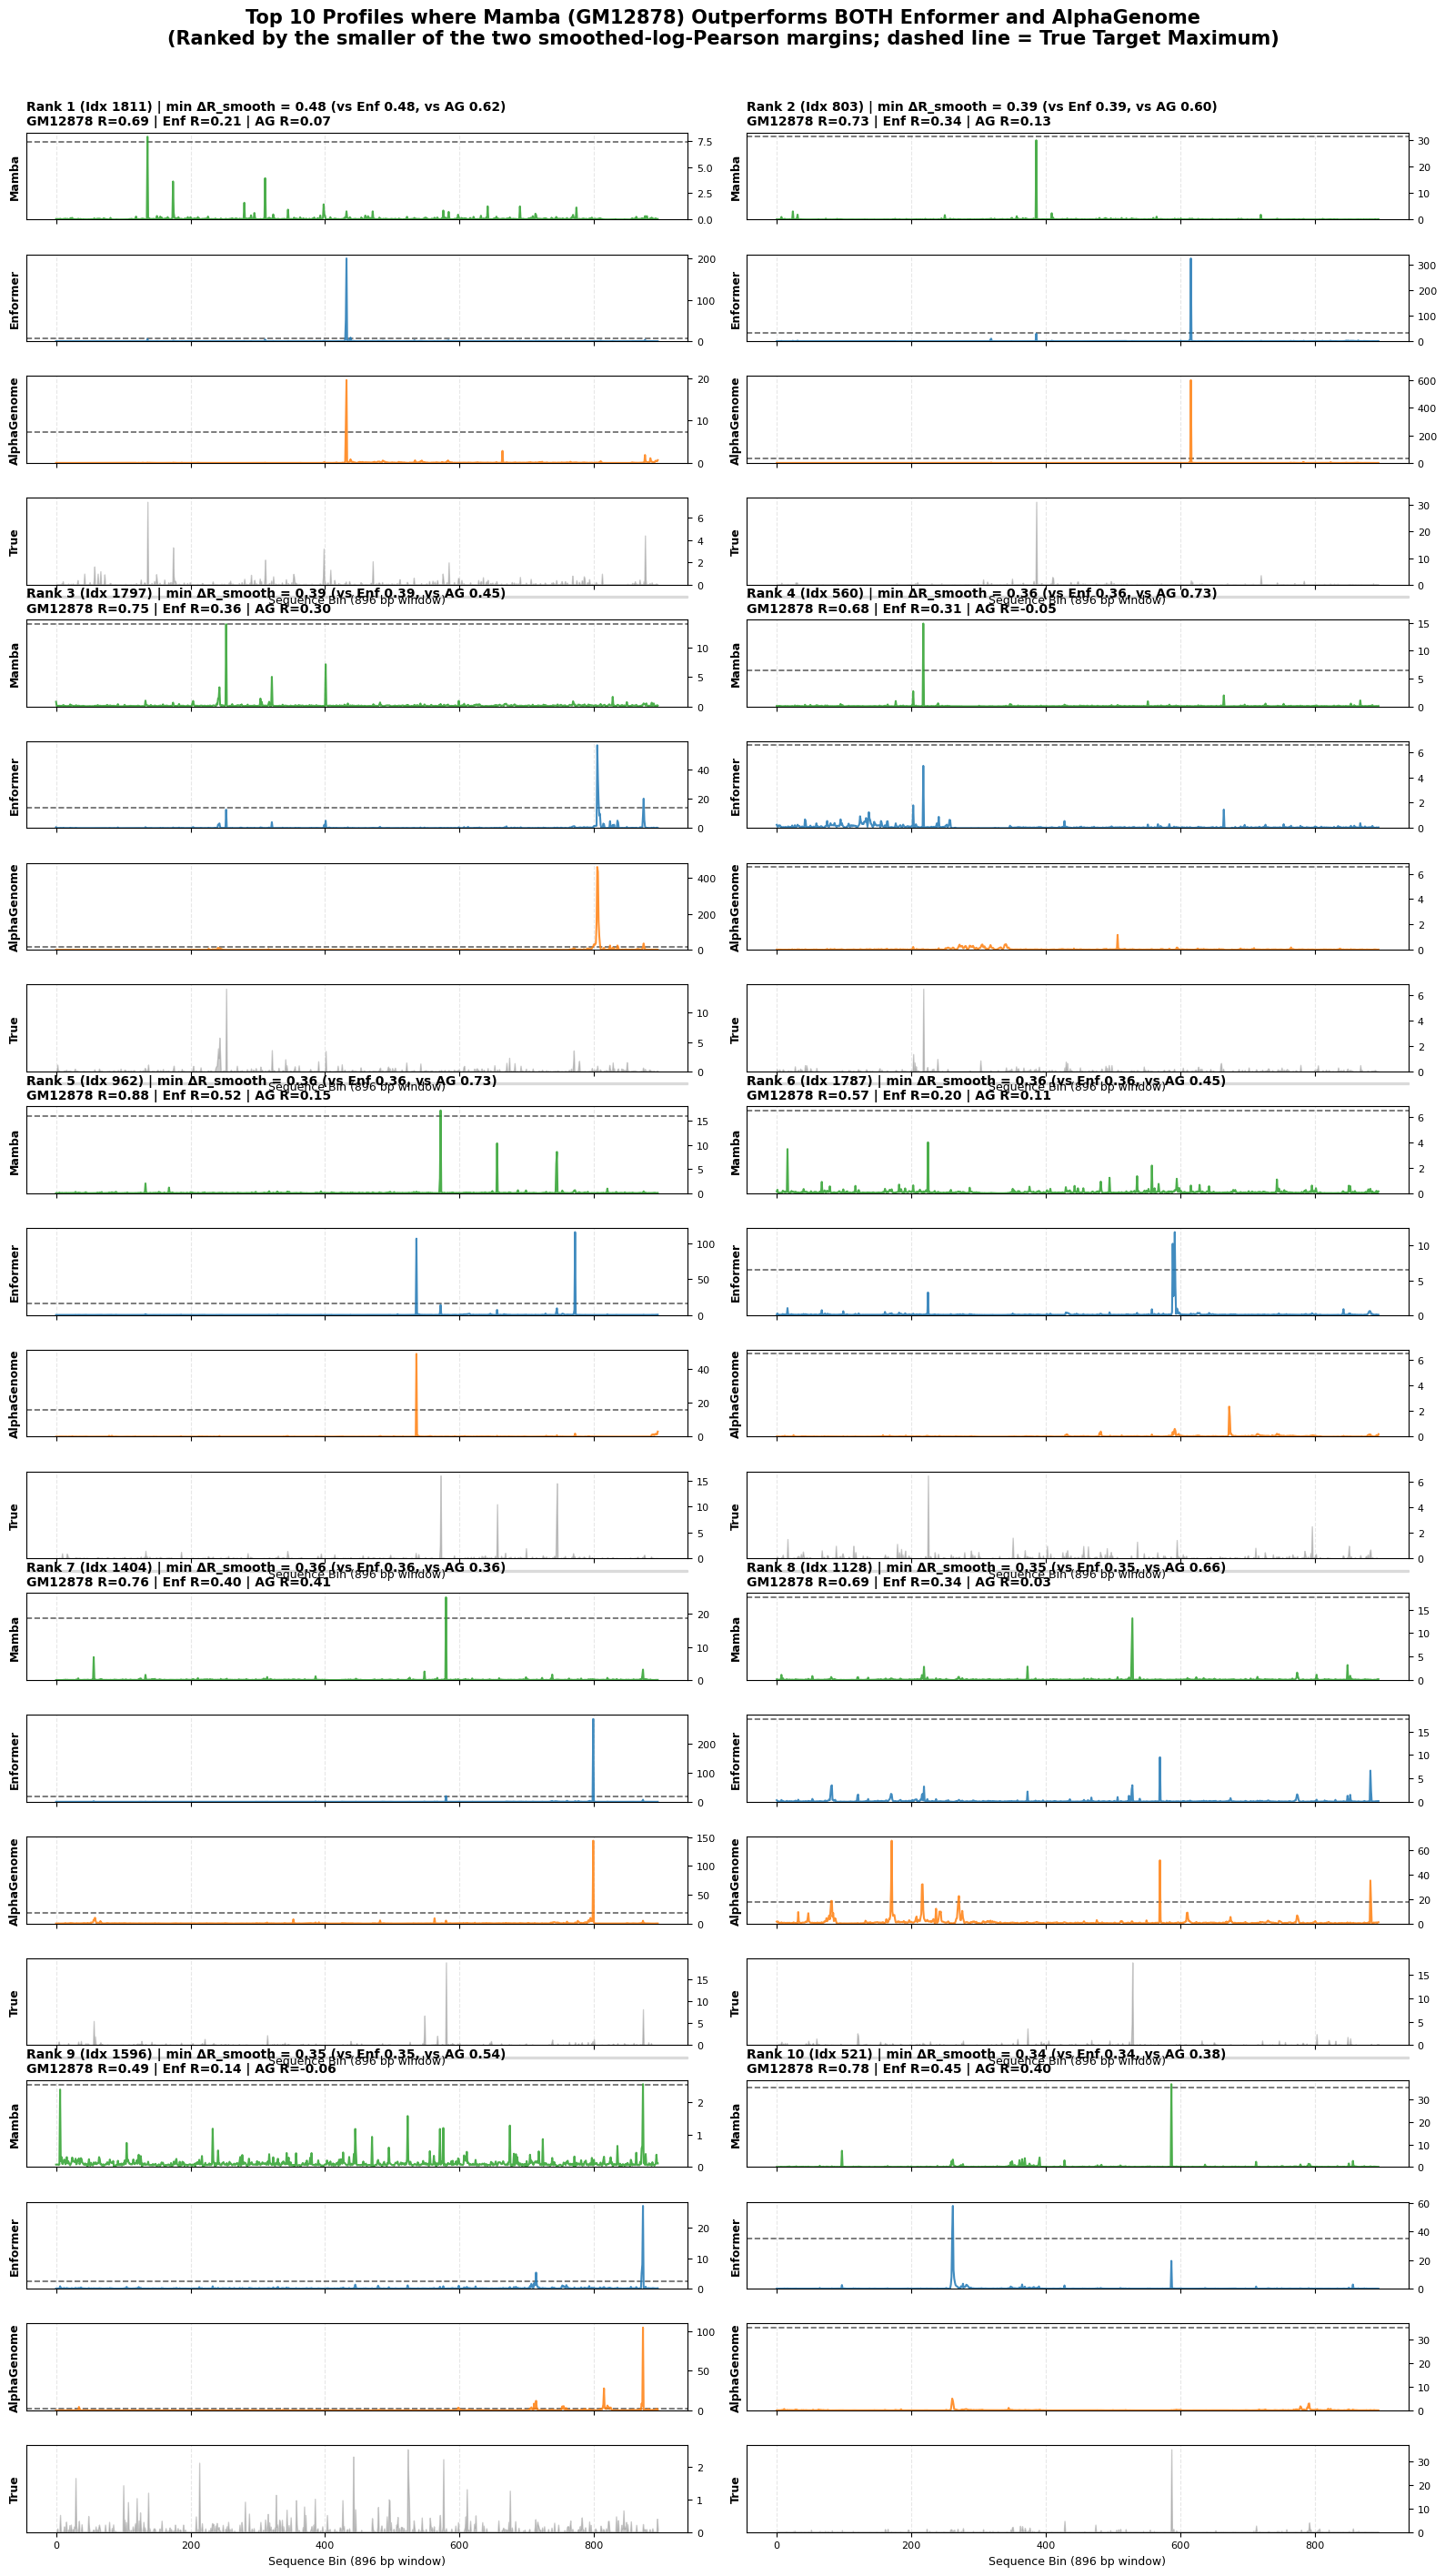

In [9]:
# Top 10 profiles where Mamba (GM12878) beats BOTH Enformer AND AlphaGenome the most.
# Ranked by the MINIMUM of the two smoothed-log-Pearson margins, so a region only
# scores high if GM12878 clears both baselines by a solid margin (not just one).
# Same 4-panel layout: Mamba (GM12878) / Enformer / AlphaGenome / True.
import numpy as np
import matplotlib.pyplot as plt

mamba_key = 'GM12878_no_mlm_predictions.npy'
enformer_key = 'enformer'
ag_key = 'alphagenome_cage_test_128bp.npy'

delta_enf = pearson_smooth_results[mamba_key] - pearson_smooth_results[enformer_key]
delta_ag  = pearson_smooth_results[mamba_key] - pearson_smooth_results[ag_key]
# "beats both" = worst of the two margins is still large
delta_both = np.minimum(delta_enf, delta_ag)
delta_ranked = np.where(np.isnan(delta_both), -np.inf, delta_both)  # keep flat regions out of the top
top_10_indices = np.argsort(delta_ranked)[-10:][::-1]

N_SUB = 4  # Mamba, Enformer, AlphaGenome, True
fig, axes = plt.subplots(5 * N_SUB, 2, figsize=(16, 28), sharex='col')

for rank, idx in enumerate(top_10_indices):
    example_row = rank // 2
    example_col = rank % 2
    start_row = example_row * N_SUB

    ax_mamba    = axes[start_row,     example_col]
    ax_enformer = axes[start_row + 1, example_col]
    ax_ag       = axes[start_row + 2, example_col]
    ax_true     = axes[start_row + 3, example_col]

    track_mamba = preds[mamba_key][idx]
    track_enf   = preds[enformer_key][idx]
    track_ag    = preds[ag_key][idx]
    track_true  = t1[idx]

    # --- SCALE ANCHORING LOGIC ---
    true_max = np.max(track_true)

    # reference line at the true target maximum on every prediction plot
    ax_mamba.axhline(true_max, color='black', linestyle='--', alpha=0.6, linewidth=1.2, label='True Max')
    ax_enformer.axhline(true_max, color='black', linestyle='--', alpha=0.6, linewidth=1.2)
    ax_ag.axhline(true_max, color='black', linestyle='--', alpha=0.6, linewidth=1.2)

    # profiles (GM12878 green, Enformer blue, AlphaGenome orange, True gray)
    ax_mamba.plot(track_mamba, color='#2ca02c', alpha=0.85, label='Mamba (GM12878)')
    ax_enformer.plot(track_enf, color='#1f77b4', alpha=0.85, label='Enformer')
    ax_ag.plot(track_ag, color='#ff7f0e', alpha=0.85, label='AlphaGenome')
    ax_true.fill_between(range(len(track_true)), track_true, color='gray', alpha=0.4, label='True')

    # Set Y-limits to at least the true_max, or expand if a model overpredicts
    ax_mamba.set_ylim(0, max(np.max(track_mamba), true_max) * 1.05)
    ax_enformer.set_ylim(0, max(np.max(track_enf), true_max) * 1.05)
    ax_ag.set_ylim(0, max(np.max(track_ag), true_max) * 1.05)
    ax_true.set_ylim(0, true_max * 1.05)
    # -----------------------------

    title_text = (f"Rank {rank+1} (Idx {idx}) | min ΔR_smooth = {delta_both[idx]:.2f} "
                  f"(vs Enf {delta_enf[idx]:.2f}, vs AG {delta_ag[idx]:.2f})\n"
                  f"GM12878 R={pearson_smooth_results[mamba_key][idx]:.2f} | "
                  f"Enf R={pearson_smooth_results[enformer_key][idx]:.2f} | "
                  f"AG R={pearson_smooth_results[ag_key][idx]:.2f}")
    ax_mamba.set_title(title_text, fontsize=10, weight='bold', loc='left')

    for ax, label in zip([ax_mamba, ax_enformer, ax_ag, ax_true],
                         ['Mamba', 'Enformer', 'AlphaGenome', 'True']):
        ax.set_ylabel(label, fontsize=9, weight='bold')
        ax.tick_params(axis='both', labelsize=8)
        ax.grid(axis='x', linestyle='--', alpha=0.3)
        ax.yaxis.tick_right()

    ax_true.set_xlabel("Sequence Bin (896 bp window)", fontsize=9)

    # faint divider between example blocks
    if start_row + 3 < (5 * N_SUB - 1):
        rect = plt.Rectangle((0, -0.15), 1, 0.02, transform=ax_true.transAxes,
                             color='black', alpha=0.1, clip_on=False)
        ax_true.add_patch(rect)

plt.suptitle("Top 10 Profiles where Mamba (GM12878) Outperforms BOTH Enformer and AlphaGenome\n"
             "(Ranked by the smaller of the two smoothed-log-Pearson margins; dashed line = True Target Maximum)",
             fontsize=15, weight='bold', y=1.01)
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.show()


# Are Mamba's wins concentrated in cell-type-specific regions?

Rank every test region by how much the GM12878 model beats **both** baselines (`margin = min(ΔR_smooth vs Enformer, ΔR_smooth vs AlphaGenome)`), then ask whether **GM12878-cell-type-specific** regions are enriched at the top of that ranking.

Specificity is the robust directed score from before: `specificity = log1p(GM12878) − log1p(P90 of the other 637 cell types)`, per region summed over the window.

Three complementary tests:
1. **Spearman(margin, specificity)** — continuous monotonic association across expressed regions.
2. **Partial Spearman controlling for GM12878 expression level** — removes the confound that highly-expressed regions may be both easier to predict *and* appear more specific.
3. **Rank enrichment** — Mann–Whitney (specificity of regions that beat both vs the rest) with AUC = probability of superiority, plus a **GSEA-style running-enrichment** of the top-specificity-quartile regions along the margin ranking, with a permutation p-value.

regions used: 968 (expressed & defined margin)

Spearman(margin, specificity): rho=-0.127, p=7.36e-05
  Spearman(margin, gm_log)      : rho=-0.115
  Spearman(specificity, gm_log) : rho=0.392
  partial Spearman | gm_log     : rho=-0.084, p=8.81e-03

Winners (beat both): 190 | others: 778
Mann-Whitney (winners' specificity > others'): p=9.96e-01
  AUC / prob. of superiority = 0.438   (0.5 = no enrichment)
  median specificity  winners=0.419  others=0.493

GSEA-style enrichment of specific regions at the top of the margin ranking:
  ES=-0.443, permutation p=0.010


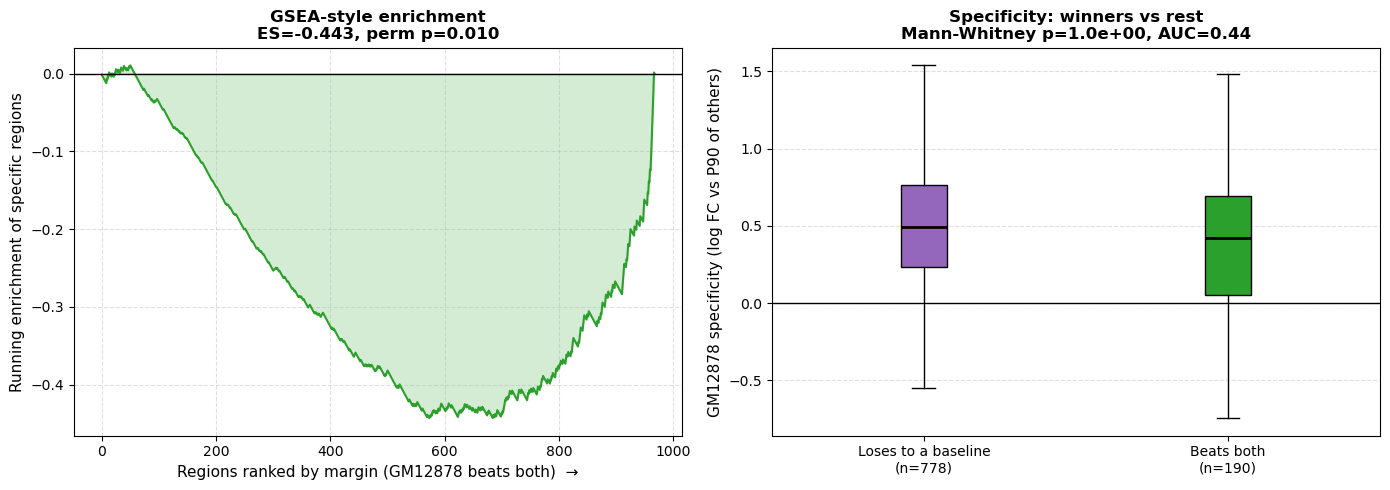

In [10]:
# Are Mamba's wins concentrated in cell-type-specific regions?
# Rank every region by how much GM12878 beats BOTH baselines, then test whether
# GM12878-cell-type-specific regions are enriched at the top of that ranking.
import numpy as np
import matplotlib.pyplot as plt
import zarr
from scipy.stats import spearmanr, mannwhitneyu, rankdata

mamba_key = 'GM12878_no_mlm_predictions.npy'
enformer_key = 'enformer'
ag_key = 'alphagenome_cage_test_128bp.npy'

# --- 1. per-region "beats both" margin (same metric as the vs-both plot) ---
delta_enf = pearson_smooth_results[mamba_key] - pearson_smooth_results[enformer_key]
delta_ag  = pearson_smooth_results[mamba_key] - pearson_smooth_results[ag_key]
margin = np.minimum(delta_enf, delta_ag)   # high -> beats both by a solid margin

# --- 2. robust, directed GM12878 cell-type-specificity score (recomputed here
#        so this cell stands alone after ag-setup) ---
labels = zarr.open('/data1/lesliec/sarthak/data/enformer/data/labels.zarr', mode='r')
labels_cage = labels['test'][:, :, 4675:]                 # (1937, 896, 638) CAGE tracks
labels_cage_sum = np.sum(labels_cage, axis=1)             # per-region summed signal
target_idx = 5110 - 4675                                  # GM12878 CAGE track within CAGE block

log_sum = np.log1p(labels_cage_sum)
gm_log  = log_sum[:, target_idx]
bg_log  = np.delete(log_sum, target_idx, axis=1)
BG_PCTL = 90
bg_hi = np.percentile(bg_log, BG_PCTL, axis=1)
specificity = gm_log - bg_hi                              # >0 GM-specific, ~0 ubiquitous, <0 silent

# --- 3. keep regions with a defined margin AND actually expressed in GM12878 ---
#        (specificity is only meaningful where GM12878 has signal)
expressed = gm_log > np.median(gm_log[gm_log > 0])
valid = ~np.isnan(margin) & expressed
m, s, g = margin[valid], specificity[valid], gm_log[valid]
print(f"regions used: {valid.sum()} (expressed & defined margin)")

# --- 4. continuous association: Spearman(margin, specificity) ---
rho, p = spearmanr(m, s)
print(f"\nSpearman(margin, specificity): rho={rho:.3f}, p={p:.2e}")

# confound check: does expression magnitude drive both?
print(f"  Spearman(margin, gm_log)      : rho={spearmanr(m, g)[0]:.3f}")
print(f"  Spearman(specificity, gm_log) : rho={spearmanr(s, g)[0]:.3f}")

# partial Spearman(margin, specificity | gm_log): correlate the rank-residuals
def _resid_ranks(y, x):
    ry, rx = rankdata(y), rankdata(x)
    b = np.polyfit(rx, ry, 1)          # linear fit on ranks
    return ry - np.polyval(b, rx)      # residual after removing x's rank-effect
rho_partial, p_partial = spearmanr(_resid_ranks(m, g), _resid_ranks(s, g))
print(f"  partial Spearman | gm_log     : rho={rho_partial:.3f}, p={p_partial:.2e}")

# --- 5. rank enrichment: are "winners" (beat both) more specific than the rest? ---
winners = m > 0
U, p_mw = mannwhitneyu(s[winners], s[~winners], alternative='greater')
auc = U / (winners.sum() * (~winners).sum())   # P(spec_winner > spec_other); 0.5 = no enrichment
print(f"\nWinners (beat both): {winners.sum()} | others: {(~winners).sum()}")
print(f"Mann-Whitney (winners' specificity > others'): p={p_mw:.2e}")
print(f"  AUC / prob. of superiority = {auc:.3f}   (0.5 = no enrichment)")
print(f"  median specificity  winners={np.median(s[winners]):.3f}  others={np.median(s[~winners]):.3f}")

# --- 6. GSEA-style running enrichment: rank ALL by margin, membership = top-specificity set ---
order = np.argsort(-m)                        # regions sorted by margin, best first
is_specific = s > np.quantile(s, 0.75)        # "cell-type-specific" set = top specificity quartile
hits = is_specific[order].astype(float)
w = np.abs(m[order])                          # weight by margin magnitude (classic GSEA weighting)
p_hit  = np.cumsum(hits * w) / np.sum(hits * w)
p_miss = np.cumsum(1 - hits) / np.sum(1 - hits)
running = p_hit - p_miss
es = running[np.argmax(np.abs(running))]      # enrichment score = max deviation from 0

rng = np.random.default_rng(0)
n_perm = 2000
null_es = np.empty(n_perm)
for i in range(n_perm):
    perm = rng.permutation(hits)
    ph = np.cumsum(perm * w) / np.sum(perm * w)
    pm = np.cumsum(1 - perm) / np.sum(1 - perm)
    r = ph - pm
    null_es[i] = r[np.argmax(np.abs(r))]
p_es = (np.sum(np.abs(null_es) >= np.abs(es)) + 1) / (n_perm + 1)
print(f"\nGSEA-style enrichment of specific regions at the top of the margin ranking:")
print(f"  ES={es:.3f}, permutation p={p_es:.3f}")

# --- plots ---
fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5))

axA.plot(running, color='#2ca02c', lw=1.5)
axA.axhline(0, color='black', lw=1)
axA.fill_between(range(len(running)), running, 0, color='#2ca02c', alpha=0.2)
axA.set_xlabel("Regions ranked by margin (GM12878 beats both)  →", fontsize=11)
axA.set_ylabel("Running enrichment of specific regions", fontsize=11)
axA.set_title(f"GSEA-style enrichment\nES={es:.3f}, perm p={p_es:.3f}", fontsize=12, weight='bold')
axA.grid(linestyle='--', alpha=0.4)

bp = axB.boxplot([s[~winners], s[winners]], showfliers=False, patch_artist=True,
                 labels=[f"Loses to a baseline\n(n={(~winners).sum()})",
                         f"Beats both\n(n={winners.sum()})"],
                 medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], ['#9467bd', '#2ca02c']):
    patch.set_facecolor(c)
axB.axhline(0, color='black', lw=1)
axB.set_ylabel("GM12878 specificity (log FC vs P90 of others)", fontsize=11)
axB.set_title(f"Specificity: winners vs rest\nMann-Whitney p={p_mw:.1e}, AUC={auc:.2f}",
              fontsize=12, weight='bold')
axB.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


regions used: 968
Mamba (GM12878) : Spearman(spec, R)=+0.051 | mean R  low-spec Q1=0.706  high-spec Q4=0.715
Enformer        : Spearman(spec, R)=+0.023 | mean R  low-spec Q1=0.741  high-spec Q4=0.734
AlphaGenome     : Spearman(spec, R)=+0.261 | mean R  low-spec Q1=0.653  high-spec Q4=0.789


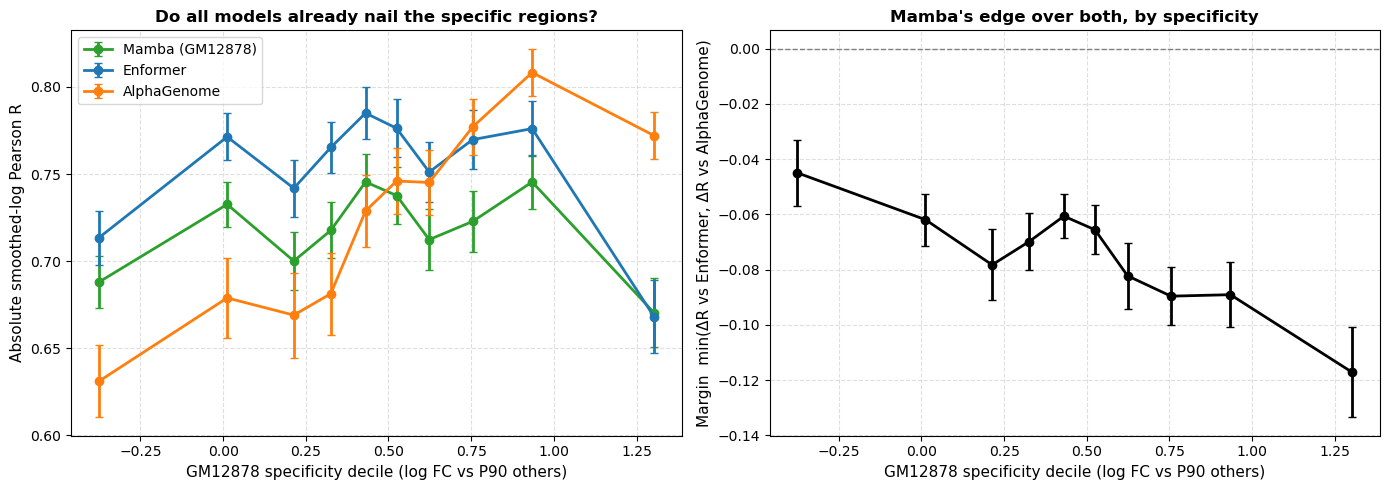

In [11]:
# Ceiling check: is Mamba's small edge on specific regions because everyone already
# nails them? Plot each model's ABSOLUTE smoothed-log Pearson across specificity
# deciles (not the margin). If all models are already high-R in the specific bins,
# the weak/negative margin trend is headroom, not a Mamba weakness.
#
# Requires the enrichment cell above (uses `specificity` and `margin`).
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# three models that define the "beats both" margin
plot_models = [
    ('GM12878_no_mlm_predictions.npy', 'Mamba (GM12878)', '#2ca02c'),
    ('enformer',                       'Enformer',        '#1f77b4'),
    ('alphagenome_cage_test_128bp.npy','AlphaGenome',     '#ff7f0e'),
]

# same subset as the enrichment analysis: expressed & margin defined
valid = ~np.isnan(margin) & (gm_log > np.median(gm_log[gm_log > 0]))
s = specificity[valid]
mgn = margin[valid]
print(f"regions used: {valid.sum()}")

# specificity deciles
nbins = 10
edges = np.quantile(s, np.linspace(0, 1, nbins + 1))
edges[-1] += 1e-9
which = np.digitize(s, edges) - 1
centers = np.array([np.median(s[which == b]) for b in range(nbins)])

fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5))

# --- left: each model's absolute smoothed-R across specificity deciles ---
for key, lab, col in plot_models:
    R = pearson_smooth_results[key][valid]
    means = np.array([np.nanmean(R[which == b]) for b in range(nbins)])
    sems  = np.array([np.nanstd(R[which == b]) / np.sqrt(np.sum(which == b)) for b in range(nbins)])
    axA.errorbar(centers, means, yerr=sems, marker='o', lw=2, capsize=3, color=col, label=lab)
    # quantify: does this model's absolute R rise with specificity?
    rho_r = spearmanr(s, R, nan_policy='omit')[0]
    lo = np.nanmean(R[s <= np.quantile(s, 0.25)])
    hi = np.nanmean(R[s >= np.quantile(s, 0.75)])
    print(f"{lab:16s}: Spearman(spec, R)={rho_r:+.3f} | mean R  low-spec Q1={lo:.3f}  high-spec Q4={hi:.3f}")

axA.set_xlabel("GM12878 specificity decile (log FC vs P90 others)", fontsize=11)
axA.set_ylabel("Absolute smoothed-log Pearson R", fontsize=11)
axA.set_title("Do all models already nail the specific regions?", fontsize=12, weight='bold')
axA.legend(fontsize=10)
axA.grid(linestyle='--', alpha=0.4)

# --- right: the margin (GM12878 beats both) across the same deciles ---
mgn_means = np.array([np.mean(mgn[which == b]) for b in range(nbins)])
mgn_sems  = np.array([np.std(mgn[which == b]) / np.sqrt(np.sum(which == b)) for b in range(nbins)])
axB.errorbar(centers, mgn_means, yerr=mgn_sems, marker='o', lw=2, capsize=3, color='black')
axB.axhline(0, color='gray', lw=1, ls='--')
axB.set_xlabel("GM12878 specificity decile (log FC vs P90 others)", fontsize=11)
axB.set_ylabel("Margin  min(ΔR vs Enformer, ΔR vs AlphaGenome)", fontsize=11)
axB.set_title("Mamba's edge over both, by specificity", fontsize=12, weight='bold')
axB.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


regions used: 968
Mamba (8 immune cell types) : Spearman(spec, R)=+0.046 | mean R  low-spec Q1=0.726  high-spec Q4=0.732
Enformer                    : Spearman(spec, R)=+0.023 | mean R  low-spec Q1=0.741  high-spec Q4=0.734
AlphaGenome                 : Spearman(spec, R)=+0.261 | mean R  low-spec Q1=0.653  high-spec Q4=0.789


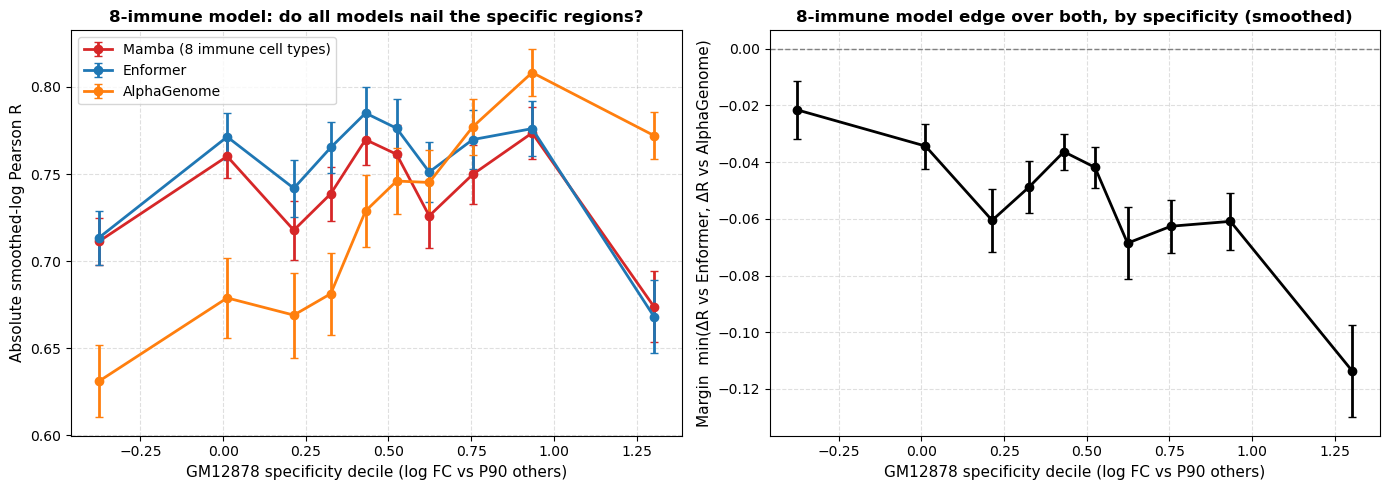

In [12]:
# Ceiling check for the 8-immune-cell-types model (smoothed-log Pearson).
# Same diagnostic as the GM12878 ceiling plot, but the "Mamba" model is now the
# immune multi-cell-type model. Reuses `specificity` and `gm_log` from the
# enrichment cell above (both are model-independent, GM12878-specificity axis).
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

mamba_key = 'immune_CAGE_predictions.npy'
enformer_key = 'enformer'
ag_key = 'alphagenome_cage_test_128bp.npy'

# margin: how much the immune model beats BOTH baselines (smoothed metric)
delta_enf = pearson_smooth_results[mamba_key] - pearson_smooth_results[enformer_key]
delta_ag  = pearson_smooth_results[mamba_key] - pearson_smooth_results[ag_key]
margin = np.minimum(delta_enf, delta_ag)

plot_models = [
    (mamba_key,    'Mamba (8 immune cell types)', '#d62728'),
    (enformer_key, 'Enformer',                    '#1f77b4'),
    (ag_key,       'AlphaGenome',                 '#ff7f0e'),
]

valid = ~np.isnan(margin) & (gm_log > np.median(gm_log[gm_log > 0]))
s = specificity[valid]
mgn = margin[valid]
print(f"regions used: {valid.sum()}")

nbins = 10
edges = np.quantile(s, np.linspace(0, 1, nbins + 1)); edges[-1] += 1e-9
which = np.digitize(s, edges) - 1
centers = np.array([np.median(s[which == b]) for b in range(nbins)])

fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5))

for key, lab, col in plot_models:
    R = pearson_smooth_results[key][valid]
    means = np.array([np.nanmean(R[which == b]) for b in range(nbins)])
    sems  = np.array([np.nanstd(R[which == b]) / np.sqrt(np.sum(which == b)) for b in range(nbins)])
    axA.errorbar(centers, means, yerr=sems, marker='o', lw=2, capsize=3, color=col, label=lab)
    rho_r = spearmanr(s, R, nan_policy='omit')[0]
    lo = np.nanmean(R[s <= np.quantile(s, 0.25)]); hi = np.nanmean(R[s >= np.quantile(s, 0.75)])
    print(f"{lab:28s}: Spearman(spec, R)={rho_r:+.3f} | mean R  low-spec Q1={lo:.3f}  high-spec Q4={hi:.3f}")

axA.set_xlabel("GM12878 specificity decile (log FC vs P90 others)", fontsize=11)
axA.set_ylabel("Absolute smoothed-log Pearson R", fontsize=11)
axA.set_title("8-immune model: do all models nail the specific regions?", fontsize=12, weight='bold')
axA.legend(fontsize=10); axA.grid(linestyle='--', alpha=0.4)

mgn_means = np.array([np.mean(mgn[which == b]) for b in range(nbins)])
mgn_sems  = np.array([np.std(mgn[which == b]) / np.sqrt(np.sum(which == b)) for b in range(nbins)])
axB.errorbar(centers, mgn_means, yerr=mgn_sems, marker='o', lw=2, capsize=3, color='black')
axB.axhline(0, color='gray', lw=1, ls='--')
axB.set_xlabel("GM12878 specificity decile (log FC vs P90 others)", fontsize=11)
axB.set_ylabel("Margin  min(ΔR vs Enformer, ΔR vs AlphaGenome)", fontsize=11)
axB.set_title("8-immune model edge over both, by specificity (smoothed)", fontsize=12, weight='bold')
axB.grid(linestyle='--', alpha=0.4)

plt.tight_layout(); plt.show()


immune_CAGE_predictions.npy: mean plain Pearson = 0.626
enformer: mean plain Pearson = 0.626
alphagenome_cage_test_128bp.npy: mean plain Pearson = 0.428
regions used: 968
Mamba (8 immune cell types) : Spearman(spec, R)=-0.096 | mean R  low-spec Q1=0.713  high-spec Q4=0.662
Enformer                    : Spearman(spec, R)=-0.081 | mean R  low-spec Q1=0.720  high-spec Q4=0.681
AlphaGenome                 : Spearman(spec, R)=+0.072 | mean R  low-spec Q1=0.632  high-spec Q4=0.752


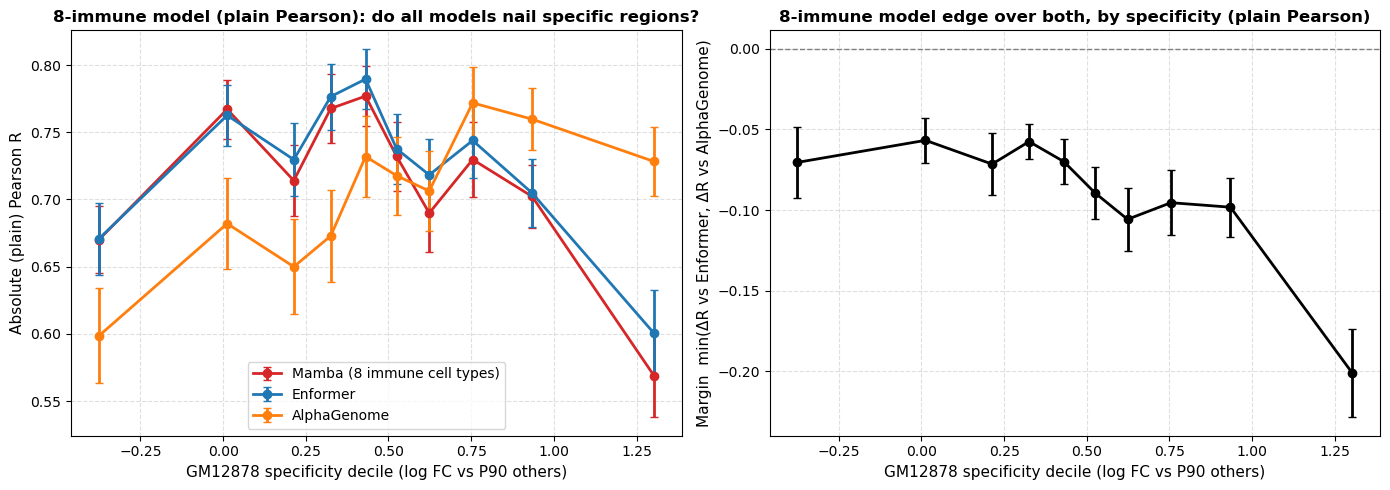

In [13]:
# Same 8-immune-model ceiling check but with PLAIN per-bin Pearson (not smoothed-log).
# Computes ordinary Pearson per region for the three relevant models, then repeats the
# specificity-decile diagnostic. Reuses `specificity` and `gm_log` from the enrichment cell.
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

mamba_key = 'immune_CAGE_predictions.npy'
enformer_key = 'enformer'
ag_key = 'alphagenome_cage_test_128bp.npy'

def per_region_pearson(pred, true):
    out = np.empty(pred.shape[0])
    for i in range(pred.shape[0]):
        if np.std(pred[i]) < 1e-8 or np.std(true[i]) < 1e-8:   # flat profile -> undefined
            out[i] = np.nan
        else:
            out[i] = pearsonr(pred[i], true[i])[0]
    return out

# ordinary (non-smoothed) Pearson per region for the three models we plot
pearson_norm = {}
for key in [mamba_key, enformer_key, ag_key]:
    pearson_norm[key] = per_region_pearson(np.asarray(preds[key]), t1)
    print(f"{key}: mean plain Pearson = {np.nanmean(pearson_norm[key]):.3f}")

delta_enf = pearson_norm[mamba_key] - pearson_norm[enformer_key]
delta_ag  = pearson_norm[mamba_key] - pearson_norm[ag_key]
margin = np.minimum(delta_enf, delta_ag)

plot_models = [
    (mamba_key,    'Mamba (8 immune cell types)', '#d62728'),
    (enformer_key, 'Enformer',                    '#1f77b4'),
    (ag_key,       'AlphaGenome',                 '#ff7f0e'),
]

valid = ~np.isnan(margin) & (gm_log > np.median(gm_log[gm_log > 0]))
s = specificity[valid]; mgn = margin[valid]
print(f"regions used: {valid.sum()}")

nbins = 10
edges = np.quantile(s, np.linspace(0, 1, nbins + 1)); edges[-1] += 1e-9
which = np.digitize(s, edges) - 1
centers = np.array([np.median(s[which == b]) for b in range(nbins)])

fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5))

for key, lab, col in plot_models:
    R = pearson_norm[key][valid]
    means = np.array([np.nanmean(R[which == b]) for b in range(nbins)])
    sems  = np.array([np.nanstd(R[which == b]) / np.sqrt(np.sum(which == b)) for b in range(nbins)])
    axA.errorbar(centers, means, yerr=sems, marker='o', lw=2, capsize=3, color=col, label=lab)
    rho_r = spearmanr(s, R, nan_policy='omit')[0]
    lo = np.nanmean(R[s <= np.quantile(s, 0.25)]); hi = np.nanmean(R[s >= np.quantile(s, 0.75)])
    print(f"{lab:28s}: Spearman(spec, R)={rho_r:+.3f} | mean R  low-spec Q1={lo:.3f}  high-spec Q4={hi:.3f}")

axA.set_xlabel("GM12878 specificity decile (log FC vs P90 others)", fontsize=11)
axA.set_ylabel("Absolute (plain) Pearson R", fontsize=11)
axA.set_title("8-immune model (plain Pearson): do all models nail specific regions?", fontsize=12, weight='bold')
axA.legend(fontsize=10); axA.grid(linestyle='--', alpha=0.4)

mgn_means = np.array([np.mean(mgn[which == b]) for b in range(nbins)])
mgn_sems  = np.array([np.std(mgn[which == b]) / np.sqrt(np.sum(which == b)) for b in range(nbins)])
axB.errorbar(centers, mgn_means, yerr=mgn_sems, marker='o', lw=2, capsize=3, color='black')
axB.axhline(0, color='gray', lw=1, ls='--')
axB.set_xlabel("GM12878 specificity decile (log FC vs P90 others)", fontsize=11)
axB.set_ylabel("Margin  min(ΔR vs Enformer, ΔR vs AlphaGenome)", fontsize=11)
axB.set_title("8-immune model edge over both, by specificity (plain Pearson)", fontsize=12, weight='bold')
axB.grid(linestyle='--', alpha=0.4)

plt.tight_layout(); plt.show()


In [14]:
#wait this implies that we are actually better in the least cell tyep specific regions. Maybe because held out and CTS things harder to learn?


## Control: is AlphaGenome just better on high-peak regions?

Specific regions tend to be high-signal (`Spearman(specificity, expression) ≈ 0.39`), and tall sharp peaks are easy to predict for *any* model — so AlphaGenome's R rising with specificity might be a **peak-height** effect rather than cell-type-specific skill. Two checks:
1. **Partial Spearman(specificity, R | peak height)** per model — does the specificity→accuracy link survive removing peak height? If the partial rho collapses toward 0, it was peak height.
2. **AlphaGenome R vs specificity within peak-height bands** — if the slope flattens inside each band, the apparent specificity trend was driven by tall peaks, not specificity itself.

regions used: 968
Spearman(specificity, peak height) = 0.229  (if high, specificity and peak height are entangled)

model             raw rho(spec,R)   rho(peak,R)   partial rho|peak          p
Mamba (GM12878)             0.051         0.551             -0.089    5.4e-03
Enformer                    0.023         0.561             -0.116    3.0e-04
AlphaGenome                 0.261         0.698              0.143    8.3e-06


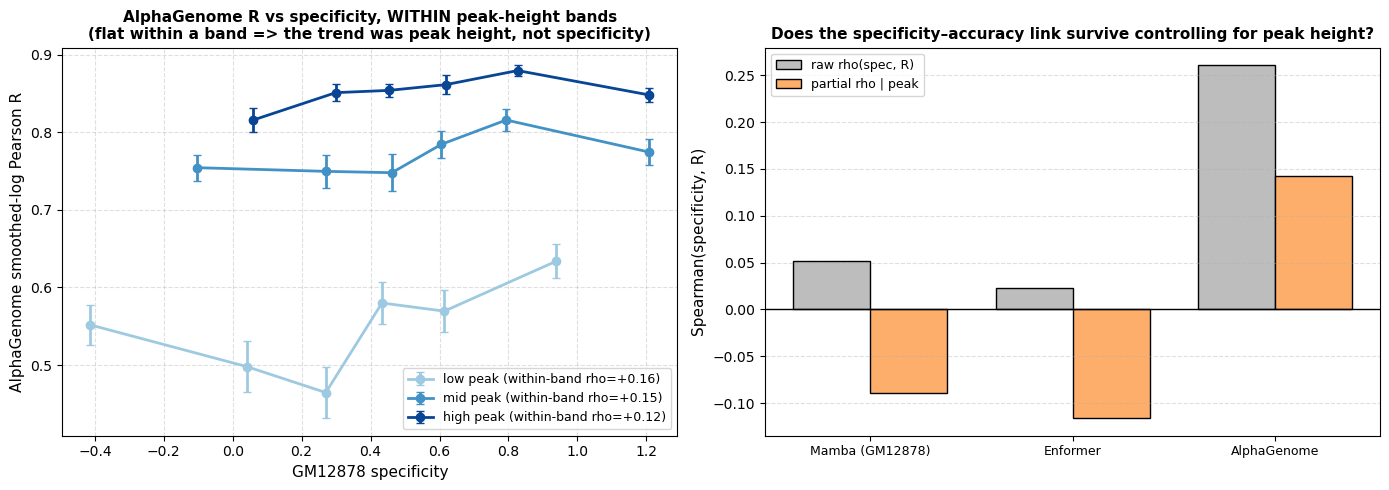

In [15]:
# Control: is AlphaGenome's R-vs-specificity slope just a HIGH-PEAK effect?
# Specific regions tend to be high-signal, and tall sharp peaks are easy for any model,
# so "better on specific regions" could really be "better on tall peaks". Two checks:
#   (1) partial Spearman(specificity, R | peak height) per model -- does the link survive
#       removing peak height?
#   (2) AlphaGenome R vs specificity WITHIN expression bands -- if flat inside each band,
#       the trend was peak height, not cell-type specificity.
# Uses smoothed-log Pearson; reuses `specificity` and `gm_log` from the enrichment cell.
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, rankdata

models = [
    ('GM12878_no_mlm_predictions.npy', 'Mamba (GM12878)', '#2ca02c'),
    ('enformer',                       'Enformer',        '#1f77b4'),
    ('alphagenome_cage_test_128bp.npy','AlphaGenome',     '#ff7f0e'),
]
ag_key = 'alphagenome_cage_test_128bp.npy'

# "high peak" control variable: log height of the tallest TRUE bin per region
peak_height = np.log1p(np.max(np.asarray(t1), axis=1))

def partial_spearman(y, x, z):
    """Spearman(y, x | z): correlate the rank-residuals of y and x after removing z's rank."""
    ry, rx, rz = rankdata(y), rankdata(x), rankdata(z)
    def resid(a):
        b = np.polyfit(rz, a, 1)
        return a - np.polyval(b, rz)
    return spearmanr(resid(ry), resid(rx))

# expressed regions, with all three models' R defined
expressed = gm_log > np.median(gm_log[gm_log > 0])
Rs = {k: pearson_smooth_results[k] for k, _, _ in models}
valid = expressed & np.all([~np.isnan(Rs[k]) for k in Rs], axis=0)
s = specificity[valid]
ph = peak_height[valid]
print(f"regions used: {valid.sum()}")
print(f"Spearman(specificity, peak height) = {spearmanr(s, ph)[0]:.3f}  "
      f"(if high, specificity and peak height are entangled)\n")

print(f"{'model':16s}  {'raw rho(spec,R)':>15s}  {'rho(peak,R)':>12s}  {'partial rho|peak':>17s}  {'p':>9s}")
for key, lab, _ in models:
    R = Rs[key][valid]
    raw = spearmanr(s, R)[0]
    peakr = spearmanr(ph, R)[0]
    prho, pp = partial_spearman(R, s, ph)
    print(f"{lab:16s}  {raw:15.3f}  {peakr:12.3f}  {prho:17.3f}  {pp:9.1e}")

# --- plots ---
fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5))

# left: AlphaGenome R vs specificity, WITHIN peak-height tertiles
R_ag = Rs[ag_key][valid]
tert = np.quantile(ph, [1/3, 2/3])
bands = [('low peak',  ph <= tert[0],                    '#9ecae1'),
         ('mid peak',  (ph > tert[0]) & (ph <= tert[1]), '#4292c6'),
         ('high peak', ph > tert[1],                     '#084594')]
nbins = 6
for lab, mask, col in bands:
    ss, RR = s[mask], R_ag[mask]
    edges = np.quantile(ss, np.linspace(0, 1, nbins + 1)); edges[-1] += 1e-9
    which = np.digitize(ss, edges) - 1
    cen = np.array([np.median(ss[which == b]) for b in range(nbins)])
    mn  = np.array([np.nanmean(RR[which == b]) for b in range(nbins)])
    se  = np.array([np.nanstd(RR[which == b]) / np.sqrt(max(np.sum(which == b), 1)) for b in range(nbins)])
    within = spearmanr(ss, RR)[0]
    axA.errorbar(cen, mn, yerr=se, marker='o', lw=2, capsize=3, color=col,
                 label=f"{lab} (within-band rho={within:+.2f})")
axA.set_xlabel("GM12878 specificity", fontsize=11)
axA.set_ylabel("AlphaGenome smoothed-log Pearson R", fontsize=11)
axA.set_title("AlphaGenome R vs specificity, WITHIN peak-height bands\n"
              "(flat within a band => the trend was peak height, not specificity)",
              fontsize=11, weight='bold')
axA.legend(fontsize=9); axA.grid(linestyle='--', alpha=0.4)

# right: raw vs partial rho per model
labels = [lab for _, lab, _ in models]
raws  = [spearmanr(s, Rs[k][valid])[0] for k, _, _ in models]
parts = [partial_spearman(Rs[k][valid], s, ph)[0] for k, _, _ in models]
xpos = np.arange(len(models)); wdt = 0.38
axB.bar(xpos - wdt/2, raws,  wdt, label='raw rho(spec, R)',   color='#bdbdbd', edgecolor='black')
axB.bar(xpos + wdt/2, parts, wdt, label='partial rho | peak', color='#fdae6b', edgecolor='black')
axB.axhline(0, color='black', lw=1)
axB.set_xticks(xpos); axB.set_xticklabels(labels, fontsize=9)
axB.set_ylabel("Spearman(specificity, R)", fontsize=11)
axB.set_title("Does the specificity–accuracy link survive controlling for peak height?",
              fontsize=11, weight='bold')
axB.legend(fontsize=9); axB.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout(); plt.show()


regions (all three R defined): 1937
mean gap (Mamba (GM12878) - Enformer)  ALL=-0.010  high-signal=-0.035  low-signal=+0.014
mean gap (AlphaGenome     - Enformer)  ALL=-0.168  high-signal=-0.028  low-signal=-0.308


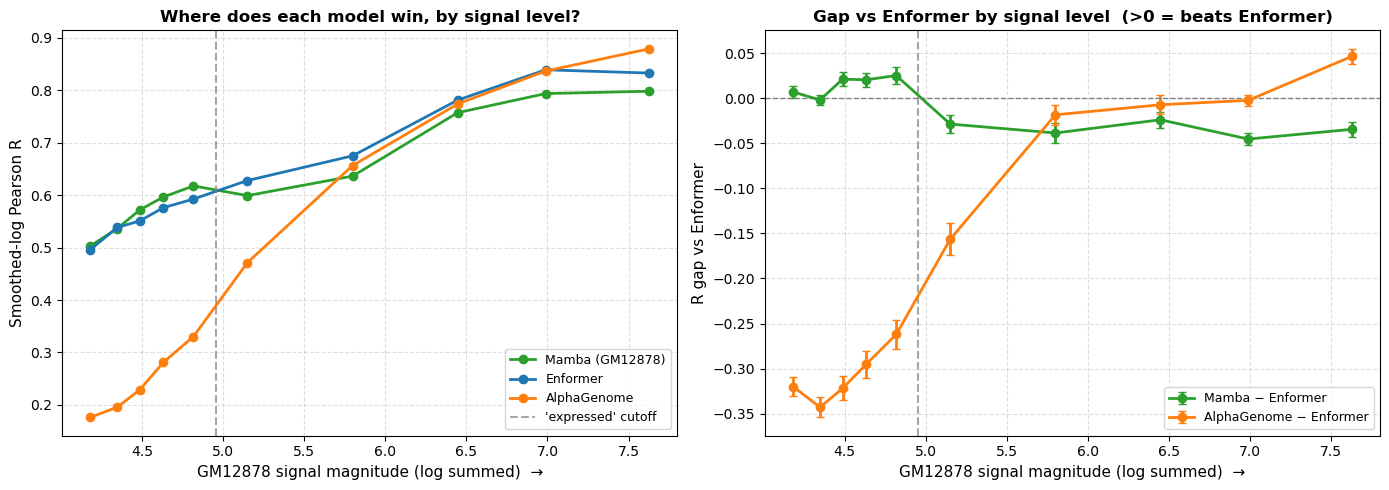

In [16]:
# Reconcile the discrepancy + add AlphaGenome: mean smoothed-log R per model across
# GM12878 signal-magnitude deciles over ALL regions (not just the expressed subset).
# NOTE: AlphaGenome trained on these regions while Mamba/Enformer held them out, so its
# curve is NOT a fair out-of-sample comparison -- shown for reference only.
import numpy as np
import matplotlib.pyplot as plt

mamba_key = 'GM12878_no_mlm_predictions.npy'
enformer_key = 'enformer'
ag_key = 'alphagenome_cage_test_128bp.npy'

Rm = pearson_smooth_results[mamba_key]
Re = pearson_smooth_results[enformer_key]
Ra = pearson_smooth_results[ag_key]
valid = ~np.isnan(Rm) & ~np.isnan(Re) & ~np.isnan(Ra)   # regions with all three defined
sig = gm_log[valid]                                     # GM12878 signal magnitude (log summed)
rm, re, ra = Rm[valid], Re[valid], Ra[valid]

# reconciliation numbers (gap vs Enformer, split by signal level)
expr_thr = np.median(gm_log[gm_log > 0])                # threshold the ceiling plot used for 'expressed'
hi = sig > expr_thr
print(f"regions (all three R defined): {valid.sum()}")
for lab, R in [('Mamba (GM12878)', rm), ('AlphaGenome    ', ra)]:
    g = R - re
    print(f"mean gap ({lab} - Enformer)  ALL={g.mean():+.3f}  "
          f"high-signal={g[hi].mean():+.3f}  low-signal={g[~hi].mean():+.3f}")

# signal deciles over the FULL set
nbins = 10
edges = np.quantile(sig, np.linspace(0, 1, nbins + 1)); edges[-1] += 1e-9
which = np.digitize(sig, edges) - 1
cen = np.array([np.median(sig[which == b]) for b in range(nbins)])
def dec_mean(x): return np.array([x[which == b].mean() for b in range(nbins)])
def dec_sem(x):  return np.array([x[which == b].std() / np.sqrt(np.sum(which == b)) for b in range(nbins)])

fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5))

# left: absolute R per model across signal deciles
axA.plot(cen, dec_mean(rm), marker='o', lw=2, color='#2ca02c', label='Mamba (GM12878)')
axA.plot(cen, dec_mean(re), marker='o', lw=2, color='#1f77b4', label='Enformer')
axA.plot(cen, dec_mean(ra), marker='o', lw=2, color='#ff7f0e', label='AlphaGenome')
axA.axvline(expr_thr, color='gray', ls='--', alpha=0.7, label="'expressed' cutoff")
axA.set_xlabel("GM12878 signal magnitude (log summed)  →", fontsize=11)
axA.set_ylabel("Smoothed-log Pearson R", fontsize=11)
axA.set_title("Where does each model win, by signal level?", fontsize=12, weight='bold')
axA.legend(fontsize=9); axA.grid(linestyle='--', alpha=0.4)

# right: gap vs Enformer for Mamba and AlphaGenome, by signal level
gm = rm - re; ga = ra - re
axB.errorbar(cen, dec_mean(gm), yerr=dec_sem(gm), marker='o', lw=2, capsize=3,
             color='#2ca02c', label='Mamba − Enformer')
axB.errorbar(cen, dec_mean(ga), yerr=dec_sem(ga), marker='o', lw=2, capsize=3,
             color='#ff7f0e', label='AlphaGenome − Enformer')
axB.axhline(0, color='gray', lw=1, ls='--')
axB.axvline(expr_thr, color='gray', ls='--', alpha=0.7)
axB.set_xlabel("GM12878 signal magnitude (log summed)  →", fontsize=11)
axB.set_ylabel("R gap vs Enformer", fontsize=11)
axB.set_title("Gap vs Enformer by signal level  (>0 = beats Enformer)", fontsize=12, weight='bold')
axB.legend(fontsize=9); axB.grid(linestyle='--', alpha=0.4)

plt.tight_layout(); plt.show()


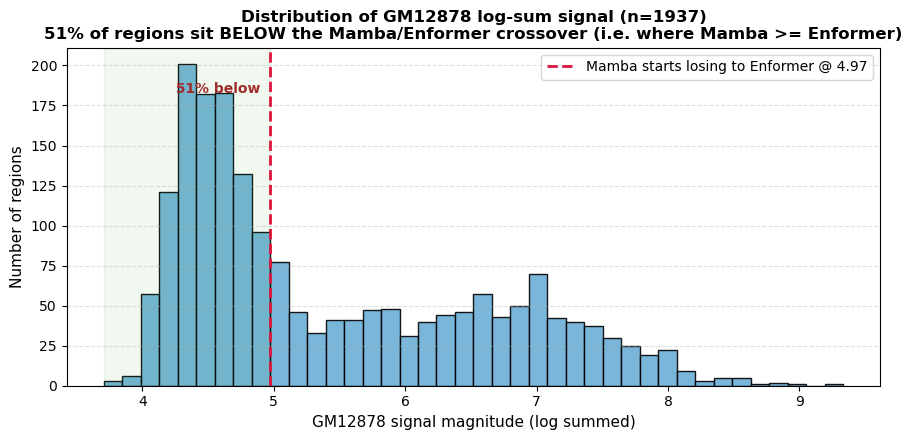

Mamba/Enformer durable crossover log-sum = 4.97 | fraction of regions below = 0.51
all +->- crossings (log-sum): [4.31, 4.97] -> using the last one
per-decile gap (Mamba - Enformer): [0.007, -0.002, 0.021, 0.02, 0.025, -0.029, -0.039, -0.024, -0.045, -0.035]


In [17]:
# Distribution of the GM12878 log-sum signal (the x-axis variable of the crossover plot),
# in FIXED-WIDTH bins. The crossover plot places one point per decile, but decile centers
# are not linearly spaced -- so on a linear axis the data looks spread out when in fact most
# of it piles up at LOW signal. The red line marks where Mamba STARTS TO UNDERPERFORM
# Enformer (the signal level where the binned Mamba - Enformer R gap crosses zero).
import numpy as np
import matplotlib.pyplot as plt

mamba_key = 'GM12878_no_mlm_predictions.npy'
enformer_key = 'enformer'
ag_key = 'alphagenome_cage_test_128bp.npy'

Rm = pearson_smooth_results[mamba_key]
Re = pearson_smooth_results[enformer_key]
Ra = pearson_smooth_results[ag_key]
valid = ~np.isnan(Rm) & ~np.isnan(Re) & ~np.isnan(Ra)   # same subset as the crossover plot
sig = gm_log[valid]
gap = Rm[valid] - Re[valid]                             # Mamba - Enformer smoothed-log R

# --- find the crossover: signal level where the binned gap goes from >0 (Mamba wins) to <0 ---
# uses the SAME decile binning as the crossover plot, then linearly interpolates the zero crossing
nbins = 10
edges = np.quantile(sig, np.linspace(0, 1, nbins + 1)); edges[-1] += 1e-9
which = np.digitize(sig, edges) - 1
cen = np.array([np.median(sig[which == b]) for b in range(nbins)])
gapmean = np.array([gap[which == b].mean() for b in range(nbins)])

# collect ALL +->- crossings (gap goes from Mamba-wins to Enformer-wins), then take the LAST
# one -- the earlier crossing(s) are the brief/noisy low-signal blips; the last is where Mamba
# durably starts underperforming (closer to the median).
crossings = []
for b in range(nbins - 1):
    if gapmean[b] >= 0 and gapmean[b + 1] < 0:
        t = gapmean[b] / (gapmean[b] - gapmean[b + 1])
        crossings.append(cen[b] + t * (cen[b + 1] - cen[b]))
if crossings:
    crossover = crossings[-1]                           # durable crossover (~median), not the 12% blip
else:                                                   # no clean +->- crossing; use closest-to-zero bin
    crossover = cen[int(np.argmin(np.abs(gapmean)))]

frac_below = np.mean(sig < crossover)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(sig, bins=40, color='#6baed6', edgecolor='black', alpha=0.9)
ax.axvline(crossover, color='crimson', ls='--', lw=2,
           label=f"Mamba starts losing to Enformer @ {crossover:.2f}")
ax.set_xlabel("GM12878 signal magnitude (log summed)", fontsize=11)
ax.set_ylabel("Number of regions", fontsize=11)
ax.set_title(f"Distribution of GM12878 log-sum signal (n={valid.sum()})\n"
             f"{frac_below*100:.0f}% of regions sit BELOW the Mamba/Enformer crossover "
             f"(i.e. where Mamba >= Enformer)",
             fontsize=12, weight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# shade the region where Mamba is at least as good as Enformer
ymax = ax.get_ylim()[1]
ax.axvspan(sig.min(), crossover, color='#2ca02c', alpha=0.07)
ax.text(crossover, ymax * 0.9, f"  {frac_below*100:.0f}% below  ",
        ha='right', va='top', fontsize=10, color="#a02c2c", weight='bold')

plt.tight_layout(); plt.show()

print(f"Mamba/Enformer durable crossover log-sum = {crossover:.2f} | "
      f"fraction of regions below = {frac_below:.2f}")
print("all +->- crossings (log-sum):", [round(c, 2) for c in crossings],
      "-> using the last one")
print("per-decile gap (Mamba - Enformer):", np.round(gapmean, 3).tolist())


In [18]:
#what are these low expression regions, and why does mamba outperform there?



regions with log-sum in [4,5]: 988 | showing top 10 by Mamba-Enformer gap


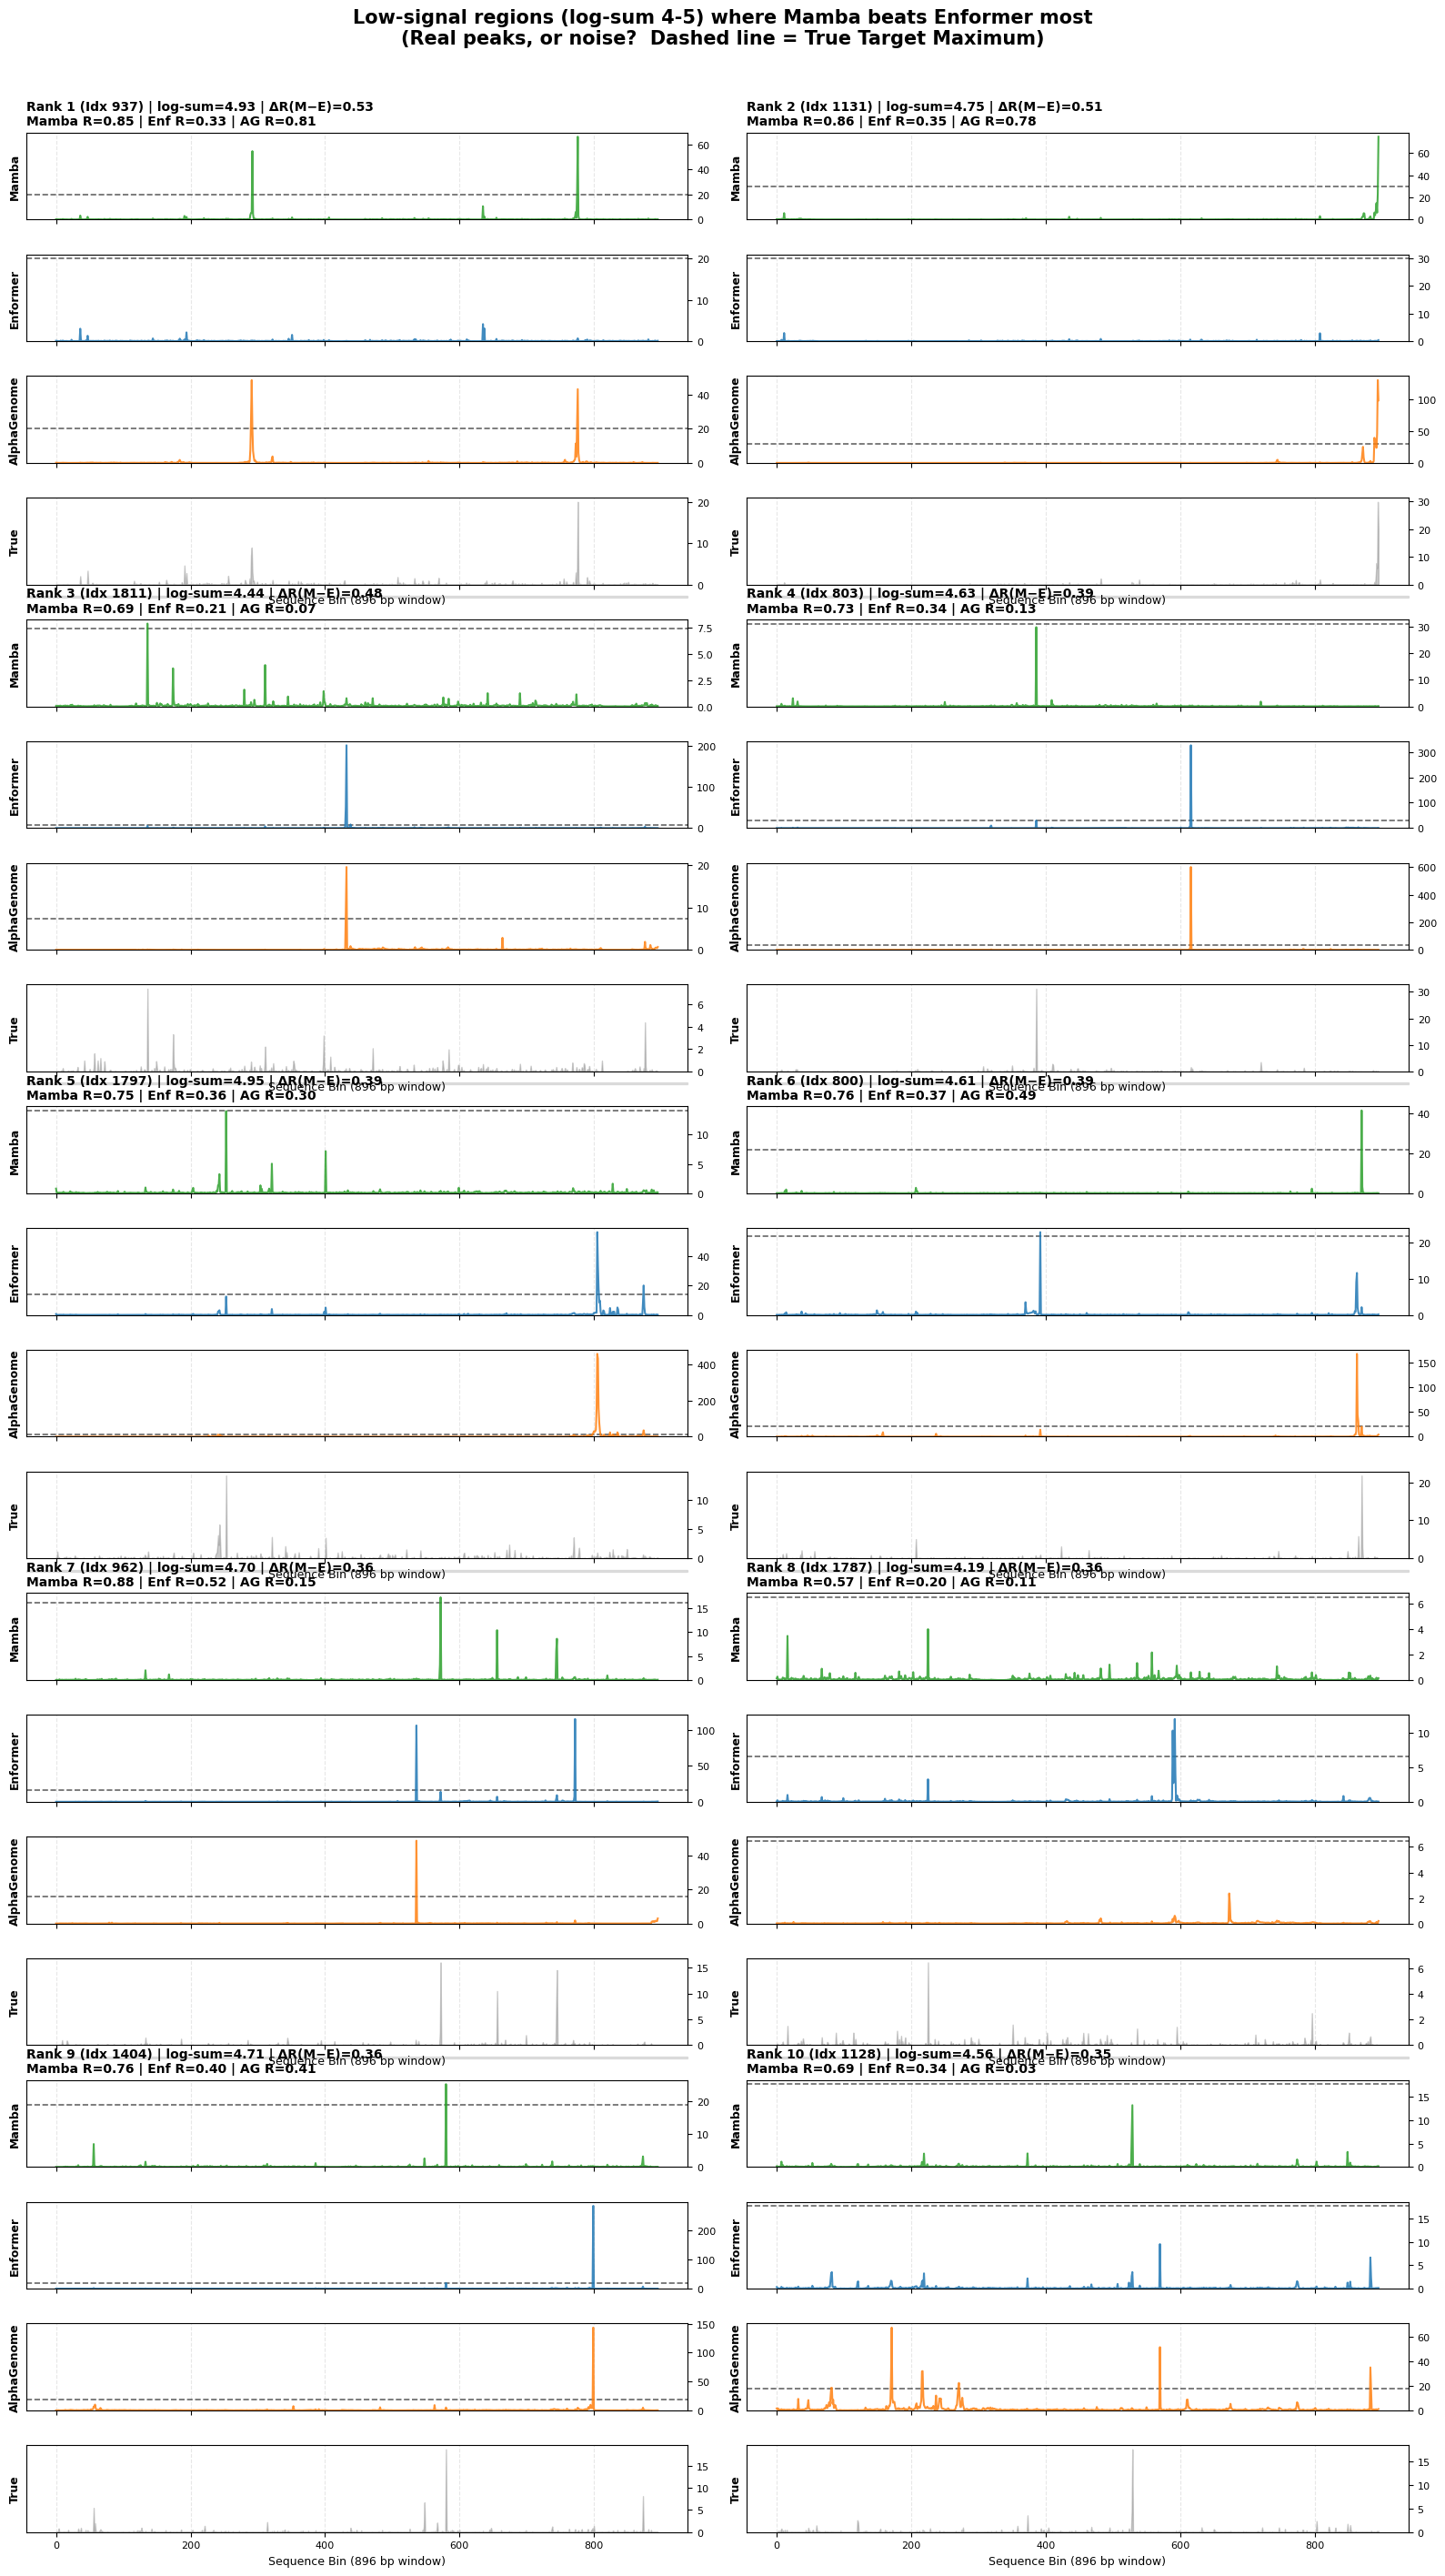

In [20]:
# Visual check (old stacked-axes style): regions with GM12878 log-sum in [4, 5] where Mamba
# beats Enformer the MOST (smoothed-log R). Per example, 4 stacked panels
# Mamba / Enformer / AlphaGenome / True, with the dashed line = true target maximum, so we can
# judge whether these low-signal wins are legitimate peaks or just noise.
import numpy as np
import matplotlib.pyplot as plt

mamba_key = 'GM12878_no_mlm_predictions.npy'
enformer_key = 'enformer'
ag_key = 'alphagenome_cage_test_128bp.npy'

Rm = pearson_smooth_results[mamba_key]
Re = pearson_smooth_results[enformer_key]
Ra = pearson_smooth_results[ag_key]
gap = Rm - Re

band = (gm_log >= 4) & (gm_log <= 5) & ~np.isnan(gap)
band_idx = np.where(band)[0]
top_10_indices = band_idx[np.argsort(gap[band_idx])[::-1]][:10]   # largest Mamba-Enformer gap first
print(f"regions with log-sum in [4,5]: {band.sum()} | showing top {len(top_10_indices)} by Mamba-Enformer gap")

N_SUB = 4  # Mamba, Enformer, AlphaGenome, True
fig, axes = plt.subplots(5 * N_SUB, 2, figsize=(16, 28), sharex='col')

for rank, idx in enumerate(top_10_indices):
    example_row = rank // 2
    example_col = rank % 2
    start_row = example_row * N_SUB

    ax_mamba    = axes[start_row,     example_col]
    ax_enformer = axes[start_row + 1, example_col]
    ax_ag       = axes[start_row + 2, example_col]
    ax_true     = axes[start_row + 3, example_col]

    track_mamba = np.asarray(preds[mamba_key][idx])
    track_enf   = np.asarray(preds[enformer_key][idx])
    track_ag    = np.asarray(preds[ag_key][idx])
    track_true  = np.asarray(t1[idx])

    true_max = np.max(track_true)
    ax_mamba.axhline(true_max, color='black', linestyle='--', alpha=0.6, linewidth=1.2, label='True Max')
    ax_enformer.axhline(true_max, color='black', linestyle='--', alpha=0.6, linewidth=1.2)
    ax_ag.axhline(true_max, color='black', linestyle='--', alpha=0.6, linewidth=1.2)

    ax_mamba.plot(track_mamba, color='#2ca02c', alpha=0.85, label='Mamba (GM12878)')
    ax_enformer.plot(track_enf, color='#1f77b4', alpha=0.85, label='Enformer')
    ax_ag.plot(track_ag, color='#ff7f0e', alpha=0.85, label='AlphaGenome')
    ax_true.fill_between(range(len(track_true)), track_true, color='gray', alpha=0.4, label='True')

    ax_mamba.set_ylim(0, max(np.max(track_mamba), true_max) * 1.05 + 1e-6)
    ax_enformer.set_ylim(0, max(np.max(track_enf), true_max) * 1.05 + 1e-6)
    ax_ag.set_ylim(0, max(np.max(track_ag), true_max) * 1.05 + 1e-6)
    ax_true.set_ylim(0, true_max * 1.05 + 1e-6)

    title_text = (f"Rank {rank+1} (Idx {idx}) | log-sum={gm_log[idx]:.2f} | ΔR(M−E)={gap[idx]:.2f}\n"
                  f"Mamba R={Rm[idx]:.2f} | Enf R={Re[idx]:.2f} | AG R={Ra[idx]:.2f}")
    ax_mamba.set_title(title_text, fontsize=10, weight='bold', loc='left')

    for ax, label in zip([ax_mamba, ax_enformer, ax_ag, ax_true],
                         ['Mamba', 'Enformer', 'AlphaGenome', 'True']):
        ax.set_ylabel(label, fontsize=9, weight='bold')
        ax.tick_params(axis='both', labelsize=8)
        ax.grid(axis='x', linestyle='--', alpha=0.3)
        ax.yaxis.tick_right()

    ax_true.set_xlabel("Sequence Bin (896 bp window)", fontsize=9)

    if start_row + 3 < (5 * N_SUB - 1):
        rect = plt.Rectangle((0, -0.15), 1, 0.02, transform=ax_true.transAxes,
                             color='black', alpha=0.1, clip_on=False)
        ax_true.add_patch(rect)

plt.suptitle("Low-signal regions (log-sum 4-5) where Mamba beats Enformer most\n"
             "(Real peaks, or noise?  Dashed line = True Target Maximum)",
             fontsize=15, weight='bold', y=1.01)
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.show()


# similar analysis for eQTLs